## Map of study states

dissolved 41 features into 36 states
Saved map to figures/study_area_map.png
13 study states labelled; callouts: ['NCT of Delhi']


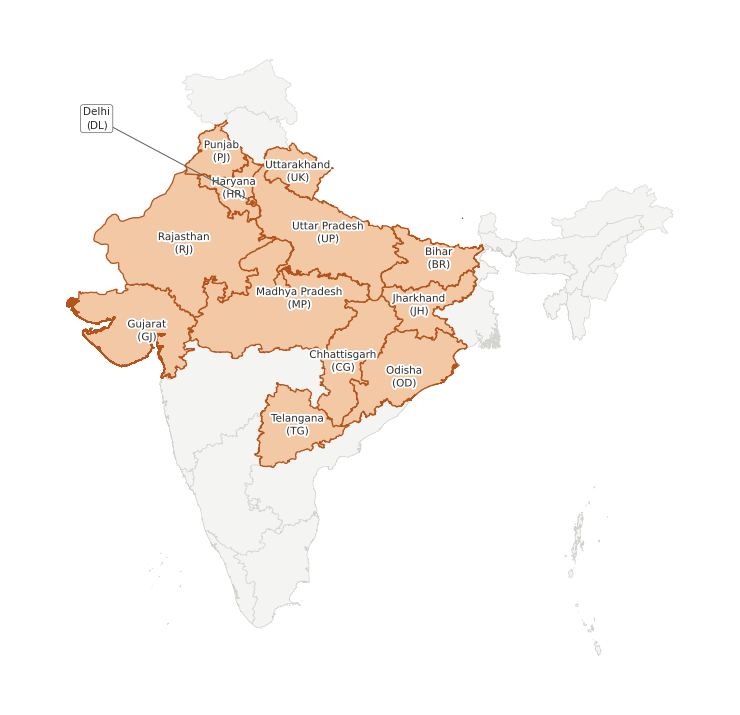

In [4]:
"""Map of India highlighting the study-area states.

Uses the GADM v4.1 level-1 boundaries already in the pipeline (same file used
for population-weighted CDD aggregation).

Three things this handles that the first version did not:

  * DUPLICATE LABELS. GADM stores some states as several feature rows rather
    than one MultiPolygon, so iterating over rows produced one label per row --
    hence "Gujarat" written three times. Dissolving by NAME_1 first gives
    exactly one geometry, and one label, per state.

  * LABELS ON TOP OF THE MAP. Dark text on a saturated fill is unreadable and
    hides the polygon underneath. The study fill is now light enough to read
    over, every label carries a white halo, and a label that would not fit
    inside its state is moved outside with a leader line (see CALLOUTS).

  * TINY STATES. Delhi is a few pixels at national scale. It gets a leader line
    to a label placed in open space, rather than a name ten times its own size
    printed across it.
"""

import os

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch, Rectangle
from shapely.geometry import MultiPolygon

# ---- config -----------------------------------------------------------------
GADM_PATH = "data/prep_panel/prep_cdd/gadm/gadm41_IND_1.shp"
OUT_PATH = "figures/study_area_map.png"

# WWA 2022 India-Pakistan heatwave study region (Zachariah et al. 2023).
# (lon_min, lon_max, lat_min, lat_max) in degrees.
WWA_BBOX = (68.0, 80.0, 24.0, 31.0)
SHOW_WWA = False

# GADM NAME_1 -> two-letter code used throughout the panel
STUDY_STATES = {
    "Punjab": "PJ",
    "Haryana": "HR",
    "NCT of Delhi": "DL",
    "Rajasthan": "RJ",
    "Uttar Pradesh": "UP",
    "Uttarakhand": "UK",
    "Odisha": "OD",
    "Madhya Pradesh": "MP",
    "Gujarat": "GJ",
    "Chhattisgarh": "CG",
    "Telangana": "TG",
    "Jharkhand": "JH",
    "Bihar": "BR",
}

# Display name where GADM's differs from the one to print
DISPLAY_NAME = {"NCT of Delhi": "Delhi"}

# States whose label goes OUTSIDE the polygon, with a leader line. The offset is
# in degrees (dx, dy) from the state's own point. Add any state here whose label
# crowds its neighbours -- the leader line keeps the association unambiguous.
CALLOUTS = {
    "NCT of Delhi": (-7.5, 4.0),
}

# ---- colours ----------------------------------------------------------------
# Light fill, dark edge: the label has to sit on this and stay readable, and the
# polygon has to stay visible under the label.
COL_STUDY_FILL = "#F2C9A4"
COL_STUDY_EDGE = "#B4531C"
COL_OTHER_FILL = "#F4F4F2"
COL_OTHER_EDGE = "#D2D2CE"
COL_TEXT = "#2B2B2B"
COL_LEADER = "#5A5A5A"
FS_NAME, FS_CODE = 7.5, 6.5

# ---- load & flag ------------------------------------------------------------
india = gpd.read_file(GADM_PATH)

missing = set(STUDY_STATES) - set(india["NAME_1"])
if missing:
    raise ValueError(f"State names not found in GADM file: {sorted(missing)}")

# one row per state: GADM splits some states across several features, and
# without this the label loop writes the name once per feature
n_before = len(india)
india = india.dissolve(by="NAME_1", as_index=False)
if len(india) != n_before:
    print(f"dissolved {n_before} features into {len(india)} states")

india["in_study"] = india["NAME_1"].isin(STUDY_STATES)


def label_point(geom):
    """A point inside the LARGEST part of a state. representative_point() on a
    MultiPolygon can land in a small outlying piece; the largest sub-polygon is
    where a reader expects the name."""
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)
    return geom.representative_point()


# ---- plot -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 8.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

india.plot(ax=ax, color=COL_OTHER_FILL, edgecolor=COL_OTHER_EDGE, linewidth=0.4)
study = india[india["in_study"]]
study.plot(ax=ax, color=COL_STUDY_FILL, edgecolor=COL_STUDY_EDGE, linewidth=0.9)

halo = [pe.withStroke(linewidth=2.6, foreground="white")]

for _, row in study.iterrows():
    name = row["NAME_1"]
    pt = label_point(row.geometry)
    text = f"{DISPLAY_NAME.get(name, name)}\n({STUDY_STATES[name]})"

    if name in CALLOUTS:
        dx, dy = CALLOUTS[name]
        ax.annotate(
            text, xy=(pt.x, pt.y), xytext=(pt.x + dx, pt.y + dy),
            ha="center", va="center", fontsize=FS_NAME, color=COL_TEXT,
            linespacing=1.35,
            arrowprops=dict(arrowstyle="-", lw=0.7, color=COL_LEADER,
                            shrinkA=0, shrinkB=2),
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=COL_LEADER, linewidth=0.5, alpha=0.95),
            zorder=6,
        )
        # a dot on the state itself, so the leader line has a visible anchor
        ax.plot(pt.x, pt.y, marker="o", markersize=2.5, color=COL_STUDY_EDGE,
                zorder=6)
    else:
        ax.annotate(text, (pt.x, pt.y), ha="center", va="center",
                    fontsize=FS_NAME, color=COL_TEXT, linespacing=1.35,
                    path_effects=halo, zorder=6)

if SHOW_WWA:
    lon_min, lon_max, lat_min, lat_max = WWA_BBOX
    ax.add_patch(Rectangle(
        (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
        fill=False, edgecolor="#1b6ca8", linestyle="--", linewidth=1.2,
        label="WWA 2022 heatwave region", zorder=5))

handles = [Patch(facecolor=COL_STUDY_FILL, edgecolor=COL_STUDY_EDGE, linewidth=0.9,
                 label="Study-area states"),
           Patch(facecolor=COL_OTHER_FILL, edgecolor=COL_OTHER_EDGE, linewidth=0.4,
                 label="Rest of India")]
if SHOW_WWA:
    handles.append(plt.Line2D([0], [0], color="#1b6ca8", linestyle="--", lw=12,
                              label="WWA 2022 heatwave region"))
# ax.legend(handles=handles, loc="lower right", fontsize=8, frameon=False)

# room for callout labels placed outside the coastline
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
padx, pady = 0.04 * (x1 - x0), 0.03 * (y1 - y0)
ax.set_xlim(x0 - padx, x1 + padx)
ax.set_ylim(y0 - pady, y1 + pady)

ax.set_aspect("equal")
ax.set_axis_off()

fig.tight_layout()
os.makedirs(os.path.dirname(OUT_PATH) or ".", exist_ok=True)
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved map to {OUT_PATH}")
print(f"{len(study)} study states labelled; callouts: {sorted(CALLOUTS)}")

# Demand Stats

rows: 122,850 | study period (M-A-M): 40,950
scenarios: ['ALL', 'NAT'] | months: [2, 3, 4, 5, 6, 7, 8, 10, 11]
states: 13 | members: 525


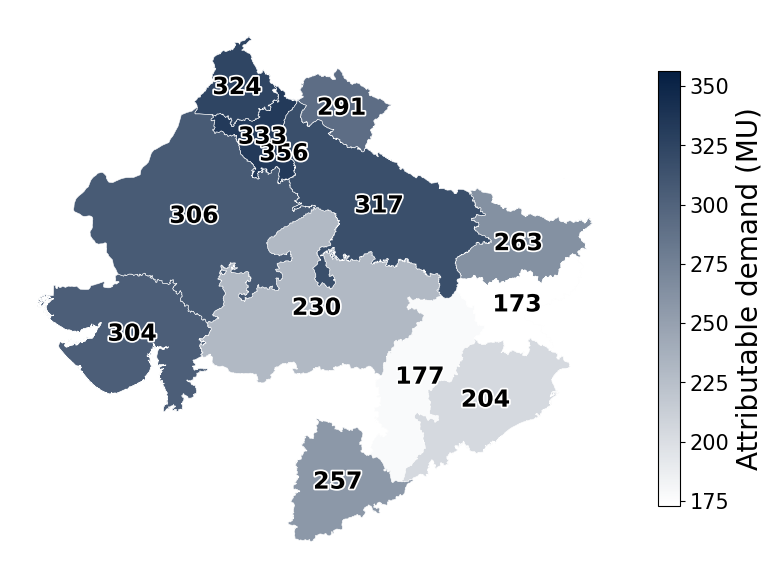

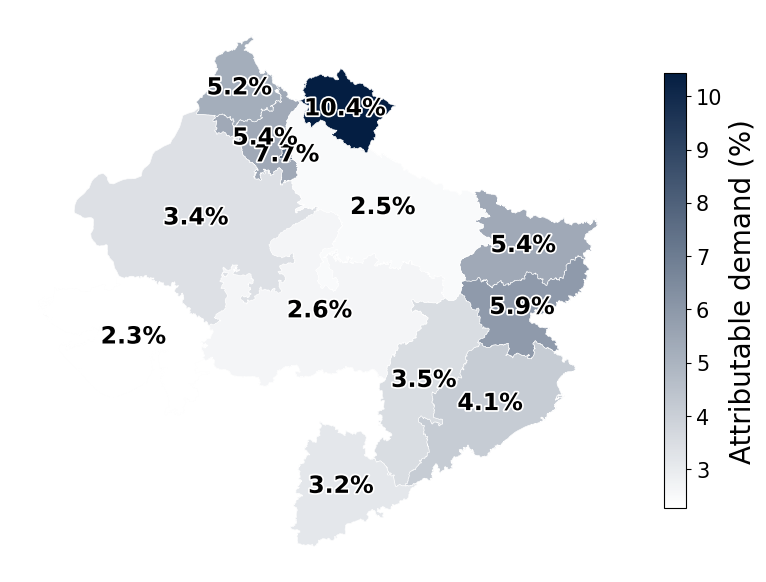

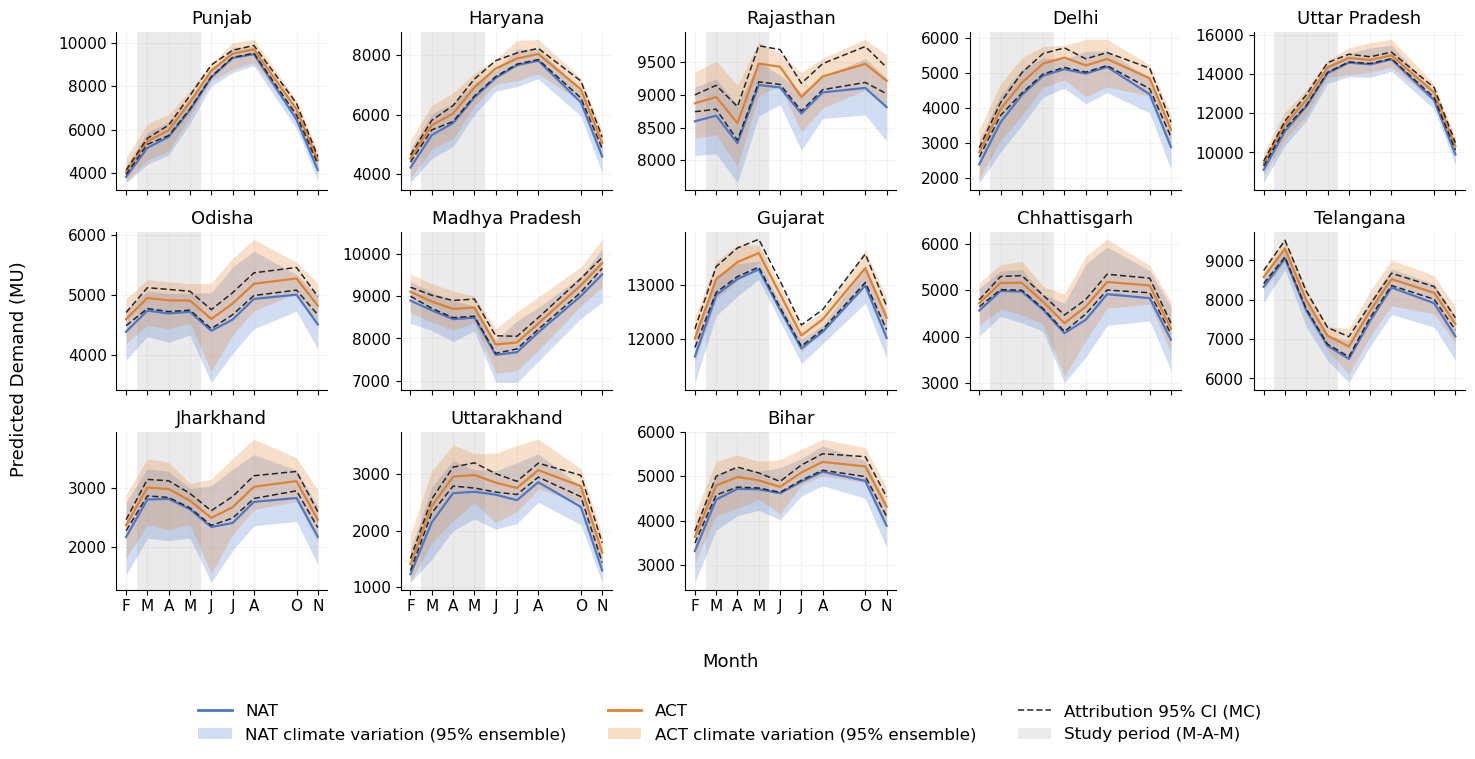


figures -> figures/demand_models


In [5]:
import os

# Import matplotlib's PDF backend before geopandas/fiona/pyproj get a chance
# to load. In this environment, saving to .pdf for the first time *after*
# those geospatial libraries are imported trips an assertion inside the
# `coverage` package (a monkey-patch on coverage.Coverage.intersect gets
# applied twice). Forcing backend_pdf to import first avoids the collision.
import matplotlib.backends.backend_pdf  # noqa: F401

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from shapely.geometry import MultiPolygon

# ---------------- config ----------------
ROOT = ""
PRED_CSV = f"{ROOT}data/fit_statistics/demand_models/attribution_predictions.csv"
# Coefficient-uncertainty (Monte Carlo) attribution estimate, exported by
# fit_cdd_model_spline.R section 10f/10g: one row per (state, month) with
# point_est, mc_mean, mc_lo, mc_hi (absolute MU, ALL - NAT, 95% MC interval).
# Same underlying mc_beta_mat draws as the whole-period attribution_
# uncertainty_by_state.csv, just evaluated against each month's own basis
# vector instead of one collapsed over the whole period.
MONTH_MC_CSV = f"{ROOT}data/fit_statistics/demand_models/attribution_uncertainty_by_state_month.csv"
GADM_SHP = f"{ROOT}data/prep_panel/prep_cdd/gadm/gadm41_IND_1.shp"
FIGDIR = f"{ROOT}figures/demand_models"

# The labels IN THE CSV. Keep these matched to the data -- they are used for
# filtering and column lookup, never shown to a reader.
ALL_LABEL, NAT_LABEL = "ALL", "NAT"

# What the reader sees. Every title, legend entry and axis label goes through
# leg(), so renaming a leg here renames it in every figure without touching any
# of the data handling.
LEG_NAMES = {ALL_LABEL: "ACT", NAT_LABEL: "NAT"}


def leg(scn):
    """Display name for a scenario label from the CSV."""
    return LEG_NAMES.get(scn, scn)


DIFF_LABEL = f"{leg(ALL_LABEL)} - {leg(NAT_LABEL)}"      # "ACT - NAT"

CI_LOW, CI_HIGH = 0.025, 0.975                     # ensemble percentile band

COL_ALL, COL_NAT = "#E1812C", "#4878CF"            # orange / blue, as in the figure
COL_MC = "0.15"                                    # propagated coefficient-uncertainty band

# ---- choropleth font sizes (all adjustable here) ----
# Every piece of text drawn on plot_choropleth()'s output reads its size
# from one of these, so resizing the choropleths for a different output
# (screen vs. print, a smaller thesis page) is a one-line edit each.
FS_CHORO_TITLE = 14         # panel title (currently drawn blank, "" -- still honoured if you add one)
FS_CHORO_LEGEND_LABEL = 20  # colorbar axis label, e.g. "Attributable demand (MU)"
FS_CHORO_LEGEND_TICK = 15    # colorbar tick numbers
FS_CHORO_VALUE = 17          # the value label drawn at each state's centroid

# ---- study period ----
# The predictions file carries a "month" column; the study period is the set of
# calendar months to include when averaging for the two choropleths below. Set
# to None to use every month in the file, or restrict it, e.g.
# STUDY_MONTHS = [3, 4, 5] for the pre-monsoon hot season.
STUDY_MONTHS = [3, 4, 5]

# study-area state code -> canonical state name
code_to_name = {
    "PJ": "Punjab", "HR": "Haryana", "RJ": "Rajasthan", "DL": "Delhi",
    "UP": "Uttar Pradesh", "OD": "Odisha", "MP": "Madhya Pradesh",
    "GJ": "Gujarat", "CG": "Chhattisgarh", "TG": "Telangana",
    "JH": "Jharkhand", "UK": "Uttarakhand", "BR": "Bihar"
}

MONTH_LETTER = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J",
                7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}

os.makedirs(FIGDIR, exist_ok=True)

# ---------------- load ----------------
df = pd.read_csv(PRED_CSV)
df["state_name"] = df["state"].map(code_to_name)

if df["state_name"].isna().any():
    bad = sorted(df.loc[df["state_name"].isna(), "state"].unique())
    raise SystemExit(f"state codes with no entry in code_to_name: {bad}\n"
                      "groupby would drop these rows silently.")

have_months = sorted(int(m) for m in df["month"].unique())

# Subset used only for the choropleths, so the line-graph section further
# down still shows the full annual cycle regardless of STUDY_MONTHS.
if STUDY_MONTHS is not None:
    absent = [m for m in STUDY_MONTHS if m not in have_months]
    if absent:
        raise SystemExit(f"STUDY_MONTHS {absent} are not in {PRED_CSV}\n"
                          f"  months present: {have_months}")
    df_period = df[df["month"].isin(STUDY_MONTHS)].copy()
    period_label = "-".join(MONTH_LETTER[m] for m in sorted(STUDY_MONTHS))
else:
    df_period = df.copy()
    period_label = "-".join(MONTH_LETTER[m] for m in have_months)

print(f"rows: {len(df):,} | study period ({period_label}): {len(df_period):,}")
print(f"scenarios: {sorted(df['scenario'].unique())} | months: {have_months}")
print(f"states: {df['state'].nunique()} | members: {df['member'].nunique()}")


def norm_key(s):
    aliases = {"orissa": "odisha", "uttaranchal": "uttarakhand",
               "nct of delhi": "delhi", "delhi (nct)": "delhi",
               "chattisgarh": "chhattisgarh"}
    k = str(s).strip().lower()
    return aliases.get(k, k)


CMAP_DIVERGING = LinearSegmentedColormap.from_list(
    "attribution_diverging", ["#4878CF", "#FFFFFF", "#E1812C"])  # NAT -> white -> ALL (original colours)
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "attribution_sequential", ["#FFFFFF", "#041E42"])            # white -> navy


def make_norm_cmap(vals):
    """Diverging norm/cmap if values straddle zero, else sequential navy."""
    if vals.min() < 0 < vals.max():
        return TwoSlopeNorm(vcenter=0, vmin=vals.min(), vmax=vals.max()), CMAP_DIVERGING
    return None, CMAP_SEQUENTIAL


def label_point(geom):
    """Point to place a state's value label at.
    For a MultiPolygon (a state with disjoint parts, e.g. an exclave),
    the centroid of the whole thing can fall in empty space between the
    parts, so label the centroid of the largest sub-polygon instead."""
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)
    return geom.centroid


def plot_choropleth(merged, column, title, legend_label, fname, label_fmt):
    """Draw one choropleth with a value label placed at the centre
    (centroid) of every state that has data."""
    vals = merged[column].dropna()
    norm, cmap = make_norm_cmap(vals)

    fig, ax = plt.subplots(figsize=(8, 9))
    merged.plot(ax=ax, color="#f2f2f2", edgecolor="white", linewidth=0.4)  # base
    merged.plot(column=column, ax=ax, cmap=cmap, norm=norm,
                edgecolor="white", linewidth=0.4, legend=True,
                missing_kwds={"color": "#f2f2f2"},
                legend_kwds={"label": legend_label, "shrink": 0.5})

    # the colorbar geopandas just attached is the last Axes added to the figure
    cax = ax.figure.axes[-1]
    cax.tick_params(labelsize=FS_CHORO_LEGEND_TICK)
    cax.yaxis.label.set_size(FS_CHORO_LEGEND_LABEL)

    # value label at the centre of each state
    for _, row in merged.dropna(subset=[column]).iterrows():
        centre = label_point(row.geometry)
        ax.annotate(
            label_fmt(row[column]),
            xy=(centre.x, centre.y),
            ha="center", va="center",
            fontsize=FS_CHORO_VALUE, color="black", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
        )

    ax.set_title(title, fontsize=FS_CHORO_TITLE)
    ax.axis("off")
    plt.tight_layout()
    stem, _ = os.path.splitext(fname)
    plt.savefig(f"{FIGDIR}/{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{FIGDIR}/{stem}.pdf", bbox_inches="tight")
    plt.show()


# --- local GADM level-1 shapefile (needs sibling .shx/.dbf/.prj alongside) ---
gdf = gpd.read_file(GADM_SHP)
name_col = next(c for c in ["NAME_1", "ST_NM", "st_nm", "name", "state"]
                if c in gdf.columns)
gdf["_key"] = gdf[name_col].map(norm_key)

# Some states (e.g. Uttarakhand) come through GADM as several separate
# feature rows rather than one MultiPolygon row. Left as-is, merging the
# per-state values onto gdf would fan out and draw one label per row
# (hence "3 labels" for a state with 3 GADM rows). Dissolve to one row
# per state first so each state gets exactly one label.
gdf = gdf.dissolve(by="_key", as_index=False)

# Restrict the basemap to just the study states. gdf otherwise carries every
# Indian state/UT, but state_scn can only ever contain the 13 in code_to_name
# (df is validated against code_to_name above, so nothing else can appear).
# Filtering here means both choropleths plot -- and autoscale to -- just the
# study area, instead of all of India with grey filler everywhere else.
study_keys = {norm_key(name) for name in code_to_name.values()}
gdf = gdf[gdf["_key"].isin(study_keys)].reset_index(drop=True)

missing_study = study_keys - set(gdf["_key"])
if missing_study:
    raise SystemExit(f"study states not found in GADM shapefile: {missing_study}")

# ==========================================================
# 1. Choropleth: mean(ACT) - mean(NAT) demand per state, over STUDY_MONTHS
# ==========================================================
state_scn = (df_period.groupby(["state", "state_name", "scenario"])["predicted_demand"]
                      .mean().unstack("scenario"))

absent = [c for c in (ALL_LABEL, NAT_LABEL) if c not in state_scn.columns]
if absent:
    raise SystemExit(
        f"scenario label(s) {absent} not found after the month filter\n"
        f"  present: {list(state_scn.columns)}\n"
        "  ALL_LABEL / NAT_LABEL must match the CSV, not the display names.")

state_scn["diff"] = state_scn[ALL_LABEL] - state_scn[NAT_LABEL]
# attributable demand as a % of overall (factual-scenario) demand for that state
state_scn["pct"] = 100 * state_scn["diff"] / state_scn[ALL_LABEL]
state_scn = state_scn.reset_index()
state_scn["_key"] = state_scn["state_name"].map(norm_key)

merged = gdf.merge(state_scn[["_key", "diff", "pct"]], on="_key", how="left")

unmatched = set(state_scn["_key"]) - set(gdf["_key"])
if unmatched:
    print("WARNING: unmatched states (check GADM NAME_1 vs aliases):", unmatched)

plot_choropleth(
    merged, "diff",
    title="",
    legend_label="Attributable demand (MU)",
    fname="demand_attribution_choropleth.png",
    label_fmt=lambda v: f"{v:,.0f}",
)

# ==========================================================
# 1b. Choropleth: attributable demand as a % of overall (factual) demand
# ==========================================================
plot_choropleth(
    merged, "pct",
    title=(""),
    legend_label="Attributable demand (%)",
    fname="demand_attribution_choropleth_pct.png",
    label_fmt=lambda v: f"{v:.1f}%",
)

# ==========================================================
# 2. Line graph: mean + ensemble CI for ACT and NAT, per state, plus the
# coefficient-uncertainty (MC) error propagated to the attribution estimate
# ==========================================================
# PROPAGATED ATTRIBUTION ERROR. The ACT/NAT mean lines + ensemble CI show
# each scenario's own climate-driven spread across members, but that is a
# different uncertainty source from the one actually propagated into the
# attribution estimate: coefficient (spline) uncertainty, carried through the
# MC loop in fit_cdd_model_spline.R (section 10f/10g). Rather than one flat
# error bar for the whole period, this uses the month-resolved export
# (attribution_uncertainty_by_state_month.csv): the same mc_beta_mat draws,
# evaluated against each month's own basis vector, so the band's width varies
# by where that month sits on the fitted CDD-response curve. It is NOT
# independent month-to-month noise -- every month's draws share the same
# underlying coefficient uncertainty, so adjacent months are correlated; it is
# that one shared uncertainty evaluated at different points. Drawn attached to
# the ACT line (ACT_mean +/- the MC half-width), since that is the curve whose
# uncertainty this describes.
mc_month = pd.read_csv(MONTH_MC_CSV) if os.path.exists(MONTH_MC_CSV) else None
if mc_month is None:
    raise SystemExit(f"missing {MONTH_MC_CSV} -- run the month-resolved MC "
                      "coefficient-uncertainty export (fit_cdd_model_spline.R, "
                      "section 10f/10g) first.")
need_mc = {"state", "month", "mc_mean", "mc_lo", "mc_hi"}
if not need_mc.issubset(mc_month.columns):
    raise SystemExit(f"{MONTH_MC_CSV} is missing {sorted(need_mc - set(mc_month.columns))}")

summ = (df.groupby(["state", "month", "scenario"])["predicted_demand"]
          .agg(mean="mean",
               lo=lambda x: x.quantile(CI_LOW),
               hi=lambda x: x.quantile(CI_HIGH))
          .reset_index())
states = [s for s in code_to_name if s in summ["state"].unique()]
months = sorted(summ["month"].unique())
ncols = min(5, len(states))
nrows = int(np.ceil(len(states) / ncols))

# Highlight band for the study period (MAM = March-April-May by default,
# STUDY_MONTHS above) drawn behind every state panel's lines, so the reader
# can see at a glance where the two choropleths' averaging window sits on
# the annual cycle. Extended half a month either side of the first/last
# study month so the shaded band visually brackets those months' data
# points rather than clipping through their centres.
highlight_months = STUDY_MONTHS is not None
if highlight_months:
    mam_lo, mam_hi = min(STUDY_MONTHS) - 0.5, max(STUDY_MONTHS) + 0.5

FS_TITLE = 13    # per-state panel title
FS_TICK = 11     # x/y tick labels
FS_AXIS = 13     # supxlabel / supylabel
FS_LEGEND = 12   # legend

FIG_W, FIG_H = 3.0 * ncols, 2.6 * nrows
BOTTOM_IN = 1.3         # inches reserved at the bottom for supxlabel + legend
# (2 rows now that climate-variation swatches are in it)
fig, axes = plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H),
                          sharex=True, squeeze=False)
axes = axes.ravel()
for ax, st in zip(axes, states):
    if highlight_months:
        ax.axvspan(mam_lo, mam_hi, color="0.85", alpha=0.5, zorder=0, linewidth=0)
    d_by_scn = {}
    for scn, col in [(NAT_LABEL, COL_NAT), (ALL_LABEL, COL_ALL)]:
        d = summ[(summ.state == st) & (summ.scenario == scn)].sort_values("month")
        d_by_scn[scn] = d
        ax.fill_between(d["month"], d["lo"], d["hi"], color=col, alpha=0.25, linewidth=0)
        ax.plot(d["month"], d["mean"], color=col, linewidth=1.6, label=leg(scn))
    # propagated MC coefficient-uncertainty bound, attached to the ACT line.
    # Drawn as two dashed bound lines rather than another translucent fill --
    # stacking a third semi-transparent layer on the existing NAT/ACT ensemble
    # fills produced a muddy blur wherever they overlapped, especially where
    # the MC interval is wide (Rajasthan, Gujarat, Bihar, Uttarakhand). A
    # solid dashed line reads clearly against any fill underneath.
    all_d = d_by_scn[ALL_LABEL]
    st_mc = mc_month[mc_month["state"] == st]
    if not all_d.empty and not st_mc.empty:
        band = all_d.merge(st_mc[["month", "mc_mean", "mc_lo", "mc_hi"]], on="month", how="inner")
        if not band.empty:
            lo_err = (band["mc_mean"] - band["mc_lo"]).clip(lower=0.0)
            hi_err = (band["mc_hi"] - band["mc_mean"]).clip(lower=0.0)
            ax.plot(band["month"], band["mean"] - lo_err, color=COL_MC, linewidth=1.1,
                    linestyle="--", dashes=(4, 2), zorder=6)
            ax.plot(band["month"], band["mean"] + hi_err, color=COL_MC, linewidth=1.1,
                    linestyle="--", dashes=(4, 2), zorder=6)
    ax.set_title(code_to_name.get(st, st), fontsize=FS_TITLE)
    ax.set_xticks(months)
    ax.set_xticklabels([MONTH_LETTER[m] for m in months], fontsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.grid(alpha=0.15)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
for ax in axes[len(states):]:
    ax.axis("off")

handles = [plt.Line2D([0], [0], color=COL_NAT, lw=2, label=leg(NAT_LABEL)),
           plt.Rectangle((0, 0), 1, 1, facecolor=COL_NAT, alpha=0.25,
                          label=f"{leg(NAT_LABEL)} climate variation (95% ensemble)"),
           plt.Line2D([0], [0], color=COL_ALL, lw=2, label=leg(ALL_LABEL)),
           plt.Rectangle((0, 0), 1, 1, facecolor=COL_ALL, alpha=0.25,
                          label=f"{leg(ALL_LABEL)} climate variation (95% ensemble)"),
           plt.Line2D([0], [0], color=COL_MC, lw=1.1, linestyle="--", dashes=(4, 2),
                      label="Attribution 95% CI (MC)")]
if highlight_months:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="0.85", alpha=0.5,
                                  label=f"Study period ({period_label})"))

# Reserve a fixed strip at the bottom (in inches, so it does not rescale with
# the number of state panels), then stack the two pieces inside it: shared x
# label above, legend below. The legend used to hang outside the figure at
# bbox_to_anchor=(0.5, -0.02), which put it exactly where supxlabel lands.
fig.supylabel("Predicted Demand (MU)", fontsize=FS_AXIS)
# fig.suptitle(f"Predicted demand under {leg(ALL_LABEL)} vs {leg(NAT_LABEL)} "
#              "(mean +/- ensemble CI)", y=1.0)
plt.tight_layout(rect=[0.02, BOTTOM_IN / FIG_H, 1, 0.98])
fig.supxlabel("Month", y=0.88 / FIG_H, fontsize=FS_AXIS)
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0.02 / FIG_H), fontsize=FS_LEGEND,
           columnspacing=2.5, handlelength=2.0)
plt.savefig(f"{FIGDIR}/demand_attribution_lines.png", dpi=150, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/demand_attribution_lines.pdf", bbox_inches="tight")
plt.show()


print(f"\nfigures -> {FIGDIR}")

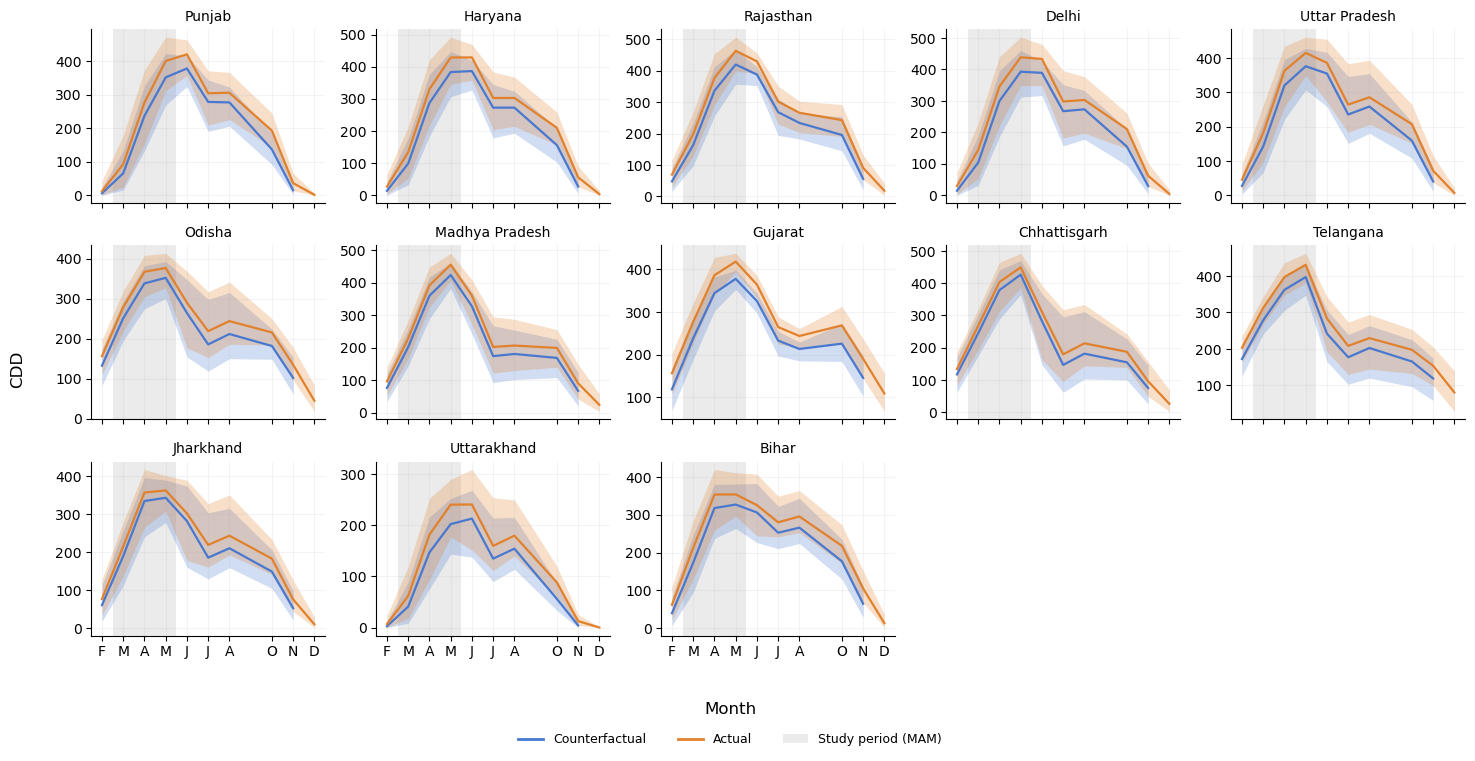

In [6]:
"""
Companion to attribution_plots.py's section 2 (line-graph) panel, but for
*observed* CDD rather than modelled demand: mean +/- ensemble-percentile
band of actual (ALL) vs counterfactual (NAT) cooling-degree-days per state,
by calendar month, from all_state_cdd.csv.

all_state_cdd.csv columns (as seen in the sheet):
    year   -- calendar year (multi-year panel, e.g. 2022, 2023, ...)
    month  -- 1-12
    state  -- full state name (not the 2-letter codes used in the
              attribution_predictions.csv file)
    cdd    -- cooling degree days
    leg    -- "ALL" (actual/all-forcings) or the counterfactual leg
              (assumed "NAT", i.e. natural-forcings-only -- matches the
              ALL/NAT convention already used in attribution_plots.py; edit
              LEG_ALL / LEG_CF below if your file uses different labels)
    member -- ensemble realisation id (e.g. "r001i1p1")

Because this file carries both `year` and `member`, the mean/CI band for
each state-month is computed by pooling across *all* year x member
combinations that fall in that group -- i.e. inter-annual variability and
ensemble spread are shown together as one band, exactly mirroring how
attribution_plots.py pools whatever rows land in each state/month/scenario
group. If you'd rather show ensemble spread only (holding year fixed) or
year-to-year spread only (holding member fixed), filter `df` down to a
single year or a single member before the groupby below.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- config ----------------
ROOT = ""
CDD_CSV = f"{ROOT}data/attribution_runs/all_state_cdd.csv"
FIGDIR = f"{ROOT}figures/demand_models"

CI_LOW, CI_HIGH = 0.025, 0.975          # ensemble/inter-annual percentile band

LEG_ALL, LEG_CF = "ALL", "NAT"          # the labels IN THE CSV
DISPLAY_LABEL = {LEG_ALL: "Actual", LEG_CF: "Counterfactual"}
COL_ALL, COL_NAT = "#E1812C", "#4878CF"  # orange / blue -- same as attribution_plots.py

# Calendar months (1-12) to shade as the study period, e.g. [3, 4, 5] for
# March-April-May. None turns the highlight off.
STUDY_MONTHS = [3, 4, 5]

# study-area state names (same 13 states as attribution_plots.py)
code_to_name = {
    "PJ": "Punjab", "HR": "Haryana", "RJ": "Rajasthan", "DL": "Delhi",
    "UP": "Uttar Pradesh", "OD": "Odisha", "MP": "Madhya Pradesh",
    "GJ": "Gujarat", "CG": "Chhattisgarh", "TG": "Telangana",
    "JH": "Jharkhand", "UK": "Uttarakhand", "BR": "Bihar"
}

MONTH_LETTER = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J",
                7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}


def norm_key(s):
    aliases = {"orissa": "odisha", "uttaranchal": "uttarakhand",
               "nct of delhi": "delhi", "delhi (nct)": "delhi",
               "chattisgarh": "chhattisgarh"}
    k = str(s).strip().lower()
    return aliases.get(k, k)


# ---------------- load ----------------
df = pd.read_csv(CDD_CSV)
df["_key"] = df["state"].map(norm_key)

# note what is in the file BEFORE filtering, so the report below costs nothing
# (the original re-read the whole CSV just to list the leg values)
all_legs = set(df["leg"].unique())
all_states = set(df["_key"].unique())

# restrict to the 13 study states (drops e.g. Andaman & Nicobar) and to the
# two legs we want to compare
study_keys = {norm_key(v): v for v in code_to_name.values()}
df = df[df["_key"].isin(study_keys) & df["leg"].isin([LEG_ALL, LEG_CF])].copy()
df["state_name"] = df["_key"].map(study_keys)

ignored_legs = all_legs - {LEG_ALL, LEG_CF}
if ignored_legs:
    print(f"NOTE: ignoring leg values other than {LEG_ALL!r}/{LEG_CF!r}: "
          f"{sorted(ignored_legs)}")
absent_legs = {LEG_ALL, LEG_CF} - all_legs
if absent_legs:
    raise SystemExit(f"leg label(s) {sorted(absent_legs)} not in {CDD_CSV}; "
                      f"found {sorted(all_legs)}")
absent_states = set(study_keys) - all_states
if absent_states:
    print(f"NOTE: study states absent from the CDD file: {sorted(absent_states)}")

# ---------------- mean + percentile band per state/month/leg ----------------
summ = (df.groupby(["state_name", "month", "leg"])["cdd"]
          .agg(mean="mean",
               lo=lambda x: x.quantile(CI_LOW),
               hi=lambda x: x.quantile(CI_HIGH))
          .reset_index())

states = [v for v in code_to_name.values() if v in summ["state_name"].unique()]
months = sorted(summ["month"].unique())
ncols = min(5, len(states))
nrows = int(np.ceil(len(states) / ncols))

FIG_W, FIG_H = 3.0 * ncols, 2.6 * nrows
BOTTOM_IN = 0.85        # inches reserved at the bottom for supxlabel + legend

# MAM (or whatever STUDY_MONTHS names) highlight band, shared by every panel --
# a half-month pad on each side so the shading brackets the full month rather
# than stopping at its midpoint.
highlight_months = STUDY_MONTHS is not None
if highlight_months:
    mam_lo, mam_hi = min(STUDY_MONTHS) - 0.5, max(STUDY_MONTHS) + 0.5
    period_label = "".join(MONTH_LETTER[m] for m in sorted(STUDY_MONTHS))

fig, axes = plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H),
                          sharex=True, squeeze=False)
axes = axes.ravel()

for ax, st in zip(axes, states):
    if highlight_months:
        ax.axvspan(mam_lo, mam_hi, color="0.85", alpha=0.5, zorder=0, linewidth=0)
    for leg_val, col in [(LEG_CF, COL_NAT), (LEG_ALL, COL_ALL)]:
        d = summ[(summ.state_name == st) & (summ.leg == leg_val)].sort_values("month")
        ax.fill_between(d["month"], d["lo"], d["hi"], color=col, alpha=0.25, linewidth=0)
        ax.plot(d["month"], d["mean"], color=col, linewidth=1.6,
                label=DISPLAY_LABEL[leg_val])
    ax.set_title(st, fontsize=10)
    ax.set_xticks(months)
    ax.set_xticklabels([MONTH_LETTER[m] for m in months])
    ax.grid(alpha=0.15)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

for ax in axes[len(states):]:
    ax.axis("off")

handles = [plt.Line2D([0], [0], color=COL_NAT, lw=2, label=DISPLAY_LABEL[LEG_CF]),
           plt.Line2D([0], [0], color=COL_ALL, lw=2, label=DISPLAY_LABEL[LEG_ALL])]
if highlight_months:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="0.85", alpha=0.5,
                                  label=f"Study period ({period_label})"))

# Reserve a fixed strip at the bottom (in inches, so it does not rescale with
# the number of state panels), then stack the two pieces inside it: shared x
# label above, legend below. tight_layout runs FIRST -- it lays out the panels
# above the reserved band; calling it afterwards would shove both back down.
fig.supylabel("CDD")
# fig.suptitle("Actual vs counterfactual CDD (mean +/- ensemble/inter-annual CI)", y=1.0)
plt.tight_layout(rect=[0.02, BOTTOM_IN / FIG_H, 1, 0.98])

fig.supxlabel("Month", y=0.42 / FIG_H)
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False,
           bbox_to_anchor=(0.5, 0.02 / FIG_H), fontsize=9,
           columnspacing=2.5, handlelength=2.0)

plt.savefig(f"{FIGDIR}/cdd_actual_counterfactual_lines.png", dpi=150,
            bbox_inches="tight")
plt.savefig(f"{FIGDIR}/cdd_actual_counterfactual_lines.pdf", bbox_inches="tight")
plt.show()

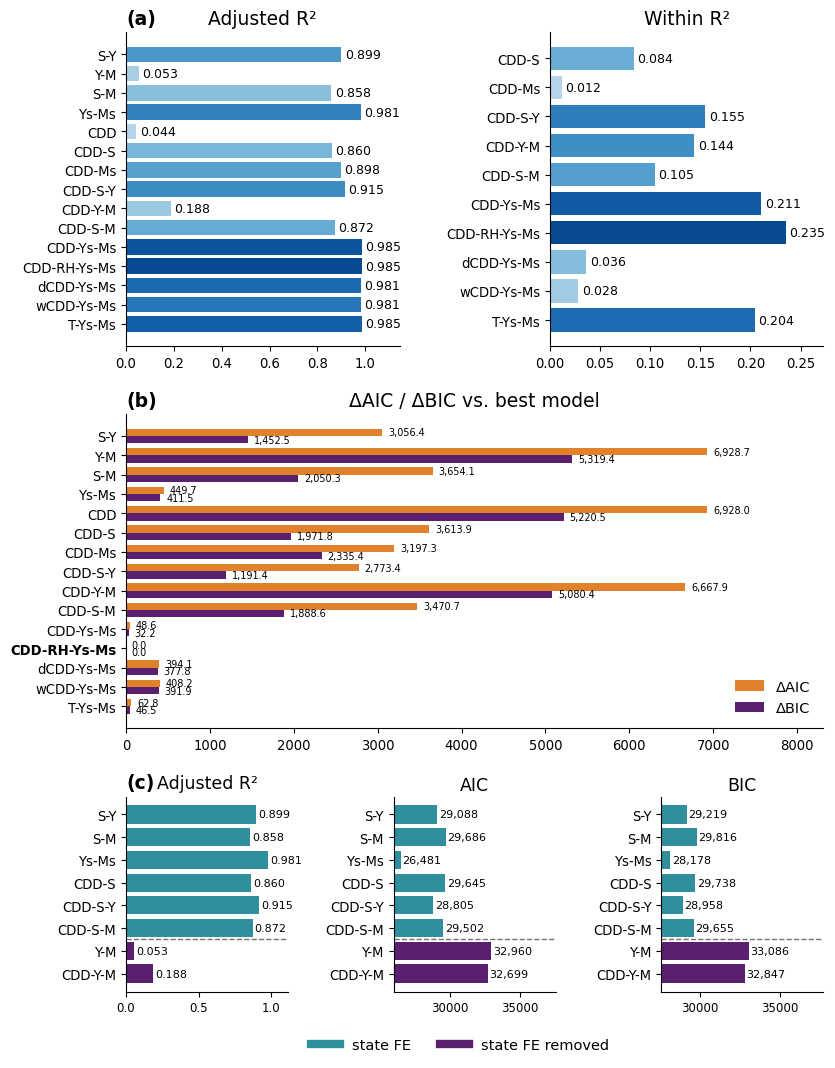

saved: figures/demand_models/combined_fit_stats.pdf


In [7]:
"""
Combine the R2 / AIC-BIC / state-FE fit-statistics plots into a single
vertically-stacked figure sized to sit comfortably inside a LaTeX A4 page
(with normal margins). LaTeX/your PDF viewer can crop the remaining
whitespace, so the figure height is driven by the number of model rows
rather than a fixed A4 height.

Layout (top -> bottom):
  1. Adjusted R2  |  Within R2      (side by side, each rank-shaded: best = darkest)
  2. dAIC / dBIC combined bars      (full width)
  3. State-FE comparison: Adj R2 | AIC | BIC   (side by side, colour = state-FE group)
"""

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------- config --
FS = "data/fit_statistics/demand_models/all_models_fit_stats.csv"
OUTDIR = "figures/demand_models"
OUTFILE = os.path.join(OUTDIR, "combined_fit_stats.pdf")

GROUP_STATE   = ["S-Y", "S-M", "Ys-Ms", "CDD-S", "CDD-S-Y", "CDD-S-M"]  # state FE present
GROUP_NOSTATE = ["Y-M", "CDD-Y-M"]                                      # state FE removed
GROUP = GROUP_STATE + GROUP_NOSTATE
group_of = lambda m: "state FE removed" if m in GROUP_NOSTATE else "state FE"
STATE_COL = {"state FE": "#2F8F9D", "state FE removed": "#5A1F6E"}

FIG_W = 7.5          # inches -- still comfortably inside a standard LaTeX textwidth (A4, 1in margins)
ROW_H = 0.24          # inches per model row (bar) -- enough headroom for the larger fonts below without
                       # ballooning the total page count of models into an overly tall aspect ratio
TOP_PAD = {"top": 0.42, "mid": 0.42, "bot": 0.58}   # inches reserved for title/axis/legend per row block

FS_TITLE  = 13.5   # panel titles
FS_TICK   = 9.5    # y-axis model-name labels + x-axis tick labels
FS_VALUE  = 9       # bar-end value annotations (R2 / state-FE panels)
FS_VALUE_SMALL = 7  # bar-end value annotations in the dense combined dAIC/dBIC panel
FS_LEGEND = 10.5    # legends

os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------------ data --
fs = pd.read_csv(FS)

missing = set(GROUP) - set(fs.model_name)
if missing:
    raise ValueError(f"missing from fit-stats file: {sorted(missing)}")
if fs[fs.model_name.isin(GROUP)]["n_obs"].nunique() != 1:
    print("WARNING: n_obs differs across models — AIC/BIC not directly comparable; refit on a common sample")

fs["dAIC"] = fs["aic"] - fs["aic"].min()
fs["dBIC"] = fs["bic"] - fs["bic"].min()
order = fs["model_name"].tolist()          # order as they appear in the CSV
fs_idx = fs.set_index("model_name")

n_all = len(fs_idx.reindex(order).dropna(subset=["adj_r_squared"]))
n_grp = len(GROUP)

# --------------------------------------------------------------- helpers --
def rank_shades(values, cmap_name, higher_is_better=True, lo=0.30, hi=0.90):
    """Map values to a light->dark ramp of one hue: best performer darkest."""
    n = len(values)
    ranks = pd.Series(values).rank(method="first", ascending=not higher_is_better).astype(int) - 1
    frac = 1 - ranks / max(n - 1, 1)          # 1.0 = best -> darkest, 0.0 = worst -> lightest
    cmap = mpl.colormaps[cmap_name]
    return [cmap(lo + (hi - lo) * f) for f in frac]

def style_ax(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

def bold_ytick(ax, label):
    """Bold the y-axis tick label matching `label` (e.g. the best AIC/BIC model)."""
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() == label:
            tick_label.set_fontweight("bold")

def r2_panel(ax, col, title, cmap_name="Blues"):
    d = fs_idx.reindex(order).dropna(subset=[col])
    colors = rank_shades(d[col].values, cmap_name, higher_is_better=True)
    ax.barh(range(len(d)), d[col], color=colors)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=FS_TICK)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=FS_TITLE, pad=6)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    style_ax(ax)
    xmax = d[col].max()
    ax.set_xlim(0, xmax * 1.16)
    pad = xmax * 0.015
    for y, v in enumerate(d[col]):
        ax.text(v + pad, y, f"{v:.3f}", va="center", ha="left", fontsize=FS_VALUE)

def aic_bic_panel(ax):
    d = fs_idx.reindex(order).dropna(subset=["dAIC", "dBIC"])
    y = np.arange(len(d)); h = 0.38
    ax.barh(y - h / 2, d["dAIC"], height=h, color="#E1812C", label="ΔAIC")
    ax.barh(y + h / 2, d["dBIC"], height=h, color="#5A1F6E", label="ΔBIC")
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=FS_TICK)
    ax.invert_yaxis()
    ax.set_title("ΔAIC / ΔBIC vs. best model", fontsize=FS_TITLE, pad=6)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    style_ax(ax)
    xmax = max(d["dAIC"].max(), d["dBIC"].max())
    ax.set_xlim(0, xmax * 1.20)
    pad = xmax * 0.01
    for i, v in zip(y, d["dAIC"]):
        ax.text(v + pad, i - h / 2, f"{v:,.1f}", va="center", ha="left", fontsize=FS_VALUE_SMALL)
    for i, v in zip(y, d["dBIC"]):
        ax.text(v + pad, i + h / 2, f"{v:,.1f}", va="center", ha="left", fontsize=FS_VALUE_SMALL)
    ax.legend(fontsize=FS_LEGEND, frameon=False, loc="lower right")
    bold_ytick(ax, d["dAIC"].idxmin())   # best AIC model
    bold_ytick(ax, d["dBIC"].idxmin())   # best BIC model (may be the same model)

def state_fe_panel(ax, col, title, fmt, bold_best=False):
    d = fs_idx.loc[GROUP, [col]].copy()
    d["grp"] = [group_of(m) for m in d.index]
    vals = d[col].values
    ax.barh(range(len(d)), vals, color=[STATE_COL[g] for g in d.grp])
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=FS_TICK)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=FS_TITLE - 1, pad=5)
    ax.tick_params(axis="x", labelsize=FS_TICK - 1)
    ax.axhline(len(GROUP_STATE) - 0.5, ls="--", lw=1, color="0.45")
    style_ax(ax)
    lo = 0 if col == "adj_r_squared" else vals.min() * 0.98
    ax.set_xlim(lo, vals.max() * 1.14)
    pad = (vals.max() - lo) * 0.015
    for y, v in enumerate(vals):
        ax.text(v + pad, y, fmt.format(v), va="center", ha="left", fontsize=FS_VALUE - 1)
    if bold_best:
        bold_ytick(ax, d[col].idxmin())   # lower AIC/BIC = better

# -------------------------------------------------------------- figure ----
h_top = TOP_PAD["top"] + ROW_H * n_all
h_mid = TOP_PAD["mid"] + ROW_H * n_all
h_bot = TOP_PAD["bot"] + ROW_H * n_grp
FIG_H = h_top + h_mid + h_bot

fig = plt.figure(figsize=(FIG_W, FIG_H))
# Explicit top/bottom override matplotlib's default figure margins, which otherwise
# leave a large empty band below the last row for the legend to float in.
outer = GridSpec(3, 1, height_ratios=[h_top, h_mid, h_bot], hspace=0.25,
                  top=0.97, bottom=0.06, left=0.055, right=0.985, figure=fig)

# --- row 1: adjusted R2 | within R2 (rank-shaded) ---
top_gs = outer[0].subgridspec(1, 2, wspace=0.55)
ax_adj = fig.add_subplot(top_gs[0, 0])
ax_win = fig.add_subplot(top_gs[0, 1])
r2_panel(ax_adj, "adj_r_squared", "Adjusted R²", cmap_name="Blues")
r2_panel(ax_win, "within_r_squared", "Within R²", cmap_name="Blues")

# --- row 2: dAIC / dBIC combined ---
ax_aic = fig.add_subplot(outer[1])
aic_bic_panel(ax_aic)

# --- row 3: state-FE comparison (Adj R2 | AIC | BIC) ---
bot_gs = outer[2].subgridspec(1, 3, wspace=0.65)
ax_fe_r2  = fig.add_subplot(bot_gs[0, 0])
ax_fe_aic = fig.add_subplot(bot_gs[0, 1])
ax_fe_bic = fig.add_subplot(bot_gs[0, 2])
state_fe_panel(ax_fe_r2,  "adj_r_squared", "Adjusted R²", "{:.3f}")
state_fe_panel(ax_fe_aic, "aic",           "AIC",             "{:,.0f}")
state_fe_panel(ax_fe_bic, "bic",           "BIC",             "{:,.0f}")

# --- row labels: (a) R2 pair, (b) dAIC/dBIC, (c) state-FE comparison ---
# A left-aligned title shares the same title slot as the existing centered title
# (same baseline), so it can never collide with the row above/below the way a
# manually-positioned text object would.
for ax, letter in [(ax_adj, "(a)"), (ax_aic, "(b)"), (ax_fe_r2, "(c)")]:
    ax.set_title(letter, loc="left", fontsize=FS_TITLE, fontweight="bold")

handles = [plt.Line2D([0], [0], color=STATE_COL[g], lw=6, label=g) for g in ["state FE", "state FE removed"]]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=FS_LEGEND,
           bbox_to_anchor=(0.5, -0.01))

fig.savefig(OUTFILE, bbox_inches="tight")
plt.show()
print(f"saved: {OUTFILE}")

13 states: ['BR', 'CG', 'DL', 'GJ', 'HR', 'JH', 'MP', 'OD', 'PJ', 'RJ', 'TG', 'UK', 'UP']

[demand+cdd] saved figures/demand_models/demand_timeseries_with_cdd.png / .pdf


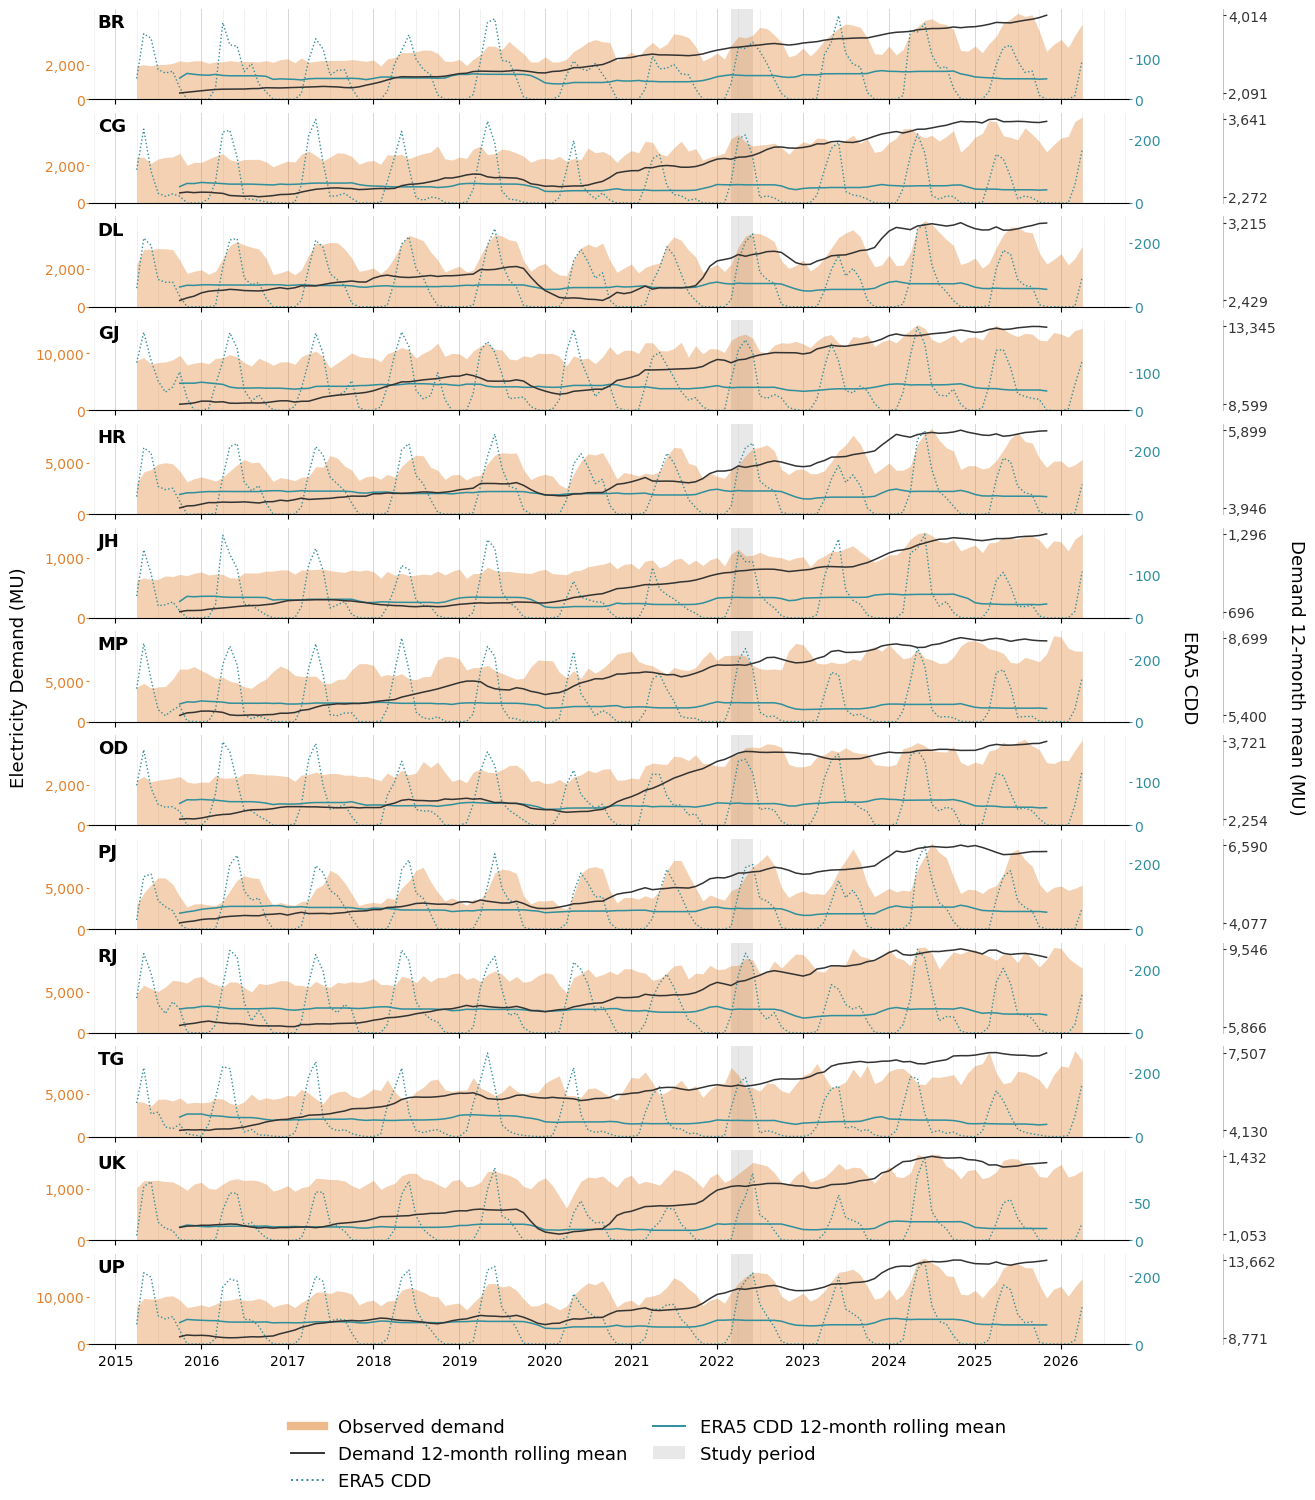

In [8]:
"""
Stacked per-state observed demand + ERA5 CDD overlay, one panel per state.

This is a standalone extraction of the THIRD figure produced by the original
combined script (make_demand_with_cdd) -- demand and CDD stacked on the same
per-state panels -- with two additions:

    1. Demand's 12-month rolling mean now sits on its OWN y axis (a third,
       outermost right-hand axis) instead of sharing the primary demand axis.
       Sharing the zero-anchored raw-demand axis compresses the mean into a
       thin band near the top, same reason make_figure() zooms its rolling
       twin to its own min/max instead of the raw series' scale.
    2. ERA5 CDD's 12-month rolling mean is drawn on the EXISTING secondary
       ERA5 axis (ax2) -- same axis, same colour as the raw ERA5 line -- but
       solid, so it reads as "the trend version of the dotted line" rather
       than a separate series.

Each panel also carries a grey shaded band marking the study period
(STUDY_PERIOD, currently Mar-May 2022), drawn behind the data on every panel.

Only this one figure is produced here; the standalone demand and CDD figures
and the growth tables from the combined script are not part of this script.
"""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ---------------- config ----------------
ROOT = ""
FIT = f"{ROOT}data/fit_statistics/demand_models/all_models_fit.csv"
PANEL = f"{ROOT}data/prep_panel/electricity_panel_with_cdd.csv"
OUTDIR = f"{ROOT}figures/demand_models"

# ---- rolling mean ----------------------------------------------------------
# Window length in MONTHS. The series is resampled onto a complete monthly axis
# first, so the window always means "this many months" even where the panel is
# missing a month -- a plain .rolling() counts ROWS, and would quietly stretch
# across a gap.
ROLL_MONTHS = 12
ROLL_CENTER = True                       # centred: no half-window lag

# Months required before a value is DRAWN. Full windows only -- see the
# original script for the seasonality-artefact rationale. Lower it (e.g.
# ROLL_MONTHS // 2) to extend the line at the price of a seasonal hook at
# either end.
ROLL_MIN = ROLL_MONTHS
COL_ROLL = "#333333"
COL_GRID = "#bbbbbb"

# ---- figure size -------------------------------------------------------
FIG_W = 13    # inches (20% wider than the original 9in)
ROW_H = 1.15    # inches per state panel -- total figure height is ROW_H * n states

# CDD dotted line: raw monthly ("monthly") or its own 12-month mean
# ("rolling"). The new SOLID rolling-mean line is drawn in addition to this
# one regardless of the setting; if CDD_AS="rolling" the dotted and solid
# lines will coincide, so leave this on "monthly" (the default) unless you
# specifically want the raw dotted line replaced too.
CDD_AS = "monthly"

# ---- gridlines / y ticks ----------------------------------------------------
Y_TICKS = 2
GRID_ON = True
GRID_MONTHS = 3        # divides the year: 3 -> Jan/Apr/Jul/Oct. Use a factor of
# 12 (1, 2, 3, 4, 6), or the last division of each year
# comes out short.

# ---- font sizes (all adjustable here) --------------------------------------
# Every piece of text on the figure reads its size from one of these four
# constants, so bumping legibility up or down for a different output size
# (screen vs. print, a smaller thesis page) never means hunting through the
# plotting code -- just edit the numbers below.
FS_STATE_LABEL = 13   # the per-panel state-name label (top-left of each panel)
FS_TICK = 10            # y-axis tick labels, all three axes (demand / ERA5 / roll)
FS_AXIS_LABEL = 13     # the three shared y-axis titles, drawn once on the middle panel
FS_LEGEND = 13          # legend text

# How far outward (in axes fraction, 1.0 = the normal right edge) the new
# demand-rolling-mean axis sits from the ERA5 axis, so its ticks/labels don't
# collide with ERA5's. Kept small -- just enough to clear ERA5's tick labels --
# so the panel doesn't grow a wide dead zone of empty margin.
DEMAND_ROLL_AXIS_OFFSET = 1.09

DEMAND = dict(name="demand", csv=FIT, value="electricity_requirement",
              unit="MU", fill="#E1812C5D", line="#E1812C")
CDD = dict(name="cdd", csv=PANEL, value="cdd",
           unit="CDD", fill="#2F8F9D4D", line="#2F8F9D")

# ---- study-period highlight -------------------------------------------
# Shaded vertical band marking the study period, drawn on every panel behind
# the data. Edit the dates to move it; set STUDY_PERIOD = None to drop it.
STUDY_PERIOD = dict(start="2022-03-01", end="2022-06-01")   # Mar-May 2022
STUDY_COLOR = "#808080"
STUDY_ALPHA = 0.18

# ---- every piece of text drawn on the figure, in one place --------------
# Edit these strings to relabel axes or the legend without touching any
# plotting code below. "{n}" is replaced with ROLL_MONTHS wherever it
# appears, so the rolling-window length stays in sync automatically -- drop
# the "{n}" (or hardcode a number) if you'd rather it not.
LABELS = dict(
    # y-axis titles (one per axis; each is drawn once, on the middle panel)
    demand_axis="Electricity Demand (MU)",
    era5_axis="ERA5 CDD",
    demand_roll_axis="Demand {n}-month mean (MU)",
    # legend entries, in the order they're drawn
    legend_demand_fill="Observed demand",
    legend_demand_roll="Demand {n}-month rolling mean",
    legend_era5_raw="ERA5 CDD",
    legend_era5_roll="ERA5 CDD {n}-month rolling mean",
    legend_study_period="Study period",
)


def label(key):
    """LABELS[key] with {n} filled in from ROLL_MONTHS."""
    return LABELS[key].format(n=ROLL_MONTHS)


os.makedirs(OUTDIR, exist_ok=True)


# ---------------- helpers (unchanged from the combined script) ----------------
def load(csv, value):
    """One row per state-month, with a date column."""
    d = pd.read_csv(csv)
    missing = {"state", "year", "month", value} - set(d.columns)
    if missing:
        raise SystemExit(f"{csv} is missing {sorted(missing)}\n"
                          f"  columns: {list(d.columns)}")
    d = d.dropna(subset=[value]).copy()
    d["date"] = pd.to_datetime(dict(year=d.year, month=d.month, day=1))
    # the fit file repeats every state-month once per model
    return d.drop_duplicates(["state", "date"])[["state", "date", value]]


def monthly(frame, value):
    """Complete monthly axis, gaps as NaN."""
    return frame.set_index("date")[value].resample("MS").mean()


def rolled(m, min_periods):
    return m.rolling(ROLL_MONTHS, center=ROLL_CENTER, min_periods=min_periods).mean()


def nice_tick(vmax):
    """Largest 1/2/5 x 10^k value at or below 0.9 * vmax."""
    if not np.isfinite(vmax) or vmax <= 0:
        return None
    import math
    target = 0.9 * vmax
    k = math.floor(math.log10(target))
    for m in (5, 2, 1):
        v = m * 10 ** k
        if v <= target:
            return v
    return 10 ** k


def set_y_ticks(ax, vmax, color="#333333", fmt="{:,.0f}"):
    """One or two ticks, no spine."""
    if not Y_TICKS:
        ax.set_yticks([])
        return
    t = nice_tick(vmax)
    if t is None:
        ax.set_yticks([])
        return
    ticks = [0, t] if Y_TICKS >= 2 else [t]
    ax.set_yticks(ticks)
    ax.set_yticklabels([fmt.format(v) for v in ticks])
    ax.tick_params(axis="y", length=2, pad=1.5, labelsize=FS_TICK,
                    colors=color, labelcolor=color)


def set_y_ticks_range(ax, vmin, vmax, color="#333333", fmt="{:,.0f}"):
    """Ticks at the series' own min and max, for an axis zoomed to that
    series rather than anchored at zero (the rolling-mean axes)."""
    if not Y_TICKS or not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        ax.set_yticks([])
        return
    ticks = [vmin, vmax] if Y_TICKS >= 2 else [vmax]
    ax.set_yticks(ticks)
    ax.set_yticklabels([fmt.format(v) for v in ticks])
    ax.tick_params(axis="y", length=2, pad=1.5, labelsize=FS_TICK,
                    colors=color, labelcolor=color)


def add_grid(ax):
    """Vertical gridlines every GRID_MONTHS months, with year lines picked out."""
    if not GRID_ON:
        return
    months = list(range(1, 13, GRID_MONTHS))          # 3 -> [1, 4, 7, 10]
    ax.xaxis.set_major_locator(mdates.YearLocator())  # January = the year line
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=months[1:]))
    ax.grid(which="minor", axis="x", color=COL_GRID, lw=0.4, alpha=0.35)
    ax.grid(which="major", axis="x", color=COL_GRID, lw=0.7, alpha=0.6)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.set_axisbelow(True)


def hide_all_spines(ax):
    for sp in ("top", "left", "bottom", "right"):
        ax.spines[sp].set_visible(False)


# ---------------- the figure ----------------
def make_demand_with_cdd_rolling(states, stem="demand_timeseries_with_cdd"):
    """Demand + CDD overlay, three y axes per panel:

        ax  (left)          -- raw observed demand, filled, zero-anchored
        ax2 (right)          -- ERA5 CDD: raw monthly (dotted) + 12-month
                                 rolling mean (solid), same colour, same axis
        ax3 (further right)  -- demand's 12-month rolling mean, its own axis
                                 zoomed to its own min/max (see module docstring)
    """
    dcfg, ccfg = DEMAND, CDD
    dem = load(dcfg["csv"], dcfg["value"])
    cdd = load(ccfg["csv"], ccfg["value"])

    use = [s for s in states if s in set(dem["state"]) and s in set(cdd["state"])]
    absent = [s for s in states if s not in use]
    if absent:
        print(f"[demand+cdd] NOTE: dropped {absent} -- absent from one of the two files")

    H = ROW_H * len(use)
    fig, axes = plt.subplots(len(use), 1, figsize=(FIG_W, H),
                              sharex=True, gridspec_kw=dict(hspace=0.15))
    axes = np.atleast_1d(axes)
    twins_cdd, twins_droll = [], []

    for ax, s in zip(axes, use):
        do = dem[dem.state == s].sort_values("date")
        co = cdd[cdd.state == s].sort_values("date")

        # ---- study-period highlight, drawn first so it sits behind everything ----
        if STUDY_PERIOD is not None:
            ax.axvspan(pd.Timestamp(STUDY_PERIOD["start"]), pd.Timestamp(STUDY_PERIOD["end"]),
                       color=STUDY_COLOR, alpha=STUDY_ALPHA, lw=0, zorder=0)

        # ---- primary axis: raw demand only, no rolling mean here anymore ----
        ax.fill_between(do.date, 0, do[dcfg["value"]], color=dcfg["fill"], lw=0)
        ax.set_ylim(0, float(do[dcfg["value"]].max()) * 1.05)
        set_y_ticks(ax, float(do[dcfg["value"]].max()), color=dcfg["line"])
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)

        # ---- secondary axis: ERA5 raw (dotted) + ERA5 rolling mean (solid) ----
        ax2 = ax.twinx()
        twins_cdd.append(ax2)
        if CDD_AS == "rolling":
            c_series = rolled(monthly(co, ccfg["value"]), ROLL_MIN)
            cx, cy = c_series.index, c_series.values
        else:
            cx, cy = co.date, co[ccfg["value"]]
        ax2.plot(cx, cy, color=ccfg["line"], lw=1.0, linestyle=":")

        cdd_roll = rolled(monthly(co, ccfg["value"]), ROLL_MIN)
        ax2.plot(cdd_roll.index, cdd_roll.values, color=ccfg["line"],
                 lw=1.1, linestyle="-")

        ax2.set_ylim(0, float(co[ccfg["value"]].max()) * 1.08)
        set_y_ticks(ax2, float(co[ccfg["value"]].max()), color=ccfg["line"])
        hide_all_spines(ax2)

        # ---- tertiary axis: demand's own 12-month rolling mean ----
        ax3 = ax.twinx()
        twins_droll.append(ax3)
        ax3.spines["right"].set_position(("axes", DEMAND_ROLL_AXIS_OFFSET))
        r = rolled(monthly(do, dcfg["value"]), ROLL_MIN)
        ax3.plot(r.index, r.values, color=COL_ROLL, lw=1.1)
        finite = r.dropna()
        if len(finite):
            lo, hi = float(finite.min()), float(finite.max())
            pad = 0.08 * (hi - lo) if hi > lo else 0.08 * max(abs(hi), 1.0)
            ax3.set_ylim(lo - pad, hi + pad)
            set_y_ticks_range(ax3, lo, hi, color=COL_ROLL)
        else:
            ax3.set_yticks([])
        for sp in ("top", "left", "bottom"):
            ax3.spines[sp].set_visible(False)
        # unlike the other (touching-the-panel) axes, this one is offset away
        # from the panel, so a faint spine is kept -- otherwise the ticks read
        # as disconnected text floating in the margin
        ax3.spines["right"].set_visible(True)
        ax3.spines["right"].set_color(COL_ROLL)
        ax3.spines["right"].set_alpha(0.35)
        ax3.spines["right"].set_linewidth(0.6)

        ax.text(0.008, 0.80, s, transform=ax.transAxes, fontsize=FS_STATE_LABEL,
                fontweight="bold", zorder=6)
        add_grid(ax)

    mid = len(use) // 2
    axes[mid].set_ylabel(label("demand_axis"), labelpad=12, fontsize=FS_AXIS_LABEL)
    twins_cdd[mid].set_ylabel(label("era5_axis"), labelpad=14, rotation=270, va="bottom",
                               fontsize=FS_AXIS_LABEL)
    twins_droll[mid].set_ylabel(label("demand_roll_axis"), labelpad=14,
                                 rotation=270, va="bottom", fontsize=FS_AXIS_LABEL)

    # the dotted line is raw monthly ERA5 by default, or (if CDD_AS="rolling")
    # the rolling mean itself -- its legend text follows whichever it is
    cdd_dotted_label = label("legend_era5_roll") if CDD_AS == "rolling" else label("legend_era5_raw")
    handles = [
        plt.Line2D([0], [0], color=dcfg["line"], lw=6, alpha=.55,
                   label=label("legend_demand_fill")),
        plt.Line2D([0], [0], color=COL_ROLL, lw=1.4,
                   label=label("legend_demand_roll")),
        plt.Line2D([0], [0], color=ccfg["line"], lw=1.4, linestyle=":",
                   label=cdd_dotted_label),
        plt.Line2D([0], [0], color=ccfg["line"], lw=1.4, linestyle="-",
                   label=label("legend_era5_roll")),
    ]
    if STUDY_PERIOD is not None:
        handles.append(Patch(facecolor=STUDY_COLOR, alpha=STUDY_ALPHA, edgecolor="none",
                              label=label("legend_study_period")))

    # extra right margin: three axes stack outward from the panel edge, vs.
    # one in the combined script's version of this figure. Legend strip
    # height scales with how many rows the handles wrap onto at ncol=2, and
    # (now that FS_LEGEND is adjustable) with the legend font size itself --
    # a bigger font wraps to taller rows even at the same ncol.
    LEGEND_NCOL = 2
    rows = -(-len(handles) // LEGEND_NCOL)              # ceil division
    row_h = 0.30 + 0.03 * max(FS_LEGEND - 8, 0)          # inches per legend row, scales with FS_LEGEND
    LEG_IN = row_h * rows + 0.2
    fig.subplots_adjust(bottom=LEG_IN / H, top=1 - 0.05 / H, left=0.07, right=0.87)
    fig.legend(handles=handles, loc="lower center", frameon=False, fontsize=FS_LEGEND,
               bbox_to_anchor=(0.5, 0.0), ncol=LEGEND_NCOL, handlelength=1.8,
               columnspacing=1.4, borderpad=0)

    fig.savefig(f"{OUTDIR}/{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{OUTDIR}/{stem}.png", dpi=150, bbox_inches="tight")
    print(f"[demand+cdd] saved {OUTDIR}/{stem}.png / .pdf")
    plt.show()


# ---------------- run ----------------
if __name__ == "__main__":
    states = sorted(load(DEMAND["csv"], DEMAND["value"])["state"].unique())
    print(f"{len(states)} states: {states}\n")
    make_demand_with_cdd_rolling(states)

# Shortage Stats


Mean predicted shortage over MAM, MU per state-month (525 ensemble members)
  a single average of the 3 months: members averaged within each state-month, then months averaged

state     state_name    NAT    ACT  diff    pct
   DL          Delhi  27.72  34.55 +6.83 +19.8%
   HR        Haryana  47.94  54.39 +6.45 +11.9%
   PJ         Punjab  35.88  41.68 +5.80 +13.9%
   UP  Uttar Pradesh 178.26 183.79 +5.53  +3.0%
   UK    Uttarakhand  34.49  39.92 +5.43 +13.6%
   RJ      Rajasthan  57.74  62.54 +4.80  +7.7%
   BR          Bihar 103.81 108.00 +4.19  +3.9%
   GJ        Gujarat  33.25  37.08 +3.83 +10.3%
   TG      Telangana  42.63  45.80 +3.17  +6.9%
   MP Madhya Pradesh  43.47  46.64 +3.17  +6.8%
   JH      Jharkhand  65.30  67.96 +2.66  +3.9%
   OD         Odisha  42.68  45.24 +2.56  +5.7%
   CG   Chhattisgarh  39.66  41.92 +2.26  +5.4%

  study area, mean of states : NAT 57.91 -> ACT 62.27 MU  (+4.36, +7.0%)
  study area, sum of states  : NAT 752.84 -> ACT 809.52 MU  (+56.67, +7.0%)
 

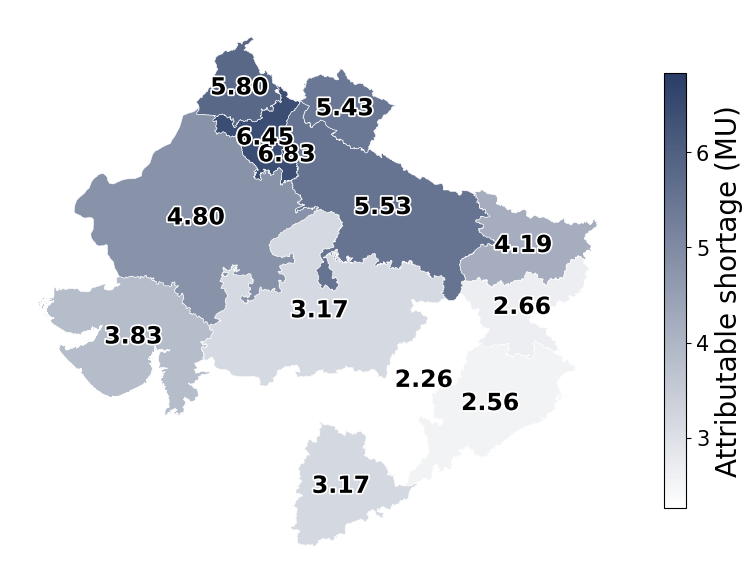

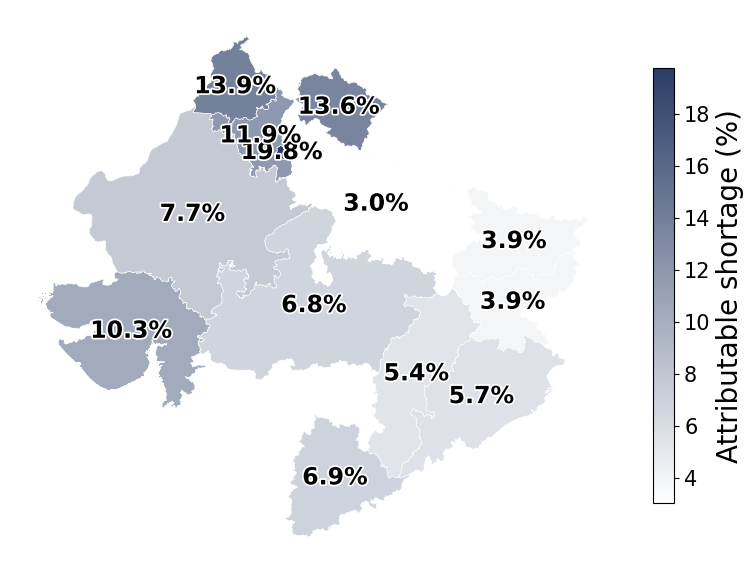

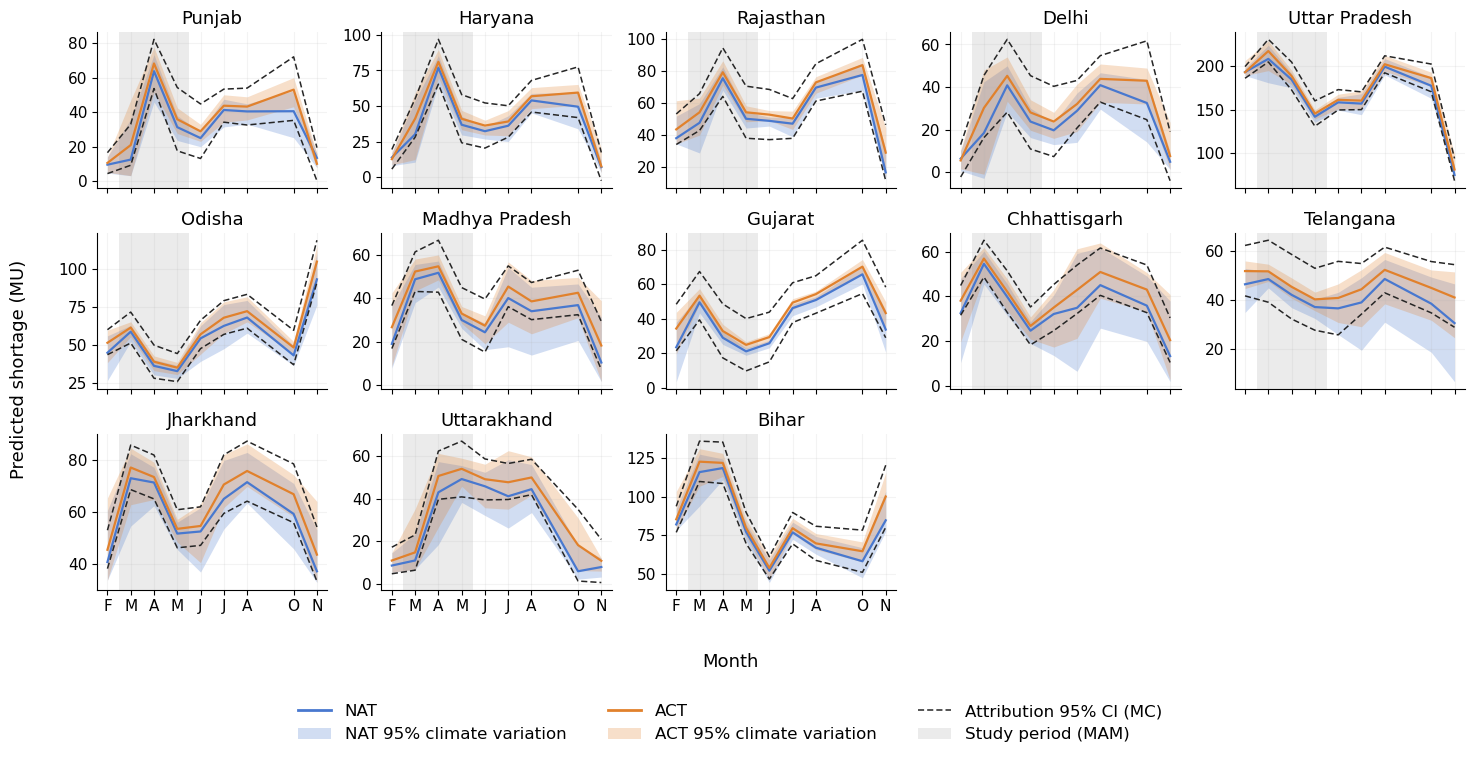

figures -> figures/shortage_models


In [9]:
# Import matplotlib's PDF backend before geopandas/fiona/pyproj get a chance
# to load. In this environment, saving to .pdf for the first time *after*
# those geospatial libraries are imported trips an assertion inside the
# `coverage` package (a monkey-patch on coverage.Coverage.intersect gets
# applied twice). Forcing backend_pdf to import first avoids the collision.

import matplotlib.backends.backend_pdf  # noqa: F401
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from shapely.geometry import MultiPolygon
import os

# ---------------- config ----------------
ROOT = ""
PRED_CSV = f"{ROOT}data/fit_statistics/shortage_models/attribution_predictions.csv"
# Coefficient-uncertainty (Monte Carlo) attribution estimate, exported by
# fit_cdd_model_spline.R section 10f/10g for the shortage model: one row per
# (state, month) with point_est, mc_mean, mc_lo, mc_hi (absolute MU, ALL - NAT,
# 95% MC interval). Same underlying mc_beta_mat draws as the whole-period
# attribution_uncertainty_by_state.csv, just evaluated against each month's
# own basis vector instead of one collapsed over the whole period.
MONTH_MC_CSV = f"{ROOT}data/fit_statistics/shortage_models/attribution_uncertainty_by_state_month.csv"
GADM_SHP = f"{ROOT}data/prep_panel/prep_cdd/gadm/gadm41_IND_1.shp"
FIGDIR = f"{ROOT}figures/shortage_models"

ALL_LABEL, NAT_LABEL = "ALL", "NAT"                # the labels IN THE CSV
DISPLAY = {ALL_LABEL: "ACT", NAT_LABEL: "NAT"}     # what the reader sees
DIFF_LABEL = f"{DISPLAY[ALL_LABEL]} - {DISPLAY[NAT_LABEL]}"
VALUE_COL = "predicted_demand"                     # the R export's column name
UNIT = "MU"
CI_LOW, CI_HIGH = 0.025, 0.975                     # ensemble percentile band

COL_ALL, COL_NAT = "#E1812C", "#4878CF"            # orange / blue -- same pair as the demand figure
COL_MC = "0.15"                                    # propagated coefficient-uncertainty band

# ---- choropleth font sizes (all adjustable here) ----
# Every piece of text drawn on plot_choropleth()'s output reads its size
# from one of these, so resizing the choropleths for a different output
# (screen vs. print, a smaller thesis page) is a one-line edit each.
FS_CHORO_TITLE = 14         # panel title (currently drawn blank, "" -- still honoured if you add one)
FS_CHORO_LEGEND_LABEL = 20  # colorbar axis label, e.g. "Attributable demand (MU)"
FS_CHORO_LEGEND_TICK = 15    # colorbar tick numbers
FS_CHORO_VALUE = 17          # the value label drawn at each state's centroid

# ---- study period ----
# The set of calendar months to include when averaging. Set to None to use
# every month in the file, e.g. STUDY_MONTHS = [4, 5, 6] for Apr-Jun.
STUDY_MONTHS = [3, 4, 5]

# study-area state code -> canonical state name
code_to_name = {
    "PJ": "Punjab", "HR": "Haryana", "RJ": "Rajasthan", "DL": "Delhi",
    "UP": "Uttar Pradesh", "OD": "Odisha", "MP": "Madhya Pradesh",
    "GJ": "Gujarat", "CG": "Chhattisgarh", "TG": "Telangana",
    "JH": "Jharkhand", "UK": "Uttarakhand", "BR": "Bihar"
}

MONTH_LETTER = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J",
                7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}

os.makedirs(FIGDIR, exist_ok=True)

# ---------------- load ----------------
df = pd.read_csv(PRED_CSV)
df["state_name"] = df["state"].map(code_to_name)

if df["state_name"].isna().any():
    bad = sorted(df.loc[df["state_name"].isna(), "state"].unique())
    raise SystemExit(f"state codes with no entry in code_to_name: {bad}")

have_months = sorted(int(m) for m in df["month"].unique())
if STUDY_MONTHS is not None:
    absent = [m for m in STUDY_MONTHS if m not in have_months]
    if absent:
        raise SystemExit(f"STUDY_MONTHS {absent} not in {PRED_CSV}\n"
                          f"  months present: {have_months}")
    df_period = df[df["month"].isin(STUDY_MONTHS)].copy()
    period_label = "".join(MONTH_LETTER[m] for m in sorted(STUDY_MONTHS))
else:
    df_period = df.copy()
    period_label = "".join(MONTH_LETTER[m] for m in have_months)

# ==========================================================
# 0. Mean predicted level under each scenario over the study months
# ==========================================================
# Two steps, deliberately: average over MEMBERS within each state-month first,
# then over MONTHS. Pooling every row at once would weight a month with more
# surviving members more heavily -- the same trap as the unbalanced panels
# elsewhere. With balanced membership the two agree; the check below says so
# either way.
counts = df_period.groupby(["state", "month", "scenario"]).size()
if counts.nunique() > 1:
    print(f"NOTE: member counts vary across state-months ({counts.min()}-"
          f"{counts.max()}); averaging months equally, so this does not bias "
          "the result")

per_sm = (df_period.groupby(["state", "state_name", "month", "scenario"])[VALUE_COL]
          .mean().unstack("scenario"))
absent = [c for c in (ALL_LABEL, NAT_LABEL) if c not in per_sm.columns]
if absent:
    raise SystemExit(f"scenario label(s) {absent} not found; present: "
                      f"{list(per_sm.columns)}")

# one number per state: the study period as a single average, not per month
per_state = (per_sm.groupby(["state", "state_name"])[[NAT_LABEL, ALL_LABEL]]
             .mean().reset_index())
per_state["diff"] = per_state[ALL_LABEL] - per_state[NAT_LABEL]
per_state["pct"] = 100 * per_state["diff"] / per_state[ALL_LABEL]

n_members = df_period["member"].nunique() if "member" in df_period else None
print(f"\nMean predicted shortage over {period_label}, {UNIT} per state-month"
      + (f" ({n_members} ensemble members)" if n_members else ""))
print(f"  a single average of the {len(STUDY_MONTHS) if STUDY_MONTHS else len(have_months)}"
      " months: members averaged within each state-month, then months averaged\n")

show = per_state.sort_values("diff", ascending=False)
print(show.assign(**{
    DISPLAY[NAT_LABEL]: show[NAT_LABEL].map("{:,.2f}".format),
    DISPLAY[ALL_LABEL]: show[ALL_LABEL].map("{:,.2f}".format),
    "diff": show["diff"].map("{:+,.2f}".format),
    "pct": show["pct"].map("{:+.1f}%".format),
})[["state", "state_name", DISPLAY[NAT_LABEL], DISPLAY[ALL_LABEL],
    "diff", "pct"]].to_string(index=False))

# study-area figures. The mean treats every state equally; the sum is the whole
# study area's shortage in an average study-period month. For a level in MU the
# sum is usually the one to quote -- say which in the caption.
m_nat, m_all = per_state[NAT_LABEL].mean(), per_state[ALL_LABEL].mean()
s_nat, s_all = per_state[NAT_LABEL].sum(), per_state[ALL_LABEL].sum()
print(f"\n  study area, mean of states : {DISPLAY[NAT_LABEL]} {m_nat:,.2f} -> "
      f"{DISPLAY[ALL_LABEL]} {m_all:,.2f} {UNIT}  "
      f"({m_all - m_nat:+,.2f}, {100*(m_all-m_nat)/m_all:+.1f}%)")
print(f"  study area, sum of states  : {DISPLAY[NAT_LABEL]} {s_nat:,.2f} -> "
      f"{DISPLAY[ALL_LABEL]} {s_all:,.2f} {UNIT}  "
      f"({s_all - s_nat:+,.2f}, {100*(s_all-s_nat)/s_all:+.1f}%)")

per_state.to_csv(f"{FIGDIR}/scenario_means_{period_label}.csv", index=False)
print(f"  saved {FIGDIR}/scenario_means_{period_label}.csv\n")


def norm_key(s):
    aliases = {"orissa": "odisha", "uttaranchal": "uttarakhand",
               "nct of delhi": "delhi", "delhi (nct)": "delhi",
               "chattisgarh": "chhattisgarh", "telengana": "telangana"}
    k = str(s).strip().lower()
    return aliases.get(k, k)


CMAP_DIVERGING = LinearSegmentedColormap.from_list(
    "attribution_diverging", ["#2A3D66", "#FFFFFF", "#E8A33D"])  # NAT -> white -> ALL
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "attribution_sequential", ["#FFFFFF", "#2A3D66"])            # white -> indigo


def make_norm_cmap(vals):
    """Diverging norm/cmap if values straddle zero, else sequential indigo."""
    if vals.min() < 0 < vals.max():
        return TwoSlopeNorm(vcenter=0, vmin=vals.min(), vmax=vals.max()), CMAP_DIVERGING
    return None, CMAP_SEQUENTIAL


def label_point(geom):
    """Point to place a state's value label at.
    For a MultiPolygon (a state with disjoint parts, e.g. an exclave),
    the centroid of the whole thing can fall in empty space between the
    parts, so label the centroid of the largest sub-polygon instead."""
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)
    return geom.centroid


def plot_choropleth(merged, column, title, legend_label, fname, label_fmt):
    """Draw one choropleth with a value label placed at the centre
    (centroid) of every state that has data."""
    vals = merged[column].dropna()
    norm, cmap = make_norm_cmap(vals)

    fig, ax = plt.subplots(figsize=(8, 9))
    merged.plot(ax=ax, color="#f2f2f2", edgecolor="white", linewidth=0.4)  # base
    merged.plot(column=column, ax=ax, cmap=cmap, norm=norm,
                edgecolor="white", linewidth=0.4, legend=True,
                missing_kwds={"color": "#f2f2f2"},
                legend_kwds={"label": legend_label, "shrink": 0.5})

    # the colorbar geopandas just attached is the last Axes added to the figure
    cax = ax.figure.axes[-1]
    cax.tick_params(labelsize=FS_CHORO_LEGEND_TICK)
    cax.yaxis.label.set_size(FS_CHORO_LEGEND_LABEL)

    # value label at the centre of each state
    for _, row in merged.dropna(subset=[column]).iterrows():
        centre = label_point(row.geometry)
        ax.annotate(
            label_fmt(row[column]),
            xy=(centre.x, centre.y),
            ha="center", va="center",
            fontsize=FS_CHORO_VALUE, color="black", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
        )

    ax.set_title(title, fontsize=FS_CHORO_TITLE)
    ax.axis("off")
    plt.tight_layout()
    stem, _ = os.path.splitext(fname)
    plt.savefig(f"{FIGDIR}/{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{FIGDIR}/{stem}.pdf", bbox_inches="tight")
    plt.show()


# --- local GADM level-1 shapefile (needs sibling .shx/.dbf/.prj alongside) ---
gdf = gpd.read_file(GADM_SHP)
name_col = next(c for c in ["NAME_1", "ST_NM", "st_nm", "name", "state"]
                if c in gdf.columns)
gdf["_key"] = gdf[name_col].map(norm_key)

# Some states (e.g. Uttarakhand) come through GADM as several separate
# feature rows rather than one MultiPolygon row. Left as-is, merging the
# per-state values onto gdf would fan out and draw one label per row
# (hence "3 labels" for a state with 3 GADM rows). Dissolve to one row
# per state first so each state gets exactly one label.
gdf = gdf.dissolve(by="_key", as_index=False)

# Restrict the basemap to just the study states. gdf otherwise carries every
# Indian state/UT, but state_scn can only ever contain the 13 in code_to_name
# (df is validated against code_to_name above, so nothing else can appear).
# Filtering here means both choropleths plot -- and autoscale to -- just the
# study area, instead of all of India with grey filler everywhere else.
study_keys = {norm_key(name) for name in code_to_name.values()}
gdf = gdf[gdf["_key"].isin(study_keys)].reset_index(drop=True)

missing_study = study_keys - set(gdf["_key"])
if missing_study:
    raise SystemExit(f"study states not found in GADM shapefile: {missing_study}")

# ==========================================================
# 1. Choropleth: mean(ACT) - mean(NAT) shortage per state, over STUDY_MONTHS
# ==========================================================
state_scn = per_state.copy()          # already the two-step average, per state
state_scn["_key"] = state_scn["state_name"].map(norm_key)

merged = gdf.merge(state_scn[["_key", "diff", "pct"]], on="_key", how="left")

unmatched = set(state_scn["_key"]) - set(gdf["_key"])
if unmatched:
    print("WARNING: unmatched states (check GADM NAME_1 vs aliases):", unmatched)

plot_choropleth(
    merged, "diff",
    title="",
    legend_label=f"Attributable shortage ({UNIT})",
    fname="shortage_attribution_choropleth.png",
    label_fmt=lambda v: f"{v:,.2f}",
)

# ==========================================================
# 1b. Choropleth: attributable shortage as a % of overall (ACT) shortage
# ==========================================================
plot_choropleth(
    merged, "pct",
    title="",
    legend_label="Attributable shortage (%)",
    fname="shortage_attribution_choropleth_pct.png",
    label_fmt=lambda v: f"{v:.1f}%",
)

# ==========================================================
# 2. Line graph: mean + ensemble CI for ACT and NAT, per state, plus the
# coefficient-uncertainty (MC) error propagated to the attribution estimate
# ==========================================================
# PROPAGATED ATTRIBUTION ERROR. The ACT/NAT mean lines + ensemble CI show
# each scenario's own climate-driven spread across members, but that is a
# different uncertainty source from the one actually propagated into the
# attribution estimate: coefficient (spline) uncertainty, carried through the
# MC loop in fit_cdd_model_spline.R (section 10f/10g). Rather than one flat
# error bar for the whole period, this uses the month-resolved export
# (attribution_uncertainty_by_state_month.csv): the same mc_beta_mat draws,
# evaluated against each month's own basis vector, so the band's width varies
# by where that month sits on the fitted CDD-response curve. It is NOT
# independent month-to-month noise -- every month's draws share the same
# underlying coefficient uncertainty, so adjacent months are correlated; it is
# that one shared uncertainty evaluated at different points. Drawn attached to
# the ACT line (ACT_mean +/- the MC half-width), since that is the curve whose
# uncertainty this describes.
mc_month = pd.read_csv(MONTH_MC_CSV) if os.path.exists(MONTH_MC_CSV) else None
if mc_month is None:
    raise SystemExit(f"missing {MONTH_MC_CSV} -- run the month-resolved MC "
                      "coefficient-uncertainty export (fit_cdd_model_spline.R, "
                      "section 10f/10g) first.")
need_mc = {"state", "month", "mc_mean", "mc_lo", "mc_hi"}
if not need_mc.issubset(mc_month.columns):
    raise SystemExit(f"{MONTH_MC_CSV} is missing {sorted(need_mc - set(mc_month.columns))}")

summ = (df.groupby(["state", "month", "scenario"])[VALUE_COL]
          .agg(mean="mean",
               lo=lambda x: x.quantile(CI_LOW),
               hi=lambda x: x.quantile(CI_HIGH))
          .reset_index())

states = [s for s in code_to_name if s in summ["state"].unique()]
months = sorted(summ["month"].unique())
ncols = min(5, len(states))
nrows = int(np.ceil(len(states) / ncols))

# Highlight band for the study period (MAM = March-April-May by default,
# STUDY_MONTHS above) drawn behind every state panel's lines, so the reader
# can see at a glance where the two choropleths' averaging window sits on
# the annual cycle. Extended half a month either side of the first/last
# study month so the shaded band visually brackets those months' data
# points rather than clipping through their centres.
highlight_months = STUDY_MONTHS is not None
if highlight_months:
    mam_lo, mam_hi = min(STUDY_MONTHS) - 0.5, max(STUDY_MONTHS) + 0.5

FS_TITLE = 13    # per-state panel title
FS_TICK = 11     # x/y tick labels
FS_AXIS = 13     # supxlabel / supylabel
FS_LEGEND = 12   # legend

FIG_W, FIG_H = 3.0 * ncols, 2.6 * nrows
BOTTOM_IN = 1.3         # inches reserved at the bottom for supxlabel + legend
# (2 rows now that climate-variation swatches are in it)
fig, axes = plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H),
                          sharex=True, squeeze=False)
axes = axes.ravel()

for ax, st in zip(axes, states):
    if highlight_months:
        ax.axvspan(mam_lo, mam_hi, color="0.85", alpha=0.5, zorder=0, linewidth=0)
    d_by_scn = {}
    for scn, col in [(NAT_LABEL, COL_NAT), (ALL_LABEL, COL_ALL)]:
        d = summ[(summ.state == st) & (summ.scenario == scn)].sort_values("month")
        d_by_scn[scn] = d
        ax.fill_between(d["month"], d["lo"], d["hi"], color=col, alpha=0.25, linewidth=0)
        ax.plot(d["month"], d["mean"], color=col, linewidth=1.6, label=DISPLAY[scn])
    # propagated MC coefficient-uncertainty bound, attached to the ACT line.
    # Drawn as two dashed bound lines rather than another translucent fill --
    # stacking a third semi-transparent layer on the existing NAT/ACT ensemble
    # fills produced a muddy blur wherever they overlapped. A solid dashed
    # line reads clearly against any fill underneath.
    all_d = d_by_scn[ALL_LABEL]
    st_mc = mc_month[mc_month["state"] == st]
    if not all_d.empty and not st_mc.empty:
        band = all_d.merge(st_mc[["month", "mc_mean", "mc_lo", "mc_hi"]], on="month", how="inner")
        if not band.empty:
            lo_err = (band["mc_mean"] - band["mc_lo"]).clip(lower=0.0)
            hi_err = (band["mc_hi"] - band["mc_mean"]).clip(lower=0.0)
            ax.plot(band["month"], band["mean"] - lo_err, color=COL_MC, linewidth=1.1,
                    linestyle="--", dashes=(4, 2), zorder=6)
            ax.plot(band["month"], band["mean"] + hi_err, color=COL_MC, linewidth=1.1,
                    linestyle="--", dashes=(4, 2), zorder=6)
    ax.set_title(code_to_name.get(st, st), fontsize=FS_TITLE)
    ax.set_xticks(months)
    ax.set_xticklabels([MONTH_LETTER[m] for m in months], fontsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.grid(alpha=0.15)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

for ax in axes[len(states):]:
    ax.axis("off")

handles = [plt.Line2D([0], [0], color=COL_NAT, lw=2, label=DISPLAY[NAT_LABEL]),
           plt.Rectangle((0, 0), 1, 1, facecolor=COL_NAT, alpha=0.25,
                          label=f"{DISPLAY[NAT_LABEL]} 95% climate variation"),
           plt.Line2D([0], [0], color=COL_ALL, lw=2, label=DISPLAY[ALL_LABEL]),
           plt.Rectangle((0, 0), 1, 1, facecolor=COL_ALL, alpha=0.25,
                          label=f"{DISPLAY[ALL_LABEL]} 95% climate variation"),
           plt.Line2D([0], [0], color=COL_MC, lw=1.1, linestyle="--", dashes=(4, 2),
                      label="Attribution 95% CI (MC)")]
if highlight_months:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="0.85", alpha=0.5,
                                  label=f"Study period ({period_label})"))

# reserve a fixed strip at the bottom, then stack the shared x label above the
# legend inside it. At bbox_to_anchor=(0.5, -0.02) the legend hangs outside the
# figure, which is exactly where supxlabel lands -- the two overprint.
fig.supylabel(f"Predicted shortage ({UNIT})", fontsize=FS_AXIS)
plt.tight_layout(rect=[0.02, BOTTOM_IN / FIG_H, 1, 0.98])
fig.supxlabel("Month", y=0.88 / FIG_H, fontsize=FS_AXIS)
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0.02 / FIG_H), fontsize=FS_LEGEND,
           columnspacing=2.5, handlelength=2.0)

plt.savefig(f"{FIGDIR}/shortage_attribution_lines.png", dpi=150, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/shortage_attribution_lines.pdf", bbox_inches="tight")
plt.show()

print(f"figures -> {FIGDIR}")

study period: M-A-M (3 months), years [2022]
  month FE averaged over: [np.int64(3), np.int64(4), np.int64(5)]
  year  FE averaged over: [np.int64(2022)]
  NAT CDD density: 56,700 rows, mean 219.85, months [np.int64(3), np.int64(4), np.int64(5)]

baseline by state (MU per state-month, this period):
state_name
Rajasthan          65.81
Bihar              54.30
Uttar_Pradesh      53.01
Jharkhand          49.49
Haryana            32.39
Uttarakhand        16.58
Punjab              4.34
Madhya_Pradesh      3.22
Delhi             -24.69
Telengana         -24.81
Chhattisgarh      -26.72
Gujarat           -28.64
Odisha            -38.44
  other-state mean baseline: 17.20

model-wide diagnostics (CDD-Ys-Ms, from data/fit_statistics/shortage_models/response_curve_CDD-Ys-Ms.csv):
  residual sigma: 59.33
  CV(RMSE): 236.3%
  mean relative EI width (obs-weighted): 972.9%

zero crossings of the predicted response (M-A-M)
  Delhi             : turns positive at CDD 106.1 [82% of NAT state-months are h

/var/folders/h_/7vbz_661085_0zlkpxz6pf0m0000gn/T/ipykernel_20448/2876041907.py:321: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



saved figures/shortage_models/model_cdd_response_natdensity_M-A-M.png / .pdf


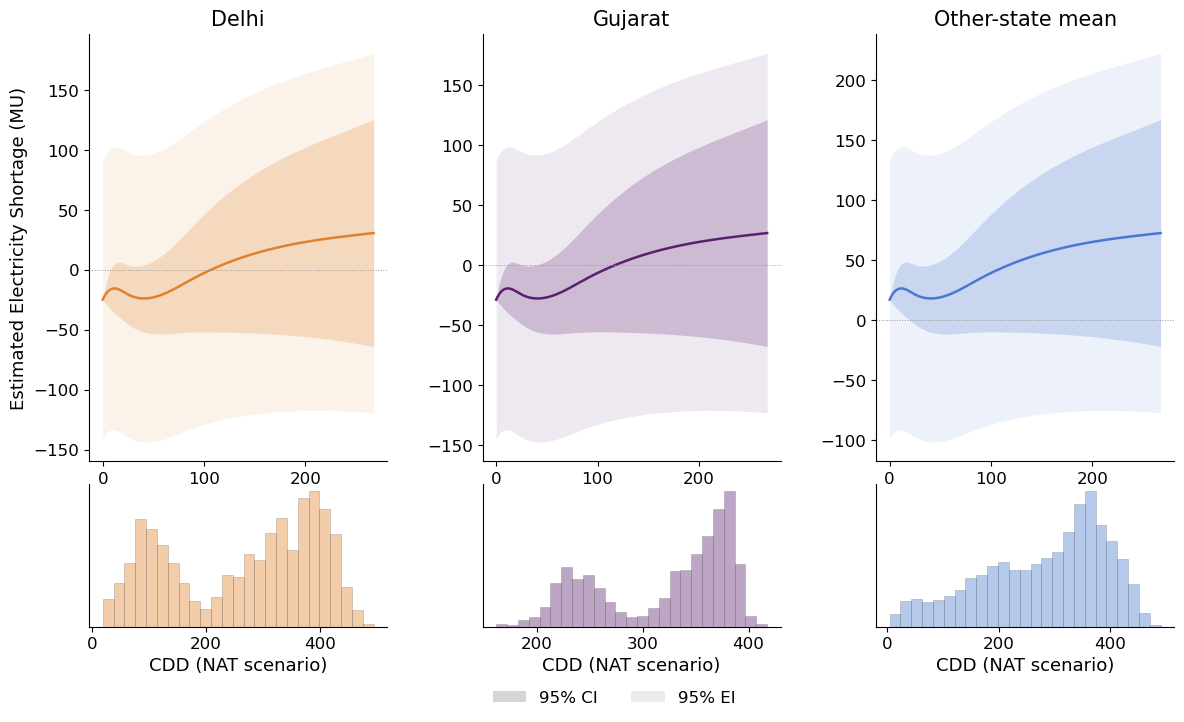

In [10]:
"""Model-implied shortage response to CDD, with the NAT-scenario CDD density.

STUDY MONTHS. The curve's level is the state's fixed-effect baseline, and that
baseline is an average over month effects -- so which months are averaged
changes what the figure says. Over all 12 months the level is "an average
state-month of the year"; over [3, 4, 5] it is "an average pre-monsoon
state-month", which for a seasonal outcome like shortage is a different number
entirely. STUDY_MONTHS controls that average and the CDD density strip below,
so both halves of the figure describe the same period.

The spline SHAPE is unaffected -- it is estimated once on the whole sample, and
restricting months here re-levels the curve rather than re-fitting it.

TWO BANDS ARE DRAWN -- DO NOT CONFUSE THEM:

1) CI (`lo`/`hi`, the darker band): spline-coefficient uncertainty only,
   se(x) = sqrt(B(x) V B(x)'). How precisely the MEAN response is known.

2) EI (`pred_lo`/`pred_hi`, the lighter band drawn behind it): adds the
   model's residual variance, pred_se(x) = sqrt(se(x)^2 + resid_sigma^2). How
   far one actual state-month can land from the mean curve. resid_sigma comes
   from response_curve_<MODEL>.csv (section 11 of the fitting script), not
   from the coefficient/vcov exports this script otherwise uses -- those only
   ever covered the spline terms.

Both bands exclude uncertainty in the state_month/state_year fixed effects
(fixest's vcov() for this export only covered the spline terms) -- so true
uncertainty in the level (not just the shape) is understated by both.
"""

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
import re
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- config ----
ROOT       = ""
STATDIR    = f"{ROOT}data/fit_statistics/shortage_models"
COEF       = f"{STATDIR}/all_models_coefficients.csv"
VCOV_LONG  = f"{STATDIR}/basis_vcov_long.csv"
BASIS_GRID = f"{STATDIR}/cdd_basis_grid.csv"
FE_MONTH   = f"{STATDIR}/fe_state_month_CDD-Ys-Ms.csv"
FE_YEAR    = f"{STATDIR}/fe_state_year_CDD-Ys-Ms.csv"
RESP_CURVE = f"{STATDIR}/response_curve_CDD-Ys-Ms.csv"   # for resid_sigma / CV(RMSE) / mean rel. EI width
NAT_CDD    = f"{ROOT}data/attribution_runs/all_state_cdd.csv"
OUTDIR     = f"{ROOT}figures/shortage_models"

MODEL = "CDD-Ys-Ms"
BASIS = ["cdd_ns1", "cdd_ns2", "cdd_ns3", "cdd_ns4"]

SHOW_PI = True   # draw the estimation-interval band behind the CI on every panel

# Months to average the state_month fixed effects over, and to restrict the CDD
# density to. None = every month present. Both halves of the figure use this.
STUDY_MONTHS = [3, 4, 5]
# Years to average the state_year fixed effects over. None = every year in the
# export (matches the R attribution step's default reference period).
STUDY_YEARS = [2022]

MONTH_LETTER = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J",
                7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}

# state_name spelling as it appears in the FE exports (electricity_panel_with_cdd.csv convention)
STUDY_NAMES = ["Punjab", "Haryana", "Rajasthan", "Delhi", "Uttar_Pradesh", "Odisha",
               "Madhya_Pradesh", "Gujarat", "Chhattisgarh", "Telengana", "Jharkhand",
               "Uttarakhand", "Bihar"]

# full state names as they appear in all_state_cdd.csv -> panel state code
name_to_code = {
    "Punjab": "PJ", "Haryana": "HR", "Rajasthan": "RJ", "NCT of Delhi": "DL",
    "Uttar Pradesh": "UP", "Odisha": "OD", "Madhya Pradesh": "MP", "Gujarat": "GJ",
    "Chhattisgarh": "CG", "Telangana": "TG", "Jharkhand": "JH", "Uttarakhand": "UK",
    "Bihar": "BR",
}

# (state code or None for pooled, display label, state_name, color)
PANELS = [
    ("DL", "Delhi",            "Delhi",   "#E1812C"),
    ("GJ", "Gujarat",          "Gujarat", "#5A1F6E"),
    (None, "Other-state mean", None,      "#4878CF"),
]

# states to pool for the "mean" panel -- excludes Delhi and Gujarat, which get
# their own panels, so the mean isn't partly averaging a state against itself
OTHER_NAMES = [n for n in STUDY_NAMES if n not in ("Delhi", "Gujarat")]
OTHER_CODES = [c for c in name_to_code.values() if c not in ("DL", "GJ")]

period_label = ("-".join(MONTH_LETTER[m] for m in sorted(STUDY_MONTHS))
                if STUDY_MONTHS else "all months")

# ---- load ----
coef  = pd.read_csv(COEF)
vlong = pd.read_csv(VCOV_LONG)
grid  = pd.read_csv(BASIS_GRID)
fe_m  = pd.read_csv(FE_MONTH)
fe_y  = pd.read_csv(FE_YEAR)

if SHOW_PI:
    rc = pd.read_csv(RESP_CURVE)
    if not {"resid_sigma", "cv_rmse_pct", "mean_rel_pi_pct"}.issubset(rc.columns):
        raise SystemExit(
            f"{RESP_CURVE} has no resid_sigma/cv_rmse_pct/mean_rel_pi_pct columns "
            "-- rerun section 11 of the fitting script with the uncertainty edits, "
            "or set SHOW_PI = False to plot the CI only."
        )
    resid_sigma     = float(rc["resid_sigma"].iloc[0])
    cv_rmse_pct     = float(rc["cv_rmse_pct"].iloc[0])
    mean_rel_pi_pct = float(rc["mean_rel_pi_pct"].iloc[0])

# NAT-scenario (counterfactual, no anthropogenic warming) CDD, for the density strip
cf = pd.read_csv(NAT_CDD)
cf = cf[cf["leg"] == "NAT"].copy()
cf["state_code"] = cf["state"].map(name_to_code)
if STUDY_MONTHS is not None:
    have = sorted(int(m) for m in cf["month"].unique())
    absent = [m for m in STUDY_MONTHS if m not in have]
    if absent:
        raise SystemExit(f"STUDY_MONTHS {absent} not in {NAT_CDD}; it has {have}")
    cf = cf[cf["month"].isin(STUDY_MONTHS)]
cf_other = cf[cf["state_code"].isin(OTHER_CODES)]

b = (coef[(coef.model_name == MODEL) & (coef.term.isin(BASIS))]
         .set_index("term")["estimate"].reindex(BASIS).values)
V = (vlong[vlong.model_name == MODEL]
         .pivot(index="term_i", columns="term_j", values="cov")
         .reindex(index=BASIS, columns=BASIS).values)

B = grid[BASIS].values
spline = B @ b                                     # raw spline contribution (uncentered)
se = np.sqrt(np.einsum("gi,ij,gj->g", B, V, B))     # spline-coefficient uncertainty only
# NB: this CI does NOT include uncertainty in the state_month / state_year fixed
# effects (fixest's vcov() for this export only covered the spline terms) -- so
# true uncertainty in the level (not just the shape) is understated here.

if SHOW_PI:
    pred_se = np.sqrt(se**2 + resid_sigma**2)   # + residual variance -> estimation interval

# state baseline = avg(state_month FE) + avg(state_year FE), i.e. the fitted
# level with seasonality and year-to-year variation averaged out, mirroring
# how the attribution step in the R script averages over reference years.
# With STUDY_MONTHS set, the month average covers only those months, so the
# level is that of an average study-period state-month.
def split_tail(series, sep):
    """('Punjab_month3', '_month') -> ('Punjab', 3). Falls back to the trailing
    digits, so a different separator in the export does not break silently."""
    name = series.str.rsplit(sep, n=1).str[0]
    num = series.str.extract(r"(\d+)$")[0]
    if num.isna().any():
        bad = series[num.isna()].unique()[:5]
        raise SystemExit(f"could not read a number off the end of: {list(bad)}")
    return name, num.astype(int)


fe_m["state_name"], fe_m["month"] = split_tail(fe_m["state_month"], "_month")
fe_y["state_name"], fe_y["year"] = split_tail(fe_y["state_year"], "_")

if STUDY_MONTHS is not None:
    have = sorted(fe_m["month"].unique())
    absent = [m for m in STUDY_MONTHS if m not in have]
    if absent:
        raise SystemExit(f"STUDY_MONTHS {absent} not in {FE_MONTH}; it has {have}")
    fe_m = fe_m[fe_m["month"].isin(STUDY_MONTHS)]
if STUDY_YEARS is not None:
    fe_y = fe_y[fe_y["year"].isin(STUDY_YEARS)]

avg_month = fe_m.groupby("state_name")["fe_value"].mean()
avg_year  = fe_y.groupby("state_name")["fe_value"].mean()

missing = [n for n in STUDY_NAMES
           if n not in avg_month.index or n not in avg_year.index]
if missing:
    raise SystemExit(f"no fixed effect for: {missing}\n"
                      f"  month FE has: {sorted(avg_month.index)[:8]} ...\n"
                      "  check the state_name spelling in STUDY_NAMES")

baseline_by_state = avg_month.reindex(STUDY_NAMES) + avg_year.reindex(STUDY_NAMES)
mean_baseline = baseline_by_state.reindex(OTHER_NAMES).mean()

print(f"study period: {period_label} "
      f"({len(STUDY_MONTHS) if STUDY_MONTHS else len(fe_m['month'].unique())} months)"
      + (f", years {sorted(STUDY_YEARS)}" if STUDY_YEARS else ""))
print(f"  month FE averaged over: {sorted(fe_m['month'].unique())}")
print(f"  year  FE averaged over: {sorted(fe_y['year'].unique())}")
print(f"  NAT CDD density: {len(cf):,} rows, "
      f"mean {cf['cdd'].mean():.2f}, months {sorted(cf['month'].unique())}")
print("\nbaseline by state (MU per state-month, this period):")
print(baseline_by_state.sort_values(ascending=False).map("{:,.2f}".format).to_string())
print(f"  other-state mean baseline: {mean_baseline:,.2f}")
if SHOW_PI:
    print(f"\nmodel-wide diagnostics ({MODEL}, from {RESP_CURVE}):")
    print(f"  residual sigma: {resid_sigma:,.2f}")
    print(f"  CV(RMSE): {cv_rmse_pct:.1f}%")
    print(f"  mean relative EI width (obs-weighted): {mean_rel_pi_pct:.1f}%")


def zero_crossings(x, y):
    """CDD values where y changes sign, linearly interpolated between grid
    points. Returns [(cdd, "up"|"down"), ...]; "up" = crosses from below."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    out = []
    for i in range(len(y) - 1):
        a, b_ = y[i], y[i + 1]
        if a == 0.0:
            out.append((x[i], "up" if b_ > 0 else "down"))
        elif a * b_ < 0:
            t = a / (a - b_)                       # fraction of the way to i+1
            out.append((x[i] + t * (x[i + 1] - x[i]), "up" if a < 0 else "down"))
    return out


def describe_crossings(label, y, lo, hi, cdd_src):
    """Where the curve crosses zero, and how much of the NAT CDD distribution
    lies beyond that point -- a crossing far out in the tail is a different
    claim from one in the middle of the observed range."""
    x = grid["cdd"].to_numpy()
    xs = zero_crossings(x, y)
    print(f"  {label:<18}", end="")
    if not xs:
        side = "above" if y[0] > 0 else "below"
        print(f": no crossing -- entirely {side} zero over CDD "
              f"{x.min():.1f}-{x.max():.1f}")
    else:
        parts = []
        v = np.asarray(cdd_src, float)
        for xc, direction in xs:
            share = 100 * (v > xc).mean() if v.size else float("nan")
            word = "turns positive" if direction == "up" else "returns below zero"
            parts.append(f"{word} at CDD {xc:.1f} "
                          f"[{share:.0f}% of NAT state-months are hotter]")
        print(": " + "; ".join(parts))
    # the band tells you where that crossing is distinguishable from zero at all
    lo_x = zero_crossings(x, lo)
    hi_x = zero_crossings(x, hi)
    if lo_x:
        print(f"  {'':<18}  lower CI leaves zero at CDD "
              + ", ".join(f"{c:.1f}" for c, _ in lo_x))
    if hi_x:
        print(f"  {'':<18}  upper CI crosses zero at CDD "
              + ", ".join(f"{c:.1f}" for c, _ in hi_x))
    return xs


MARK_CROSSINGS = False       # also draw a thin vertical line at each crossing

# ---- font sizes ----
FS_TITLE = 15    # panel titles ("Delhi", "Gujarat", ...)
FS_AXIS = 13     # axis labels (y-label, "CDD (NAT scenario)")
FS_TICK = 12     # tick labels
FS_LEGEND = 12   # shared legend

print(f"\nzero crossings of the predicted response ({period_label})")

# ---- figure ----
fig, axes = plt.subplots(2, 3, figsize=(14, 7.8),
                          gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08, wspace=0.32))

for col_idx, (code, label, sname, color) in enumerate(PANELS):
    ax, axd = axes[0, col_idx], axes[1, col_idx]
    baseline = mean_baseline if sname is None else baseline_by_state[sname]
    y = baseline + spline
    lo, hi = y - 1.96 * se, y + 1.96 * se

    if SHOW_PI:
        pred_lo, pred_hi = y - 1.96 * pred_se, y + 1.96 * pred_se
        # EI drawn first (wider, fainter) so the CI sits visibly inside it
        ax.fill_between(grid["cdd"], pred_lo, pred_hi, color=color, alpha=0.10, lw=0, zorder=0)
    ax.plot(grid["cdd"], y, color=color, lw=1.8, zorder=2)
    ax.fill_between(grid["cdd"], lo, hi, color=color, alpha=0.22, lw=0, zorder=1)
    ax.axhline(0, ls=":", lw=0.7, color="0.6")
    ax.set_title(label, fontsize=FS_TITLE)
    if col_idx == 0:
        ax.set_ylabel("Estimated Electricity Shortage (MU)", fontsize=FS_AXIS)
    ax.tick_params(axis="both", labelsize=FS_TICK)

    cdd_src = cf_other["cdd"] if code is None else cf[cf["state_code"] == code]["cdd"]
    xs = describe_crossings(label, y, lo, hi, cdd_src)
    if MARK_CROSSINGS:
        for xc, _ in xs:
            ax.axvline(xc, color=color, ls="--", lw=0.8, alpha=0.6)
    axd.hist(cdd_src, bins=25, density=True, color=color, alpha=0.4,
             edgecolor="0.3", lw=0.4)
    axd.set_xlabel("CDD (NAT scenario)", fontsize=FS_AXIS)
    axd.set_yticks([])
    axd.tick_params(axis="x", labelsize=FS_TICK)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
        axd.spines[s].set_visible(False)

# if SHOW_PI:
#     fig.text(0.01, 0.005,
#               f"CV(RMSE) {cv_rmse_pct:.1f}%  |  mean rel. EI width {mean_rel_pi_pct:.1f}%  "
#               "|  dark band = 95% CI (spline coefficients only), light band = 95% EI (+ residual variance)",
#               fontsize=8, color="#555555", ha="left", va="bottom")

# fig.suptitle(f"Model-implied electricity shortage vs. CDD ({MODEL}), {period_label}\n"
#              "state baseline = avg(state_month FE) + avg(state_year FE) over the study period;\n"
#              "CI = spline coefficients only; density = NAT-scenario CDD",
#              y=1.06, fontsize=10.5)

# --- one legend for the whole figure -----------------------------------------
# Colour here encodes STATE (each panel's own colour, already named by its
# title), not band type -- so the shared legend uses a single neutral grey for
# the CI/EI/zero-line entries rather than repeating each state's colour, and
# names only the generic marks that repeat identically across all three panels.
legend_handles = [
    # Line2D([0], [0], color="0.25", lw=1.8, label="Predicted response"),
    Patch(facecolor="0.25", alpha=0.22, label="95% CI"),
]
if SHOW_PI:
    legend_handles.append(
        Patch(facecolor="0.25", alpha=0.10, label="95% EI")
    )
# legend_handles.append(Line2D([0], [0], color="0.6", lw=0.7, linestyle=":", label="Zero"))

# tight_layout's rect wasn't enough on its own -- it fits the axes into the
# requested rect, but the requested margin itself was too thin. Setting the
# axes' bottom edge directly via subplots_adjust (after tight_layout, so it
# has the final say) is more reliable: the legend stays pinned to the
# figure's bottom edge (bbox_to_anchor y=0.0), so raising this bottom value
# is what pushes the density panels' x-axis label away from the legend.
plt.tight_layout()
fig.subplots_adjust(bottom=0.12)
fig.legend(handles=legend_handles, loc="lower center", ncol=len(legend_handles),
           frameon=False, fontsize=FS_LEGEND, bbox_to_anchor=(0.5, 0.0))

os.makedirs(OUTDIR, exist_ok=True)
stem = f"{OUTDIR}/model_cdd_response_natdensity_{period_label}"
plt.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
plt.savefig(f"{stem}.pdf", bbox_inches="tight")
print(f"\nsaved {stem}.png / .pdf")
plt.show()

13 states: ['BR', 'CG', 'DL', 'GJ', 'HR', 'JH', 'MP', 'OD', 'PJ', 'RJ', 'TG', 'UK', 'UP']

[shortage] highest-shortage month per state:
  UP                   2015-09     1,680.0
  OD                   2016-11       524.1
  RJ                   2022-04       449.0
  BR                   2017-03       441.5
  HR                   2022-04       297.0
  MP                   2022-04       231.0
  GJ                   2021-10       215.0
  PJ                   2022-04       142.0
  JH                   2017-06       121.0
  TG                   2015-05       107.0
  UK                   2022-04        60.0
  CG                   2015-09        55.0
  DL                   2015-09         2.0

[shortage] saved figures/shortage_models/fitted_timeseries.png / .pdf


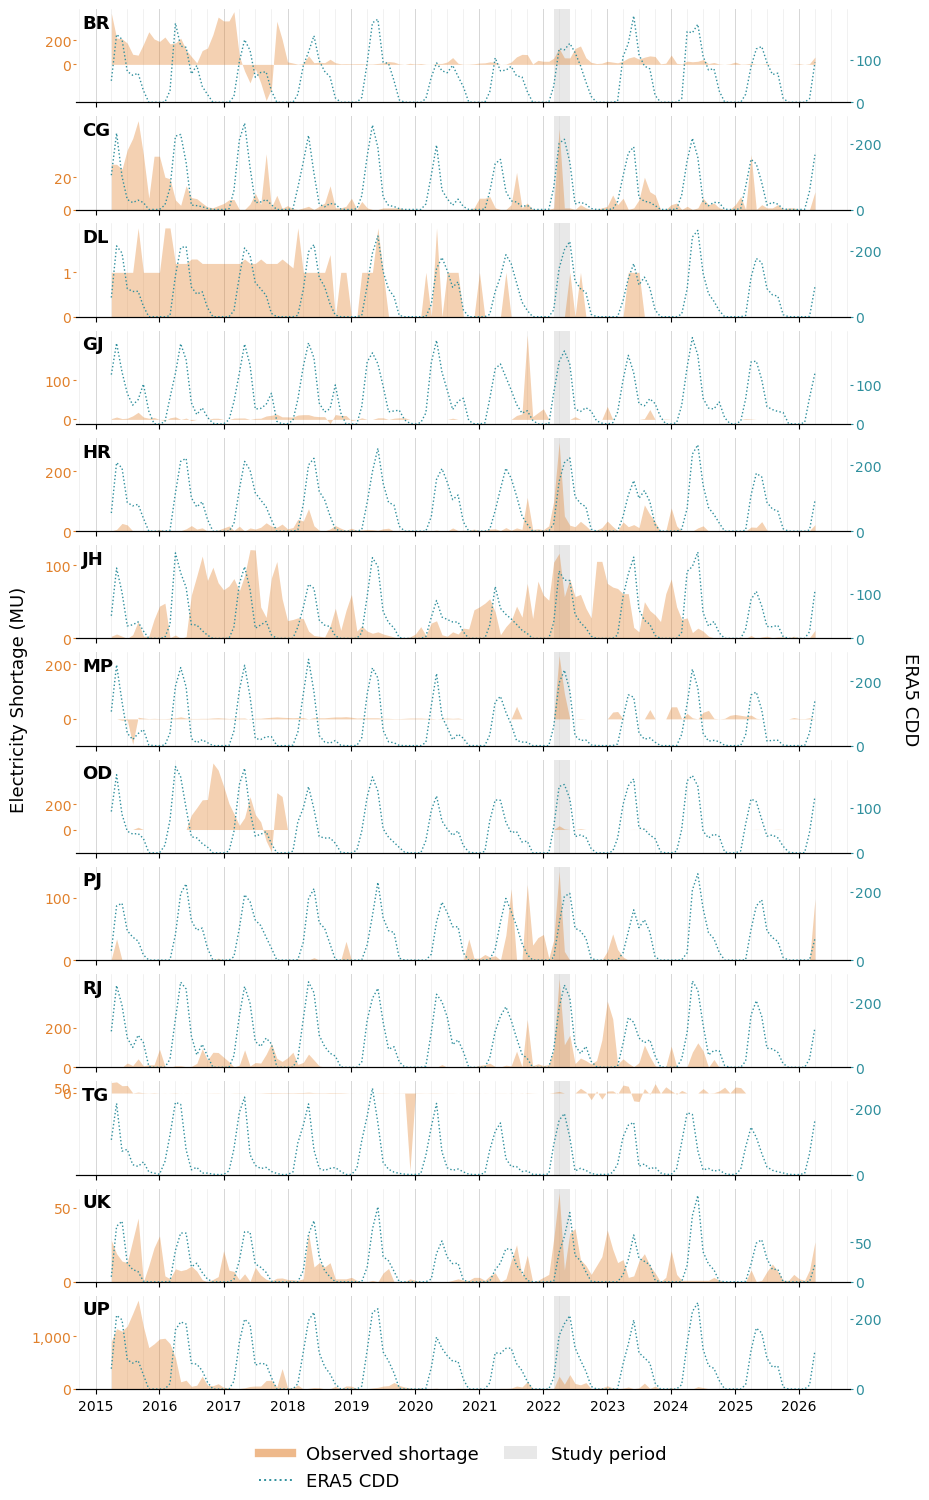

In [11]:
"""
Stacked per-state observed shortage, one panel per state.

Same config-driven structure as demand_timeseries_with_cdd.py (a LABELS dict
for every string, font-size constants, the same helper functions), but with
no rolling mean anywhere: the primary axis is raw observed shortage only,
and the twin axis is ERA5 CDD as a raw monthly dotted line (CDD_AS below),
not a rolling mean.

Optional per-model fitted lines (MODELS) can still be drawn on the primary
axis, same as the original version of this script -- empty by default.

Each panel also carries a shaded band marking the study period
(STUDY_PERIOD, currently Mar-May 2022), drawn behind the data on every
panel, same convention as demand_timeseries_with_cdd.py.
"""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ---------------- config ----------------
ROOT = ""
FIT = f"{ROOT}data/fit_statistics/shortage_models/all_models_fit.csv"
PANEL = f"{ROOT}data/prep_panel/electricity_panel_with_cdd.csv"
OUTDIR = f"{ROOT}figures/shortage_models"

# CDD overlay: raw monthly, dotted, on its own twin axis -- no rolling mean.
CDD = dict(name="cdd", csv=PANEL, value="cdd", unit="CDD", line="#2F8F9D")

# Optional fitted-model overlays on the primary axis, drawn in this order.
# Empty by default, same as the original script.
MODELS = []
# NOTE: "Ys-Ms" moved off orange to "#4878CF" -- the observed series now
# uses orange (see SHORTAGE below), so the two would otherwise collide.
COL = {"Ys-Ms": "#4878CF", "CDD-Ys-Ms": "#3B433B", "CDD-RH-Ys-Ms": "#0000004A"}

# Study-area restriction: only these 13 states are in scope -- same list
# used throughout the codebase (fit_cdd_model_spline.R's study_area_states,
# NAME_TO_CODE in the outage script, etc.), given here in the panel's own
# short-code form since this panel already stores "state" as a code, not a
# full name.
STUDY_AREA_STATES = {"PJ", "HR", "RJ", "DL", "UP", "OD", "MP", "GJ",
                      "CG", "TG", "JH", "UK", "BR"}

COL_GRID = "#bbbbbb"

# ---- figure size -------------------------------------------------------
FIG_W = 9       # inches
ROW_H = 1.15    # inches per state panel -- total figure height is ROW_H * n states

# ---- gridlines / y ticks ----------------------------------------------------
Y_TICKS = 2
GRID_ON = True
GRID_MONTHS = 3        # divides the year: 3 -> Jan/Apr/Jul/Oct. Use a factor
                        # of 12 (1, 2, 3, 4, 6), or the last division of each
                        # year comes out short.

# ---- font sizes (all adjustable here) --------------------------------------
FS_STATE_LABEL = 13   # the per-panel state-name label (top-left of each panel)
FS_TICK = 10          # y-axis tick labels
FS_AXIS_LABEL = 13    # the shared y-axis title, drawn once on the middle panel
FS_LEGEND = 13        # legend text

# Observed-series colour -- matches the "ACT"/observed orange used throughout
# the attribution figures (and now the demand script's own observed series).
SHORTAGE = dict(name="shortage", csv=FIT, value="electricity_shortage",
                unit="MU", fill="#E1812C5D", line="#E1812C")

# ---- study-period highlight -------------------------------------------
# Shaded vertical band marking the study period, drawn on every panel behind
# the data. Edit the dates to move it; set STUDY_PERIOD = None to drop it.
STUDY_PERIOD = dict(start="2022-03-01", end="2022-06-01")   # Mar-May 2022
STUDY_COLOR = "#808080"
STUDY_ALPHA = 0.18

# ---- every piece of text drawn on the figure, in one place --------------
# Edit these strings to relabel axes or the legend without touching any
# plotting code below.
LABELS = dict(
    shortage_axis="Electricity Shortage (MU)",
    era5_axis="ERA5 CDD",
    legend_shortage_fill="Observed shortage",
    legend_era5="ERA5 CDD",
    legend_study_period="Study period",
)


def label(key):
    return LABELS[key]


os.makedirs(OUTDIR, exist_ok=True)


# ---------------- helpers (same as demand_timeseries_with_cdd.py) ----------------
def load(csv, value):
    """One row per state-month, with a date column."""
    d = pd.read_csv(csv)
    missing = {"state", "year", "month", value} - set(d.columns)
    if missing:
        raise SystemExit(f"{csv} is missing {sorted(missing)}\n"
                          f"  columns: {list(d.columns)}")
    d = d.dropna(subset=[value]).copy()
    d["date"] = pd.to_datetime(dict(year=d.year, month=d.month, day=1))
    # the fit file repeats every state-month once per model
    return d.drop_duplicates(["state", "date"])[["state", "date", value]]


def nice_tick(vmax):
    """Largest 1/2/5 x 10^k value at or below 0.9 * vmax."""
    if not np.isfinite(vmax) or vmax <= 0:
        return None
    import math
    target = 0.9 * vmax
    k = math.floor(math.log10(target))
    for m in (5, 2, 1):
        v = m * 10 ** k
        if v <= target:
            return v
    return 10 ** k


def set_y_ticks(ax, vmax, color="#333333", fmt="{:,.0f}"):
    """One or two ticks, no spine."""
    if not Y_TICKS:
        ax.set_yticks([])
        return
    t = nice_tick(vmax)
    if t is None:
        ax.set_yticks([])
        return
    ticks = [0, t] if Y_TICKS >= 2 else [t]
    ax.set_yticks(ticks)
    ax.set_yticklabels([fmt.format(v) for v in ticks])
    ax.tick_params(axis="y", length=2, pad=1.5, labelsize=FS_TICK,
                    colors=color, labelcolor=color)


def print_peak_month(df, value, states):
    """Print the single highest-shortage month for each state, ranked."""
    idx = df[df.state.isin(states)].groupby("state")[value].idxmax()
    peak = df.loc[idx, ["state", "date", value]].sort_values(value, ascending=False)
    print("[shortage] highest-shortage month per state:")
    for _, r in peak.iterrows():
        print(f"  {r['state']:<20s} {r['date']:%Y-%m}  {r[value]:>10,.1f}")
    print()


def add_grid(ax):
    """Vertical gridlines every GRID_MONTHS months, with year lines picked out."""
    if not GRID_ON:
        return
    months = list(range(1, 13, GRID_MONTHS))          # 3 -> [1, 4, 7, 10]
    ax.xaxis.set_major_locator(mdates.YearLocator())  # January = the year line
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=months[1:]))
    ax.grid(which="minor", axis="x", color=COL_GRID, lw=0.4, alpha=0.35)
    ax.grid(which="major", axis="x", color=COL_GRID, lw=0.7, alpha=0.6)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.set_axisbelow(True)


# ---------------- the figure ----------------
def make_shortage_figure(states, stem="fitted_timeseries"):
    """Shortage figure: one zero-anchored axis per panel, raw observed
    shortage only."""
    scfg = SHORTAGE
    df = load(scfg["csv"], scfg["value"])
    cdd = load(CDD["csv"], CDD["value"])
    use = [s for s in states if s in set(df["state"])]
    absent = [s for s in states if s not in use]
    if absent:
        print(f"[shortage] NOTE: dropped {absent} -- absent from {scfg['csv']}")
    no_cdd = [s for s in use if s not in set(cdd["state"])]
    if no_cdd:
        print(f"[shortage] NOTE: no CDD for {no_cdd} -- absent from {CDD['csv']}")

    print_peak_month(df, scfg["value"], use)

    H = ROW_H * len(use)
    fig, axes = plt.subplots(len(use), 1, figsize=(FIG_W, H),
                              sharex=True, gridspec_kw=dict(hspace=0.15))
    axes = np.atleast_1d(axes)
    twins = []

    for ax, s in zip(axes, use):
        o = df[df.state == s].sort_values("date")

        # ---- study-period highlight, drawn first so it sits behind everything ----
        if STUDY_PERIOD is not None:
            ax.axvspan(pd.Timestamp(STUDY_PERIOD["start"]), pd.Timestamp(STUDY_PERIOD["end"]),
                       color=STUDY_COLOR, alpha=STUDY_ALPHA, lw=0, zorder=0)

        # ---- primary axis: raw observed shortage ----
        ax.fill_between(o.date, 0, o[scfg["value"]], color=scfg["fill"], lw=0, zorder=2)
        for m in MODELS:
            g = df[(df.get("model_name") == m) & (df.state == s)].sort_values("date") \
                if "model_name" in df.columns else df.iloc[0:0]
            ax.plot(g.date, g.get(".fitted", []), color=COL[m], lw=0.9, zorder=3)
        s_lo, s_hi = float(o[scfg["value"]].min()), float(o[scfg["value"]].max())
        # Zero-anchored below unless shortage actually dips negative for
        # this state -- a hardcoded set_ylim(0, ...) would otherwise clip
        # any negative shortage out of the visible axis entirely instead of
        # just not padding for it.
        s_ylo = s_lo * 1.05 if s_lo < 0 else 0
        ax.set_ylim(s_ylo, s_hi * 1.05)
        set_y_ticks(ax, s_hi, color=scfg["line"])
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)

        # ---- secondary axis: ERA5 CDD, raw monthly, dotted -- no rolling mean ----
        ax2 = ax.twinx()
        twins.append(ax2)
        co = cdd[cdd.state == s].sort_values("date")
        if len(co):
            ax2.plot(co.date, co[CDD["value"]], color=CDD["line"], lw=1.0, linestyle=":", zorder=3)
            ax2.set_ylim(0, float(co[CDD["value"]].max()) * 1.08)
            set_y_ticks(ax2, float(co[CDD["value"]].max()), color=CDD["line"])
        else:
            ax2.set_yticks([])
        for sp in ("top", "right", "left"):
            ax2.spines[sp].set_visible(False)

        ax.text(0.008, 0.80, s, transform=ax.transAxes, fontsize=FS_STATE_LABEL,
                fontweight="bold", zorder=6)
        add_grid(ax)

    mid = len(use) // 2
    axes[mid].set_ylabel(label("shortage_axis"), labelpad=12, fontsize=FS_AXIS_LABEL)
    twins[mid].set_ylabel(label("era5_axis"), labelpad=14, rotation=270, va="bottom",
                           fontsize=FS_AXIS_LABEL)

    handles = [
        plt.Line2D([0], [0], color=scfg["line"], lw=6, alpha=.55,
                   label=label("legend_shortage_fill")),
        plt.Line2D([0], [0], color=CDD["line"], lw=1.4, linestyle=":",
                   label=label("legend_era5")),
    ]
    handles += [plt.Line2D([0], [0], color=COL[m], lw=1.5, label=m) for m in MODELS]
    if STUDY_PERIOD is not None:
        handles.append(Patch(facecolor=STUDY_COLOR, alpha=STUDY_ALPHA, edgecolor="none",
                              label=label("legend_study_period")))

    LEGEND_NCOL = 2
    rows = -(-len(handles) // LEGEND_NCOL)              # ceil division
    row_h = 0.30 + 0.03 * max(FS_LEGEND - 8, 0)          # inches per legend row, scales with FS_LEGEND
    LEG_IN = row_h * rows + 0.2
    fig.subplots_adjust(bottom=LEG_IN / H, top=1 - 0.05 / H, left=0.07, right=0.93)
    fig.legend(handles=handles, loc="lower center", frameon=False, fontsize=FS_LEGEND,
               bbox_to_anchor=(0.5, 0.0), ncol=LEGEND_NCOL, handlelength=1.8,
               columnspacing=1.4, borderpad=0)

    fig.savefig(f"{OUTDIR}/{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{OUTDIR}/{stem}.png", dpi=150, bbox_inches="tight")
    print(f"[shortage] saved {OUTDIR}/{stem}.png / .pdf")
    plt.show()


# ---------------- run ----------------
if __name__ == "__main__":
    states = sorted(s for s in load(SHORTAGE["csv"], SHORTAGE["value"])["state"].unique()
                     if s in STUDY_AREA_STATES)
    print(f"{len(states)} states: {states}\n")
    make_shortage_figure(states)

# Prayas Outage Minutes Stats

427,584 rows | 36 districts | 14 year-months | 524 members
period: 2016-06 to 2018-12, 14 months
nationwide propagated MC interval: mean -1.783, 95% CI [-3.898, +0.467] min/day

districts mapped: 36 | attributable outage range -5.63 to 0.62 min/day


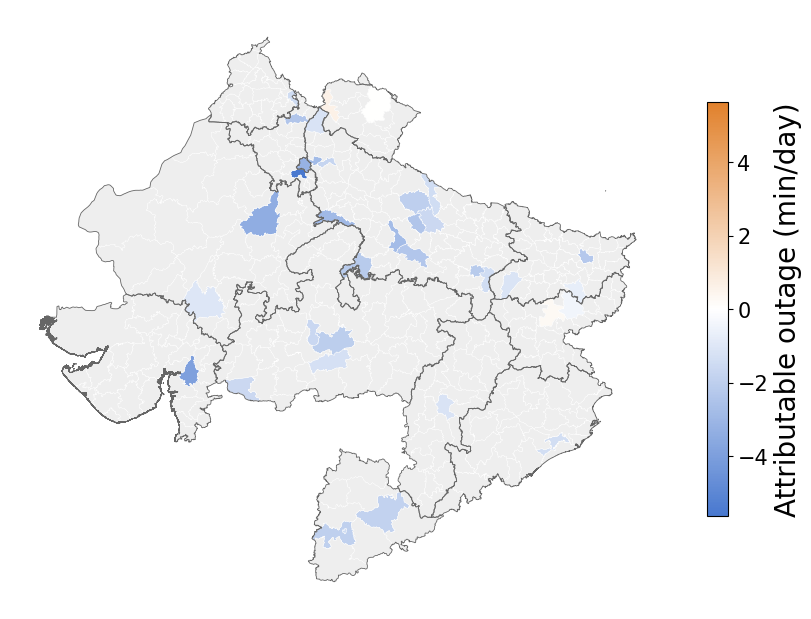

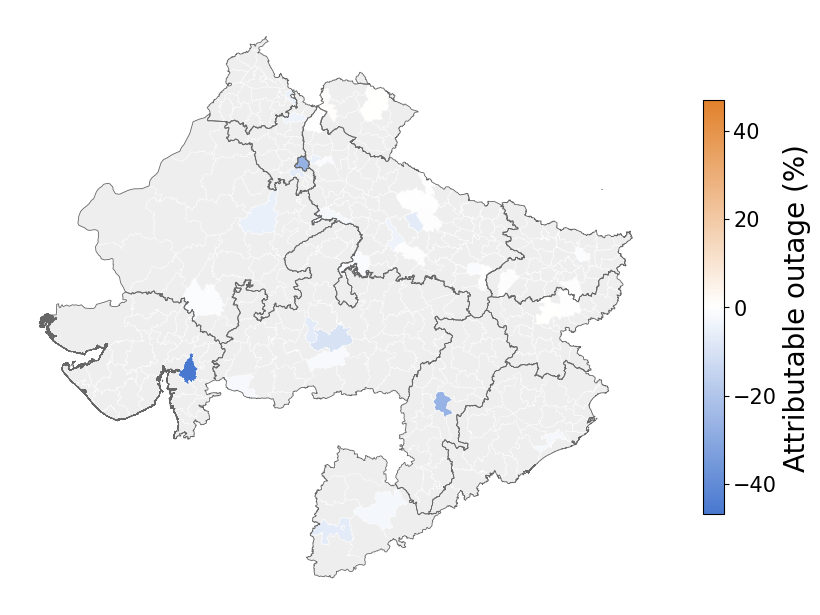

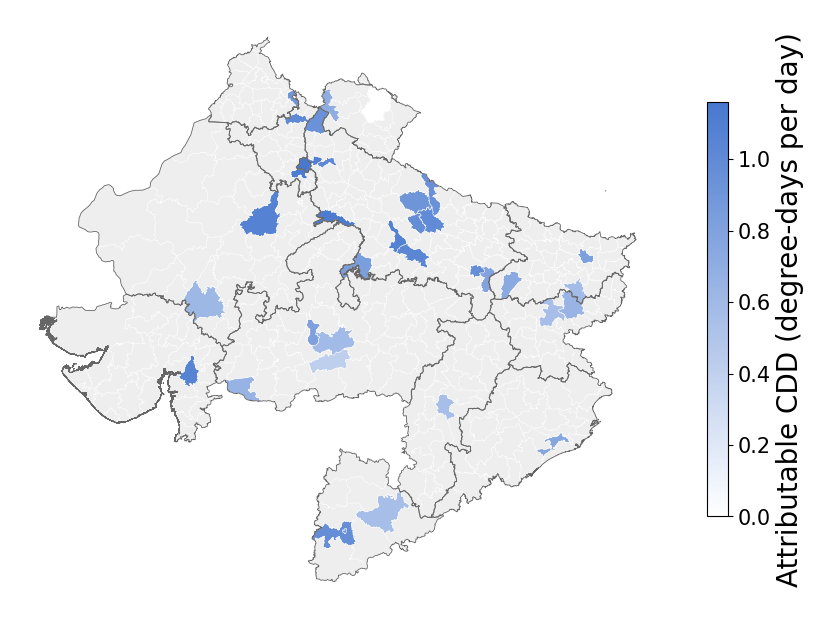

CDD panel: ACT mean 8.00, NAT mean 7.17, attributable mean +0.826 degree-days/day
saved figures/outage_models/attribution_timeseries_levels.png / .pdf
saved figures/outage_models/attribution_timeseries_attributable.png / .pdf


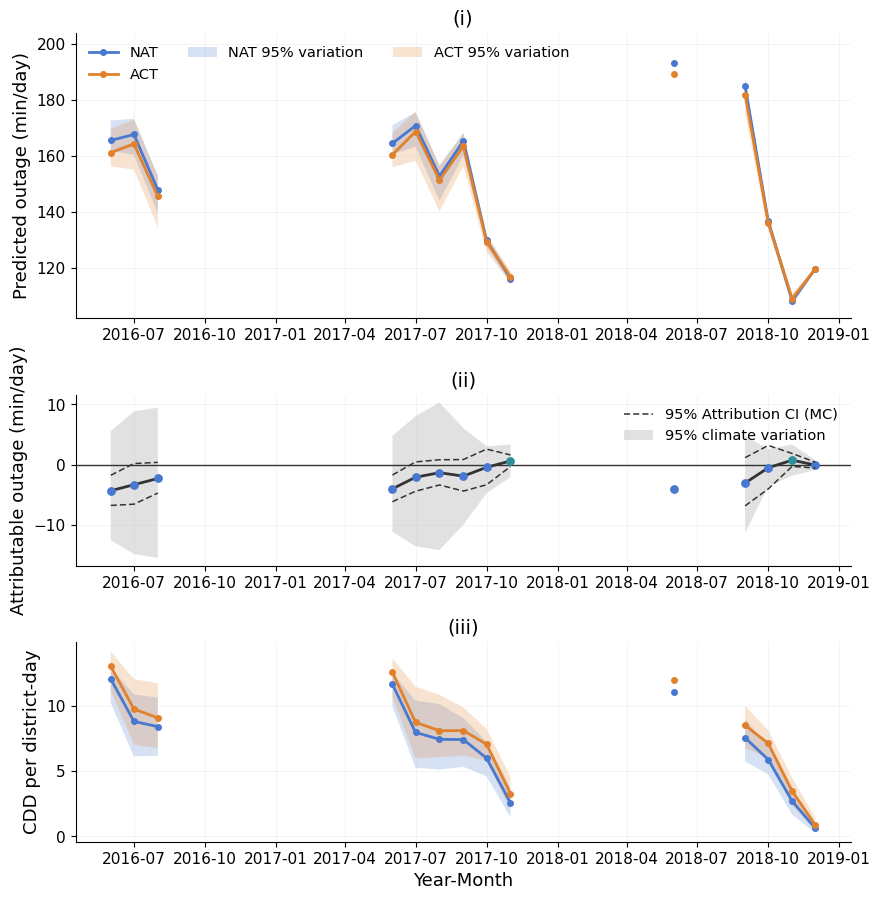


figures and tables -> figures/outage_models
        state     district  obs_days  attributable_cdd  attributable_outage  pct_of_all
      Haryana      Gurgaon       103          1.118960            -5.632156   -7.300640
      Gujarat     Vadodara       335          1.061917            -3.956447  -46.868234
    Rajasthan       Jaipur       284          1.068613            -3.404690   -5.266757
 NCT of Delhi         West       427          1.159107            -3.208405  -26.867039
Uttar Pradesh         Agra       335          1.136343            -2.929516   -2.843612
Uttar Pradesh    Ghaziabad       427          1.095277            -2.821861   -5.274237
Uttar Pradesh Kanpur Nagar       427          1.081826            -2.793128   -4.304974
      Haryana  Kurukshetra       427          1.009309            -2.386004   -4.229201


In [13]:
# =============================================================================
# Attribution figures -- DISTRICT version
# =============================================================================
# Rewritten for attribution_predictions_district.csv (the new section 10 output).
# What changed, and why the old script would have been wrong rather than just
# broken:
#
#  1. GEOGRAPHY. Predictions are per DISTRICT now, not per state. The maps use
#     GADM ADM2 and join on `gadm_key` ("NAME_1||NAME_2") -- the same key the
#     district weights were built on -- so no name aliasing is needed and a
#     spelling difference cannot silently drop a district. A state-level rollup
#     is still produced, but by aggregating districts, not by pretending the
#     rows are states.
#
#  2. YEAR. The old file had no `year`, so it averaged over calendar months.
#     The new one spans 14 year-months across 2016-2018, and the panel is
#     UNBALANCED -- different districts are observed in different year-months.
#     A plain mean would silently weight a district-month with 3 observed days
#     the same as one with 30. Everything here is weighted by `n_obs_days`.
#
#  3. PERCENTAGES are ratios of weighted SUMS, never means of per-cell ratios.
#     Predicted outage is a linear prediction of a zero-bounded outcome and can
#     be <= 0 for low-outage cells, which makes individual ratios explode.
#
#  4. ENSEMBLE CI. The old script took quantiles over all rows at once, mixing
#     across-district variation into what it labelled an ensemble interval.
#     Here each member is collapsed to one number FIRST (weighted mean across
#     districts), then quantiles are taken across the 524 members. That is the
#     ensemble spread and nothing else.
#     NOTE it still excludes sampling uncertainty in the spline coefficients,
#     which is the larger term -- the band is narrower than the true uncertainty.
#
#  5. SIGN. Attributable outage straddles zero (negative in monsoon months,
#     positive post-monsoon), so the outage maps use a DIVERGING scale centred
#     on zero with symmetric limits, and attributable CDD -- positive
#     everywhere -- uses a sequential one. Zero lines are drawn on the series.
#
#  6. NAMING. The CSV calls the factual leg "ALL"; every figure calls it ACT.
#     The two are kept apart by LEG_NAMES / leg() below: CSV values are used for
#     filtering and column lookup, display names for anything a reader sees.
#
#  7. PROPAGATED ATTRIBUTION ERROR (panel (ii) only). The ensemble bands above
#     are climate-member spread; they exclude the larger term, sampling
#     uncertainty in the fitted spline coefficients. That coefficient
#     uncertainty is propagated separately, via the MC loop in
#     fit_prayas_cdd_model_spline.R (section 10h, mc_beta_mat). Panel (ii) gets
#     a MONTH-RESOLVED band (attribution_uncertainty_by_month.csv): the same
#     mc_beta_mat draws, evaluated against each month's own weighted basis
#     vector instead of the whole-period one, so the band's width varies by
#     where that month sits on the fitted CDD-response curve. This is NOT
#     independent month-to-month noise -- every month's draws come from the
#     same shared coefficient uncertainty, so adjacent months' bands are
#     correlated -- it is that one shared uncertainty evaluated at different
#     points. The single NATIONWIDE interval (attribution_uncertainty_overall.csv)
#     is still loaded and printed to console for reference, but is no longer
#     drawn on panel (i) -- it used to appear there as an error bar anchored to
#     the last ACT point, which has been removed. Panel (iii), CDD, is
#     unchanged -- CDD is a physical climate quantity, not a fitted regression
#     output, so no coefficient uncertainty applies to it.
# =============================================================================

# Import matplotlib's PDF backend before geopandas/fiona/pyproj get a chance to
# load. Saving to .pdf for the first time after those geospatial libraries are
# imported trips an assertion inside the `coverage` package.
import matplotlib.backends.backend_pdf  # noqa: F401
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from shapely.geometry import MultiPolygon

# ---------------- config ----------------
ROOT = ""
PRED_CSV = f"{ROOT}data/fit_statistics/outage_models/attribution_predictions_district.csv"
# Nationwide coefficient-uncertainty (Monte Carlo) headline, exported by
# fit_prayas_cdd_model_spline.R section 10h: one row, mean/lo/hi over the
# whole study period (not per-district, not per-month). Printed to console for
# reference only -- no longer drawn on panel (i) (see header note 7).
MC_CSV       = f"{ROOT}data/fit_statistics/outage_models/attribution_uncertainty_overall.csv"
# Same MC draws, evaluated per calendar year-month instead of collapsed over
# the whole period. Used for panel (ii)'s band.
MONTH_MC_CSV = f"{ROOT}data/fit_statistics/outage_models/attribution_uncertainty_by_month.csv"
GADM_L2  = f"{ROOT}data/prep_panel/prep_cdd/gadm/gadm41_IND_2.shp"
GADM_L1  = f"{ROOT}data/prep_panel/prep_cdd/gadm/gadm41_IND_1.shp"
FIGDIR   = f"{ROOT}figures/outage_models"

ALL_LABEL, NAT_LABEL = "ALL", "NAT"     # the labels IN THE CSV -- do not change
CI_LOW, CI_HIGH = 0.025, 0.975          # ensemble percentile band

# What the reader sees. Keys are CSV values; every title, legend entry, axis
# label and direct annotation goes through leg(), so renaming a leg here renames
# it in every figure without touching the data-handling code.
LEG_NAMES = {ALL_LABEL: "ACT", NAT_LABEL: "NAT"}


def leg(scn):
    """Display name for a scenario label from the CSV."""
    return LEG_NAMES.get(scn, scn)


DIFF_LABEL = f"{leg(ALL_LABEL)} - {leg(NAT_LABEL)}"      # "ACT - NAT"

# Categorical pair for the two scenarios. Validated: CVD separation dE 110.7
# (protan), normal-vision 110.9. The orange sits below 3:1 against a white
# surface, so both series carry a legend and direct labels -- never colour alone.
COL_ALL, COL_NAT = "#E1812C", "#4878CF"
CMAP_DIVERGING = LinearSegmentedColormap.from_list(
    "attribution_diverging", ["#4878CF", "#FFFFFF", "#E1812C"])  # NAT -> white -> ALL
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "attribution_sequential", ["#FFFFFF", "#4878CF"])            # white -> blue, for magnitude (CDD)
COL_MISSING = "#eeeeee"
COL_GRID = "#cccccc"
COL_MC = "#333333"          # propagated coefficient-uncertainty, kept visually distinct from the ensemble colours

# Restrict the figures to a subset of year-months, e.g. [(2017, 10), (2017, 11)]
# to show only the post-monsoon months. None = every year-month in the file.
STUDY_YEAR_MONTHS = None

# Third panel under the outage series -- a CDD time series. Toggle it with:
#   "levels"       -> CDD under ACT and NAT, each with its ensemble band
#   "attributable" -> the ACT - NAT difference, with a zero line
# Both variants are written to disk every run, suffixed with the setting. Set
# CDD_PANEL_INTERACTIVE = True in a notebook with ipywidgets for real buttons.
CDD_PANEL = "levels"
CDD_PANEL_INTERACTIVE = False

# Bold ACT / NAT text at the end of each series line. Useful when two series are
# far apart, but the two legs converge at the right-hand end here and the labels
# land on top of each other. Off by default -- the panel legends carry identity.
DIRECT_LABELS = False

# Show the propagated coefficient-uncertainty (MC) band on panel (ii), and
# print the nationwide MC interval to console. Off skips both.
SHOW_MC_ERROR = True

# District names are omitted from the maps -- 70+ labels is unreadable. Set this
# to True for light state-name labels if the maps need orienting.
LABEL_STATES = False
MONTH_LETTER = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J",
                7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}

# ---- font sizes (all adjustable here) --------------------------------------
# choropleth maps
FS_CHORO_LEGEND_LABEL = 20    # colorbar label, e.g. "Attributable outage (min/day)"
FS_CHORO_LEGEND_TICK = 15     # colorbar tick labels
FS_CHORO_STATE_LABEL = 11     # optional state-name overlay (LABEL_STATES = True)
# time-series figure (three stacked panels)
FS_TITLE = 14         # panel titles (a) / (b) / (c)
FS_AXIS_LABEL = 13    # x/y axis labels
FS_TICK = 11          # tick labels, all three panels
FS_LEGEND = 10.5      # legends, all three panels
FS_DIRECT_LABEL = 11  # end-of-line ACT/NAT text when DIRECT_LABELS = True

os.makedirs(FIGDIR, exist_ok=True)

# ---------------- load ----------------
df = pd.read_csv(PRED_CSV)
need = {"gadm_key", "state", "district", "year", "month", "scenario", "member",
        "cdd", "predicted_outage_minutes", "n_obs_days"}
missing = need - set(df.columns)
if missing:
    raise SystemExit(f"{PRED_CSV} is missing {sorted(missing)} -- is this the "
                      f"district output from the new section 10?")

if SHOW_MC_ERROR:
    if not os.path.exists(MC_CSV):
        raise SystemExit(f"missing {MC_CSV} -- run the nationwide MC "
                          "coefficient-uncertainty export (fit_prayas_cdd_model_"
                          "spline.R, section 10h) first, or set SHOW_MC_ERROR = False.")
    mc_overall = pd.read_csv(MC_CSV).iloc[0]
    need_mc = {"mc_attributable_mean", "mc_attributable_lo", "mc_attributable_hi"}
    if not need_mc.issubset(mc_overall.index):
        raise SystemExit(f"{MC_CSV} is missing {sorted(need_mc - set(mc_overall.index))}")

    if not os.path.exists(MONTH_MC_CSV):
        raise SystemExit(f"missing {MONTH_MC_CSV} -- run the month-resolved MC "
                          "coefficient-uncertainty export (fit_prayas_cdd_model_"
                          "spline.R, section 10h) first, or set SHOW_MC_ERROR = False.")
    mc_month = pd.read_csv(MONTH_MC_CSV)
    need_mc_month = {"year", "month", "mc_attributable_mean", "mc_attributable_lo",
                      "mc_attributable_hi"}
    if not need_mc_month.issubset(mc_month.columns):
        raise SystemExit(f"{MONTH_MC_CSV} is missing "
                          f"{sorted(need_mc_month - set(mc_month.columns))}")
    mc_month["date"] = pd.to_datetime(dict(year=mc_month["year"], month=mc_month["month"], day=1))

if STUDY_YEAR_MONTHS is not None:
    keep = pd.MultiIndex.from_tuples(STUDY_YEAR_MONTHS)
    df = df[pd.MultiIndex.from_arrays([df["year"], df["month"]]).isin(keep)].copy()

yms = sorted(set(zip(df["year"], df["month"])))
period_label = f"{yms[0][0]}-{yms[0][1]:02d} to {yms[-1][0]}-{yms[-1][1]:02d}, {len(yms)} months"
print(f"{len(df):,} rows | {df['gadm_key'].nunique()} districts | "
      f"{len(yms)} year-months | {df['member'].nunique()} members")
print(f"period: {period_label}")
if SHOW_MC_ERROR:
    print(f"nationwide propagated MC interval: mean {mc_overall['mc_attributable_mean']:+.3f}, "
          f"95% CI [{mc_overall['mc_attributable_lo']:+.3f}, {mc_overall['mc_attributable_hi']:+.3f}] min/day")

# ---------------- cell level: ensemble mean per district-year-month ----------
cell = (df.groupby(["gadm_key", "state", "district", "year", "month", "scenario"],
                    as_index=False)
          .agg(pred=("predicted_outage_minutes", "mean"),
               cdd=("cdd", "mean"),
               n_obs_days=("n_obs_days", "first")))

wide = (cell.pivot_table(index=["gadm_key", "state", "district", "year", "month",
                                 "n_obs_days"],
                          columns="scenario", values=["pred", "cdd"])
             .reset_index())
wide.columns = ["_".join(c).rstrip("_") if isinstance(c, tuple) else c
                for c in wide.columns]
for c in (f"pred_{ALL_LABEL}", f"pred_{NAT_LABEL}", f"cdd_{ALL_LABEL}", f"cdd_{NAT_LABEL}"):
    if c not in wide.columns:
        raise SystemExit(f"missing column {c} after pivot -- check scenario labels")
wide["d_outage"] = wide[f"pred_{ALL_LABEL}"] - wide[f"pred_{NAT_LABEL}"]
wide["d_cdd"] = wide[f"cdd_{ALL_LABEL}"] - wide[f"cdd_{NAT_LABEL}"]


def weighted_table(frame, keys):
    """Weighted sums first, divide after -- the only safe order when a share and
    its own numerator are computed together."""
    w = frame["n_obs_days"]
    tmp = frame.assign(_w=w,
                        _wd=w * frame["d_outage"],
                        _wc=w * frame["d_cdd"],
                        _wa=w * frame[f"pred_{ALL_LABEL}"],
                        _wn=w * frame[f"pred_{NAT_LABEL}"])
    g = tmp.groupby(keys, as_index=False)[["_w", "_wd", "_wc", "_wa", "_wn"]].sum()
    g["attributable_outage"] = g["_wd"] / g["_w"]
    g["attributable_cdd"] = g["_wc"] / g["_w"]
    g["pred_all"] = g["_wa"] / g["_w"]
    g["pred_nat"] = g["_wn"] / g["_w"]
    g["pct_of_all"] = np.where(g["_wa"] > 0, 100 * g["_wd"] / g["_wa"], np.nan)
    g["obs_days"] = g["_w"]
    return g.drop(columns=["_w", "_wd", "_wc", "_wa", "_wn"])


district = weighted_table(wide, ["gadm_key", "state", "district"])
state_roll = weighted_table(wide, ["state"])
print(f"\ndistricts mapped: {len(district)} | "
      f"attributable outage range {district['attributable_outage'].min():.2f} "
      f"to {district['attributable_outage'].max():.2f} min/day")

# ---------------- geometry ----------------
g2 = gpd.read_file(GADM_L2)
g2["gadm_key"] = g2["NAME_1"].astype(str) + "||" + g2["NAME_2"].astype(str)
if g2["gadm_key"].duplicated().any():
    g2 = g2.dissolve(by="gadm_key", as_index=False)
g1 = gpd.read_file(GADM_L1)

unmatched = set(district["gadm_key"]) - set(g2["gadm_key"])
if unmatched:
    print("WARNING: districts with no GADM polygon:", sorted(unmatched)[:10])

gmap = g2.merge(district, on="gadm_key", how="left")
study_states = sorted(district["state"].unique())
gmap_study = gmap[gmap["NAME_1"].isin(study_states)].copy()
g1_study = g1[g1["NAME_1"].isin(study_states)].copy()


def label_point(geom):
    """Largest sub-polygon's centroid, so a label never lands between the parts
    of a disjoint district."""
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)
    return geom.centroid


def plot_choropleth(gdf, column, title, legend_label, fname, diverging):
    vals = gdf[column].dropna()
    if vals.empty:
        print(f"skipping {fname}: no values")
        return

    if diverging:
        lim = float(np.nanmax(np.abs(vals)))
        # symmetric about zero so equal magnitudes read as equal intensity
        norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
        cmap = CMAP_DIVERGING
    else:
        norm, cmap = None, CMAP_SEQUENTIAL

    fig, ax = plt.subplots(figsize=(8.5, 9.5))
    gdf.plot(ax=ax, color=COL_MISSING, edgecolor="white", linewidth=0.3)
    gdf.plot(column=column, ax=ax, cmap=cmap, norm=norm,
             edgecolor="white", linewidth=0.3, legend=True,
             missing_kwds={"color": COL_MISSING},
             legend_kwds={"label": legend_label, "shrink": 0.45})
    # geopandas appends the new colorbar as the newest axes on the figure --
    # grab it to size its label and tick text (legend_kwds has no fontsize
    # option of its own).
    cax = ax.figure.axes[-1]
    cax.yaxis.label.set_size(FS_CHORO_LEGEND_LABEL)
    cax.tick_params(labelsize=FS_CHORO_LEGEND_TICK)
    # state outlines on top, so districts stay readable
    g1_study.boundary.plot(ax=ax, color="#666666", linewidth=0.6)

    # No district labels: 70+ of them is unreadable, and the colourbar already
    # carries magnitude. The accompanying CSV table is the lookup.
    if LABEL_STATES:
        for _, row in g1_study.iterrows():
            c = label_point(row.geometry)
            ax.annotate(row["NAME_1"], xy=(c.x, c.y), ha="center", va="center",
                        fontsize=FS_CHORO_STATE_LABEL, color="#333333",
                        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

    # ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    stem = os.path.splitext(fname)[0]
    plt.savefig(f"{FIGDIR}/{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{FIGDIR}/{stem}.pdf", bbox_inches="tight")
    plt.show()


# ---- 1. attributable outage minutes per observed district-day --------------
plot_choropleth(
    gmap_study, "attributable_outage",
    title=("Outage minutes attributable to anthropogenic warming "
           f"({DIFF_LABEL})\nper observed district-day, {period_label}"),
    legend_label="Attributable outage (min/day)",
    fname="attribution_district_minutes", diverging=True)

# ---- 1b. as a share of predicted factual outage ----------------------------
plot_choropleth(
    gmap_study, "pct_of_all",
    title=("Attributable outage as a share of predicted factual "
           f"({leg(ALL_LABEL)}) outage\n{period_label}"),
    legend_label="Attributable outage (%)",
    fname="attribution_district_pct", diverging=True)

# ---- 1c. the climate signal on its own -------------------------------------
# Positive everywhere and far more robust than the outage translation, so it is
# worth showing separately rather than only as an input to the outage maps.
plot_choropleth(
    gmap_study, "attributable_cdd",
    title=f"Cooling degree days attributable to anthropogenic warming\n{period_label}",
    legend_label="Attributable CDD (degree-days per day)",
    fname="attribution_district_cdd", diverging=False)

# ---------------- ensemble spread, per member -------------------------------
# Collapse each member to ONE number per year-month first (weighted mean across
# districts), then take quantiles across members. Mixing districts and members
# in a single quantile would inflate the band with cross-sectional variation.
mem = df.merge(wide[["gadm_key", "year", "month", "n_obs_days"]].drop_duplicates(),
               on=["gadm_key", "year", "month"], how="left", suffixes=("", "_w"))
mem["_w"] = mem["n_obs_days"]
mem["_wp"] = mem["_w"] * mem["predicted_outage_minutes"]

ts = (mem.groupby(["year", "month", "scenario", "member"], as_index=False)
         .agg(_w=("_w", "sum"), _wp=("_wp", "sum")))
ts["pred"] = ts["_wp"] / ts["_w"]

ens = (ts.groupby(["year", "month", "scenario"])["pred"]
         .agg(mean="mean",
              lo=lambda x: x.quantile(CI_LOW),
              hi=lambda x: x.quantile(CI_HIGH))
         .reset_index())
ens["date"] = pd.to_datetime(dict(year=ens["year"], month=ens["month"], day=1))

# paired difference per member -> ensemble band on the difference itself
pair = ts.pivot_table(index=["year", "month", "member"], columns="scenario",
                       values="pred").reset_index()
pair["d"] = pair[ALL_LABEL] - pair[NAT_LABEL]
dif = (pair.groupby(["year", "month"])["d"]
           .agg(mean="mean",
                lo=lambda x: x.quantile(CI_LOW),
                hi=lambda x: x.quantile(CI_HIGH))
           .reset_index())
dif["date"] = pd.to_datetime(dict(year=dif["year"], month=dif["month"], day=1))

# ---------------- CDD ensemble series (third panel) -------------------------
# Same construction as the outage series: collapse each MEMBER to one number per
# year-month first (weighted by observed days across districts), then take
# quantiles across the 524 members. The difference panel uses paired member
# differences, since the same member id exists in both legs.
mem["_wc"] = mem["_w"] * mem["cdd"]

cts = (mem.groupby(["year", "month", "scenario", "member"], as_index=False)
          .agg(_w=("_w", "sum"), _wc=("_wc", "sum")))
cts["cdd"] = cts["_wc"] / cts["_w"]

cdd_ens = (cts.groupby(["year", "month", "scenario"])["cdd"]
              .agg(mean="mean",
                   lo=lambda x: x.quantile(CI_LOW),
                   hi=lambda x: x.quantile(CI_HIGH))
              .reset_index())
cdd_ens["date"] = pd.to_datetime(dict(year=cdd_ens["year"], month=cdd_ens["month"], day=1))

cdd_pair = cts.pivot_table(index=["year", "month", "member"], columns="scenario",
                            values="cdd").reset_index()
cdd_pair["d"] = cdd_pair[ALL_LABEL] - cdd_pair[NAT_LABEL]
cdd_dif = (cdd_pair.groupby(["year", "month"])["d"]
                    .agg(mean="mean",
                         lo=lambda x: x.quantile(CI_LOW),
                         hi=lambda x: x.quantile(CI_HIGH))
                    .reset_index())
cdd_dif["date"] = pd.to_datetime(dict(year=cdd_dif["year"], month=cdd_dif["month"], day=1))


def with_gaps(d):
    """Reindex onto a complete monthly axis so lines BREAK across months the
    ensemble does not cover (Sep 2016 - May 2017, Dec 2017 - May 2018, Jul-Aug
    2018). Without this, matplotlib joins the points either side of a gap with a
    straight segment that reads as data."""
    d = d.sort_values("date")
    full = pd.date_range(d["date"].min(), d["date"].max(), freq="MS")
    out = d.set_index("date").reindex(full)
    out.index.name = "date"
    return out.reset_index()


# ---- 2. three stacked panels: outage levels, attributable outage, CDD -------
fig = plt.figure(figsize=(10, 10.5))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1.2, 1.4], hspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

for scn, col in [(NAT_LABEL, COL_NAT), (ALL_LABEL, COL_ALL)]:
    d = with_gaps(ens[ens["scenario"] == scn])
    ax1.fill_between(d["date"], d["lo"], d["hi"], color=col, alpha=0.22, linewidth=0)
    ax1.plot(d["date"], d["mean"], color=col, linewidth=2, marker="o",
             markersize=4, label=leg(scn))
    if DIRECT_LABELS:
        last = d.dropna(subset=["mean"]).iloc[-1]
        ax1.annotate(leg(scn), xy=(last["date"], last["mean"]), xytext=(6, 0),
                     textcoords="offset points", color=col, fontsize=FS_DIRECT_LABEL,
                     fontweight="bold", va="center")

ax1.set_ylabel("Predicted outage (min/day)", fontsize=FS_AXIS_LABEL)
# ax1.set_title(f"Predicted outage under factual ({leg(ALL_LABEL)}) and "
#               f"natural-only ({leg(NAT_LABEL)}) forcing\n"
#               "district-weighted by observed days; bands = 95% ensemble range "
#               "(524 members, coefficient uncertainty NOT included)", fontsize=11)

# ax1.set_title(f"(a) Predicted outage under {leg(ALL_LABEL)} and "
#               f"{leg(NAT_LABEL)} forcing\n", fontsize=FS_TITLE)
ax1.set_title("(i)", fontsize=FS_TITLE)


ax1.tick_params(labelsize=FS_TICK)
ax1.grid(alpha=0.25, color=COL_GRID, linewidth=0.6)
handles1, labels1 = ax1.get_legend_handles_labels()
# climate variation (ensemble spread) swatches, matching the actual fill
# colour/alpha of each scenario's band
handles1 += [plt.Rectangle((0, 0), 1, 1, facecolor=COL_NAT, alpha=0.22),
             plt.Rectangle((0, 0), 1, 1, facecolor=COL_ALL, alpha=0.22)]
labels1 += [f"{leg(NAT_LABEL)} 95% variation",
            f"{leg(ALL_LABEL)} 95% variation"]
ax1.legend(handles1, labels1, frameon=False, loc="upper left", ncol=3, fontsize=FS_LEGEND)
for side in ("top", "right"):
    ax1.spines[side].set_visible(False)

d = with_gaps(dif)
ax2.axhline(0, color="#333333", linewidth=1)
if SHOW_MC_ERROR:
    # month-resolved coefficient-uncertainty bound: the same mc_beta_mat draws
    # as the nationwide interval (printed to console above), but evaluated
    # against each month's own weighted basis vector, so the band narrows or
    # widens with where that month sits on the fitted CDD-response curve.
    # Correlated across months (same underlying draws), not independent
    # monthly noise -- see header note 7. Drawn as two dashed bound lines
    # rather than a translucent fill -- a third semi-transparent layer on top
    # of the existing ensemble fill produced a muddy blur wherever the two
    # overlapped; a solid dashed line reads clearly against any fill underneath.
    dmc = with_gaps(mc_month[["date", "mc_attributable_mean", "mc_attributable_lo",
                               "mc_attributable_hi"]])
    ax2.plot(dmc["date"], dmc["mc_attributable_lo"], color=COL_MC, linewidth=1.1,
             linestyle="--", dashes=(4, 2), zorder=6,
             label="95% Attribution CI (MC)")
    ax2.plot(dmc["date"], dmc["mc_attributable_hi"], color=COL_MC, linewidth=1.1,
             linestyle="--", dashes=(4, 2), zorder=6)
ax2.fill_between(d["date"], d["lo"], d["hi"], color="#888888", alpha=0.25, linewidth=0,
                  label="95% climate variation")
ax2.plot(d["date"], d["mean"], color="#333333", linewidth=2, marker="o", markersize=4)
pos = d[d["mean"] > 0]      # NaN gap rows fall out of both masks
neg = d[d["mean"] <= 0]
ax2.scatter(pos["date"], pos["mean"], color="#2F8F9D", zorder=5, s=28)
ax2.scatter(neg["date"], neg["mean"], color=COL_NAT, zorder=5, s=28)
ax2.set_ylabel("Attributable outage (min/day)", fontsize=FS_AXIS_LABEL)
ax2.set_title("(ii)", fontsize=FS_TITLE)
ax2.tick_params(labelsize=FS_TICK)
ax2.grid(alpha=0.25, color=COL_GRID, linewidth=0.6)
ax2.legend(frameon=False, fontsize=FS_LEGEND, loc="upper right")
for side in ("top", "right"):
    ax2.spines[side].set_visible(False)

print("CDD panel: %s mean %.2f, %s mean %.2f, attributable mean %+.3f degree-days/day"
      % (leg(ALL_LABEL), cdd_ens.loc[cdd_ens.scenario == ALL_LABEL, "mean"].mean(),
         leg(NAT_LABEL), cdd_ens.loc[cdd_ens.scenario == NAT_LABEL, "mean"].mean(),
         cdd_dif["mean"].mean()))


def cdd_panel(ax, which):
    """Third panel. which = "levels" (ACT and NAT CDD) or "attributable" (ACT-NAT)."""
    ax.clear()
    if which == "levels":
        for scn, col in [(NAT_LABEL, COL_NAT), (ALL_LABEL, COL_ALL)]:
            d = with_gaps(cdd_ens[cdd_ens["scenario"] == scn])
            ax.fill_between(d["date"], d["lo"], d["hi"], color=col, alpha=0.22, linewidth=0)
            ax.plot(d["date"], d["mean"], color=col, linewidth=2, marker="o",
                     markersize=4, label=leg(scn))
            if DIRECT_LABELS:
                last = d.dropna(subset=["mean"]).iloc[-1]
                ax.annotate(leg(scn), xy=(last["date"], last["mean"]), xytext=(6, 0),
                             textcoords="offset points", color=col, fontsize=FS_DIRECT_LABEL,
                             fontweight="bold", va="center")
        ax.set_ylabel("CDD per district-day", fontsize=FS_AXIS_LABEL)
        ax.set_title("(iii)",
                     fontsize=FS_TITLE)
        # ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper right", ncol=2)
    elif which == "attributable":
        d = with_gaps(cdd_dif)
        ax.axhline(0, color="#333333", linewidth=1)
        ax.fill_between(d["date"], d["lo"], d["hi"], color="#2F8F9D", alpha=0.22,
                         linewidth=0)
        ax.plot(d["date"], d["mean"], color="#2F8F9D", linewidth=2, marker="o",
                 markersize=4, label=DIFF_LABEL)
        ax.set_ylabel("Attributable CDD\n(degree-days per day)", fontsize=FS_AXIS_LABEL)
        # Short form -- the original long form ("...unlike the outage
        # translation above") no longer fits this single-column panel's width
        # at FS_TITLE's larger size without running off the left edge; the
        # full explanation stays here as a comment.
        ax.set_title("(c) Attributable CDD -- positive in every month",
                     fontsize=FS_TITLE)
        # ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper right")
    else:
        raise ValueError(f'CDD_PANEL must be "levels" or "attributable", got {which!r}')
    ax.set_xlabel("Year-Month", fontsize=FS_AXIS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.grid(alpha=0.25, color=COL_GRID, linewidth=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


cdd_panel(ax3, CDD_PANEL)


def save_timeseries(which):
    stem = f"{FIGDIR}/attribution_timeseries_{which}"
    fig.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"saved {stem}.png / .pdf")


save_timeseries(CDD_PANEL)

if CDD_PANEL_INTERACTIVE:
    # Notebook toggle. The static exports above are unaffected; this redraws in place.
    try:
        import ipywidgets as widgets
        from IPython.display import display

        picker = widgets.ToggleButtons(
            options=[(f"CDD: {leg(ALL_LABEL)} vs {leg(NAT_LABEL)}", "levels"),
                     (f"CDD: attributable ({DIFF_LABEL})", "attributable")],
            value=CDD_PANEL, description="Panel 3:")

        def _on_change(change):
            if change["name"] == "value":
                cdd_panel(ax3, change["new"])
                save_timeseries(change["new"])
                fig.canvas.draw_idle()

        picker.observe(_on_change)
        display(picker)
    except ImportError:
        print("CDD_PANEL_INTERACTIVE needs ipywidgets and an interactive backend "
              "(%matplotlib widget); falling back to the CDD_PANEL constant.")
else:
    # Write the other variant too, so both exist on disk, then restore the view.
    other = "attributable" if CDD_PANEL == "levels" else "levels"
    cdd_panel(ax3, other)
    save_timeseries(other)
    cdd_panel(ax3, CDD_PANEL)

plt.show()

# ---- tables alongside the figures ------------------------------------------
# Column names keep the CSV's vocabulary (pred_all, pct_of_all) so the tables
# stay joinable with the prediction file; only the figures say ACT.
district.sort_values("attributable_outage").to_csv(
    f"{FIGDIR}/attribution_district_table.csv", index=False)
state_roll.sort_values("attributable_outage").to_csv(
    f"{FIGDIR}/attribution_state_table.csv", index=False)
print(f"\nfigures and tables -> {FIGDIR}")
print(district[["state", "district", "obs_days", "attributable_cdd",
                 "attributable_outage", "pct_of_all"]]
      .sort_values("attributable_outage").head(8).to_string(index=False))

13 states: ['BR', 'CG', 'DL', 'GJ', 'HR', 'JH', 'MP', 'OD', 'PJ', 'RJ', 'TG', 'UK', 'UP']

[outage] highest-outage day per state:
  DL                   2014-11-01     1,440.0
  GJ                   2017-04-01     1,440.0
  HR                   2014-12-04     1,440.0
  OD                   2014-11-11     1,440.0
  UP                   2014-12-24     1,376.0
  JH                   2017-07-25     1,349.3
  BR                   2016-01-04     1,217.5
  RJ                   2015-11-24       791.5
  TG                   2015-01-06       720.2
  PJ                   2018-05-06       696.0
  UK                   2017-12-12       597.0
  MP                   2015-07-05       592.0
  CG                   2018-06-23       364.0

[outage] district-day count per state (full-day-monitored, kept locations only):
  UP                    11114
  MP                     4103
  TG                     3227
  BR                     2944
  HR                     2137
  RJ                     1898
  UK      

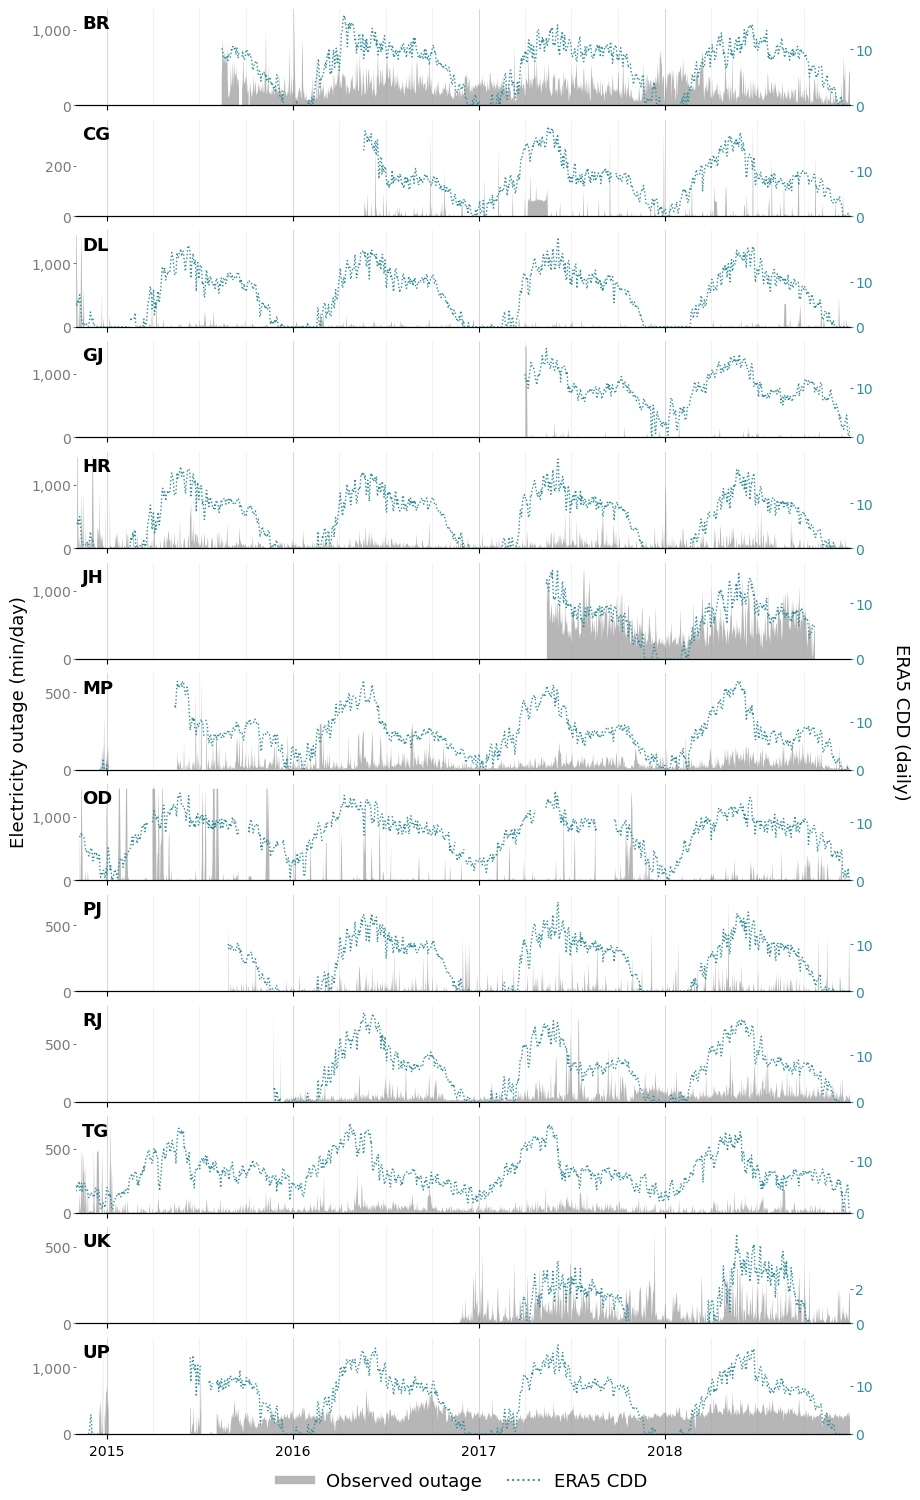

In [14]:
"""
Stacked per-state observed outage, one panel per state.

Same format as fitted_timeseries_shortage.py: a config-driven structure (a
LABELS dict for every string, font-size constants, the same helper
functions), a single zero-anchored axis per panel (no rolling mean, no
study-period highlight). The x axis is limited to the actual date range of
the loaded data (no artificial widening from a highlighted period or from
sharing a range with a wider dataset).

The prayas outage panel stores states as full names (unlike the demand/
shortage panel, where "state" is already the short panel code) -- NAME_TO_CODE
below is the same full-name -> code mapping used elsewhere in the codebase
(fit_cdd_model_spline.R, model_cdd_response_natdensity.py,
attribution_choropleth_lines.py), applied on load so panel labels, prints,
and the state list all use the same abbreviations as those other scripts.

No fitted/estimated series are drawn anywhere -- the observed-outage series
is loaded straight from esmi_outage_cdd_panel.csv (the raw district-day
panel), not from any model-fit output (all_models_fit.csv), so there is no
dependency on which rows a particular model happened to fit.

Both the outage series and the CDD overlay (raw DAILY, dotted, no rolling
mean -- same style as fitted_timeseries_shortage.py, but at the panel's own
native resolution rather than resampled) come from that same raw panel via
load_pooled(): esmi_outage_cdd_panel.csv is at district-DAY resolution, one
row per district per day (sometimes further split by monitoring location).
load_pooled() pools every district/location row reporting on a given
calendar day into a single mean for that day -- so each line is a straight
average ACROSS DISTRICTS on that day, not a further average across days
into a month -- and, since it only reads rows that exist in that file, both
lines automatically only cover the exact days outage data actually spans
("just for the time period").

load_pooled() applies the same row-quality filters fit_prayas_cdd_model_spline.R
applies to data_panel before fitting anything (so the pooled means reflect the
same sample the model itself sees), in the same order as the R script: first,
a study-area restriction to STUDY_AREA_STATES (the same 13 states as
NAME_TO_CODE, matching the R script's study_area_states exactly, applied on
the full state name before any mapping) -- unconditionally, on every call,
same as the demand/shortage scripts, which only ever see study-area states
because their own source panel is already restricted to them; second, a
full-day-monitored filter (observed_minutes == FULL_DAY_MINUTES, 1440 = 24h *
60min) -- a partially-monitored day can only show LESS outage, mechanically,
than a fully-monitored one, so it would otherwise drag the pooled mean down
for no substantive reason; third, a location-quality filter that drops any
individual monitoring location (state, district, "Location name") with fewer
than MIN_LOCATION_DAYS (365) distinct full-day-monitored dates, matching the
R script's semi_join(keep_loc, ...) step -- a district keeps whichever of its
locations clear the bar, it is only dropped entirely if none of them do. This
script does not replicate the R script's separate study_period_months filter,
since with the current config (all 12 months) it is a no-op -- if
study_period_months is ever narrowed in the R script, a matching month filter
would need to be added here too.
"""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------- config ----------------
ROOT = ""
CDD_PANEL = f"{ROOT}data/prayas_out/esmi_outage_cdd_panel.csv"
OUTDIR = f"{ROOT}figures/outage_models"

# CDD overlay: pooled across-district mean per calendar day, raw daily,
# dotted -- no rolling mean, no monthly resampling. See load_pooled() for
# what "pooled" means here. Column is
# "cdd_tmean" (CDD of the district-mean temperature) -- confirmed against
# fit_prayas_cdd_model_spline.R's panel_predictor, which is what CDD-Yd-Md
# (the dry-bulb model used elsewhere) is actually fit on; the raw file has
# no plain "cdd" column, only cdd_tmean/cdd_cellmean/cdd_swbgt/cdd_dewpt.
CDD = dict(name="cdd", csv=CDD_PANEL, value="cdd_tmean", unit="CDD", line="#2F8F9D")

# Row-quality filters applied in load_pooled(), matching
# fit_prayas_cdd_model_spline.R's data_panel prep exactly (see module
# docstring for the reasoning).
FULL_DAY_MINUTES = 1440   # observed_minutes == this marks a fully-monitored day
MIN_LOCATION_DAYS = 365   # a monitoring location needs at least this many
                          # distinct full-day-monitored dates to be kept

# Full state name (as stored in the prayas outage panel) -> panel state code.
# Same mapping as fit_cdd_model_spline.R / model_cdd_response_natdensity.py /
# attribution_choropleth_lines.py.
NAME_TO_CODE = {
    "Punjab": "PJ", "Haryana": "HR", "Rajasthan": "RJ", "NCT of Delhi": "DL",
    "Uttar Pradesh": "UP", "Odisha": "OD", "Madhya Pradesh": "MP", "Gujarat": "GJ",
    "Chhattisgarh": "CG", "Telangana": "TG", "Jharkhand": "JH", "Uttarakhand": "UK",
    "Bihar": "BR",
}

# Study-area restriction: the prayas outage panel covers many more states
# than the study area, unlike the demand/shortage panel (already restricted
# to these same states upstream) -- this is the same study_area_states list
# fit_prayas_cdd_model_spline.R filters data_panel to (its full-name form is
# exactly NAME_TO_CODE's key set). Applied on the raw full state name, before
# any of the row-quality filters below, same order as the R script.
STUDY_AREA_STATES = set(NAME_TO_CODE)

COL_GRID = "#bbbbbb"

# ---- figure size -------------------------------------------------------
FIG_W = 9       # inches
ROW_H = 1.15    # inches per state panel -- total figure height is ROW_H * n states

# ---- gridlines / y ticks ----------------------------------------------------
Y_TICKS = 2
GRID_ON = True
GRID_MONTHS = 3        # divides the year: 3 -> Jan/Apr/Jul/Oct. Use a factor
                        # of 12 (1, 2, 3, 4, 6), or the last division of each
                        # year comes out short.

# ---- font sizes (all adjustable here) --------------------------------------
FS_STATE_LABEL = 13   # the per-panel state-name label (top-left of each panel)
FS_TICK = 10          # y-axis tick labels
FS_AXIS_LABEL = 13    # the shared y-axis title, drawn once on the middle panel
FS_LEGEND = 13        # legend text

# Observed-series colour. NOTE: this uses the grey "observed" colour
# established elsewhere in the codebase (COL_OBS = "#7a7a7a" in
# response_curve_combined.py) rather than the orange used for demand/
# shortage's observed series, to keep it visually distinct from the CDD
# line and from those other scripts' observed fills.
# Loaded straight from CDD_PANEL (esmi_outage_cdd_panel.csv), pooled to one
# value per calendar day (across districts) -- observed outage, not a model
# fit, and not resampled to monthly.
OUTAGE = dict(name="outage", csv=CDD_PANEL, value="outage_minutes",
              unit="minutes", fill="#7a7a7a8C", line="#7a7a7a")

# ---- every piece of text drawn on the figure, in one place --------------
# Edit these strings to relabel axes or the legend without touching any
# plotting code below.
LABELS = dict(
    outage_axis="Electricity outage (min/day)",
    era5_axis="ERA5 CDD (daily)",
    legend_outage_fill="Observed outage",
    legend_era5="ERA5 CDD",
)


def label(key):
    return LABELS[key]


os.makedirs(OUTDIR, exist_ok=True)


# ---------------- helpers (same as fitted_timeseries_shortage.py) ----------------
def load_pooled(csv, value, states=None):
    """Pool esmi_outage_cdd_panel.csv's district-DAY rows into one mean per
    calendar DAY, for any column in that file -- used for both the observed
    outage series and the CDD overlay, since both live in the same raw
    panel.

    This file has many rows per calendar day (one per district, sometimes
    further split by monitoring location), so every district/location row
    reporting on a given day is averaged together (groupby(...).mean()),
    which is what makes this a POOLED mean: each observed district counts
    equally on that day, rather than first averaging to a per-district
    value over some longer window and then averaging those. Unlike an
    earlier version of this function, days are NOT further resampled or
    averaged into months -- the returned series sits at the panel's own
    native daily resolution, one point per actual calendar date. States are
    mapped through NAME_TO_CODE (after the STUDY_AREA_STATES restriction
    below, so every remaining name always has an entry) so labels match the
    other scripts. Only days actually present in this file are returned, so
    the result is naturally limited to whatever period the data spans. Pass
    states to further restrict to a given sub-list (e.g. `use`); omit it
    (None) to keep every study-area state, e.g. for the initial
    state-discovery call.

    Before pooling, applies the same row-quality filters
    fit_prayas_cdd_model_spline.R applies to data_panel before fitting --
    see the module docstring for why: first the study-area restriction
    (state in STUDY_AREA_STATES), then a full-day-monitored filter
    (observed_minutes == FULL_DAY_MINUTES), then a per-location filter
    dropping any (state, district, Location name) with fewer than
    MIN_LOCATION_DAYS distinct full-day-monitored dates.
    """
    d = pd.read_csv(csv)
    required = {"state", "district", "Location name", "date",
                "observed_minutes", value}
    missing = required - set(d.columns)
    if missing:
        raise SystemExit(f"{csv} is missing {sorted(missing)}\n"
                          f"  columns: {list(d.columns)}")
    d = d.dropna(subset=[value]).copy()
    d["date"] = pd.to_datetime(d["date"])   # real calendar day, not a month bucket

    # --- study-area restriction (fit_prayas_cdd_model_spline.R, ~L46) ---
    d = d[d["state"].isin(STUDY_AREA_STATES)]

    d["state"] = d["state"].map(NAME_TO_CODE).fillna(d["state"])
    if states is not None:
        d = d[d["state"].isin(states)]

    # --- full-day-monitored filter (fit_prayas_cdd_model_spline.R, ~L90) ---
    d = d[d["observed_minutes"] == FULL_DAY_MINUTES]

    # --- location-quality filter (~L98-170): keep only locations with at
    # least MIN_LOCATION_DAYS distinct full-day-monitored dates -- a district
    # is dropped only if every one of its locations falls short.
    loc_n_days = d.groupby(["state", "district", "Location name"])["date"].transform("nunique")
    d = d[loc_n_days >= MIN_LOCATION_DAYS]

    # pooled ACROSS DISTRICTS within a single calendar day -- no grouping by
    # year/month, so this is a daily series, not a monthly one.
    pooled = d.groupby(["state", "date"], as_index=False)[value].mean()
    return pooled[["state", "date", value]]


def nice_tick(vmax):
    """Largest 1/2/5 x 10^k value at or below 0.9 * vmax."""
    if not np.isfinite(vmax) or vmax <= 0:
        return None
    import math
    target = 0.9 * vmax
    k = math.floor(math.log10(target))
    for m in (5, 2, 1):
        v = m * 10 ** k
        if v <= target:
            return v
    return 10 ** k


def set_y_ticks(ax, vmax, color="#333333", fmt="{:,.0f}"):
    """One or two ticks, no spine."""
    if not Y_TICKS:
        ax.set_yticks([])
        return
    t = nice_tick(vmax)
    if t is None:
        ax.set_yticks([])
        return
    ticks = [0, t] if Y_TICKS >= 2 else [t]
    ax.set_yticks(ticks)
    ax.set_yticklabels([fmt.format(v) for v in ticks])
    ax.tick_params(axis="y", length=2, pad=1.5, labelsize=FS_TICK,
                    colors=color, labelcolor=color)


def print_peak_day(df, value, states):
    """Print the single highest-outage DAY for each state, ranked.

    df is now a daily series (see load_pooled()), so this is a genuine
    single-day peak, not a month-bucket peak -- renamed from
    print_peak_month accordingly.
    """
    idx = df[df.state.isin(states)].groupby("state")[value].idxmax()
    peak = df.loc[idx, ["state", "date", value]].sort_values(value, ascending=False)
    print("[outage] highest-outage day per state:")
    for _, r in peak.iterrows():
        print(f"  {r['state']:<20s} {r['date']:%Y-%m-%d}  {r[value]:>10,.1f}")
    print()


def print_district_day_counts(csv, states):
    """Print the number of distinct district-days per state that actually
    feed the pooled series above -- straight from the raw district-day
    panel, but restricted by the same filters load_pooled() applies
    (study-area states, full-day-monitored rows, locations clearing
    MIN_LOCATION_DAYS), so this count matches what the figure is built from
    rather than the raw, unfiltered file.

    Counts distinct (district, date) pairs per state, so a district with
    several monitoring locations reporting on the same day still counts as
    one district-day. This replaces the old model-fit-based count (which
    could only see all_models_fit.csv's district-MONTH granularity, since
    that file has no day-level column) -- now that the figure no longer
    depends on any model-fit output, the real day-resolution count is just
    read directly off the source panel.
    """
    raw = pd.read_csv(csv)
    required = {"state", "district", "Location name", "date", "observed_minutes"}
    missing = required - set(raw.columns)
    if missing:
        print(f"[outage] NOTE: {csv} is missing {sorted(missing)}; cannot count district-days")
        return
    raw = raw[raw["state"].isin(STUDY_AREA_STATES)]
    raw["state"] = raw["state"].map(NAME_TO_CODE).fillna(raw["state"])
    raw = raw[raw["state"].isin(states)]
    raw = raw[raw["observed_minutes"] == FULL_DAY_MINUTES]
    loc_n_days = raw.groupby(["state", "district", "Location name"])["date"].transform("nunique")
    raw = raw[loc_n_days >= MIN_LOCATION_DAYS]
    counts = (raw.drop_duplicates(["state", "district", "date"])
                 .groupby("state").size().sort_values(ascending=False))
    print("[outage] district-day count per state (full-day-monitored, kept locations only):")
    for s, n in counts.items():
        print(f"  {s:<20s} {n:>6d}")
    print(f"  TOTAL: {int(counts.sum())}\n")


def print_location_district_counts(csv, states):
    """Print the number of distinct monitoring locations and distinct
    districts per state that actually feed the pooled series above.

    Same filtered sample as print_district_day_counts (study-area states,
    full-day-monitored rows, locations clearing MIN_LOCATION_DAYS) -- so
    these are the locations/districts actually contributing to the figure,
    not every location/district the raw ESMI panel happens to mention for
    that state (a location that never clears the quality bar is not counted
    here). A district is counted once even if several of its locations
    cleared the bar.
    """
    raw = pd.read_csv(csv)
    required = {"state", "district", "Location name", "date", "observed_minutes"}
    missing = required - set(raw.columns)
    if missing:
        print(f"[outage] NOTE: {csv} is missing {sorted(missing)}; cannot count locations/districts")
        return
    raw = raw[raw["state"].isin(STUDY_AREA_STATES)]
    raw["state"] = raw["state"].map(NAME_TO_CODE).fillna(raw["state"])
    raw = raw[raw["state"].isin(states)]
    raw = raw[raw["observed_minutes"] == FULL_DAY_MINUTES]
    loc_n_days = raw.groupby(["state", "district", "Location name"])["date"].transform("nunique")
    raw = raw[loc_n_days >= MIN_LOCATION_DAYS]
    counts = raw.groupby("state").agg(
        n_locations=("Location name", "nunique"),
        n_districts=("district", "nunique"),
    ).sort_values("n_locations", ascending=False)
    print("[outage] locations and districts per state (full-day-monitored, kept locations only):")
    for s, r in counts.iterrows():
        print(f"  {s:<20s} locations={int(r['n_locations']):>4d}  districts={int(r['n_districts']):>4d}")
    print(f"  TOTAL: locations={int(counts['n_locations'].sum())}  "
          f"districts={int(counts['n_districts'].sum())}\n")


def print_report_duration(csv, states):
    """Print the reporting span (first day to last day, and its length) per
    state.

    Same filtered sample as print_district_day_counts / print_location_
    district_counts (study-area states, full-day-monitored rows, locations
    clearing MIN_LOCATION_DAYS), so this is the span the plotted series
    actually draws from -- not the raw panel's full span, which can start
    well before a state's monitoring locations were reporting continuously
    enough to clear the quality filters. Note the span is just first-to-last
    calendar date; it says nothing about gaps in between (see
    print_district_day_counts / reindex_daily for those).
    """
    raw = pd.read_csv(csv)
    required = {"state", "district", "Location name", "date", "observed_minutes"}
    missing = required - set(raw.columns)
    if missing:
        print(f"[outage] NOTE: {csv} is missing {sorted(missing)}; cannot report durations")
        return
    raw = raw[raw["state"].isin(STUDY_AREA_STATES)]
    raw["state"] = raw["state"].map(NAME_TO_CODE).fillna(raw["state"])
    raw = raw[raw["state"].isin(states)]
    raw = raw[raw["observed_minutes"] == FULL_DAY_MINUTES]
    raw = raw.copy()
    raw["date"] = pd.to_datetime(raw["date"])
    loc_n_days = raw.groupby(["state", "district", "Location name"])["date"].transform("nunique")
    raw = raw[loc_n_days >= MIN_LOCATION_DAYS]
    span = raw.groupby("state")["date"].agg(first="min", last="max")
    span["days"] = (span["last"] - span["first"]).dt.days + 1
    span["years"] = span["days"] / 365.25
    span = span.sort_values("days", ascending=False)
    print("[outage] reporting span per state (full-day-monitored, kept locations only):")
    for s, r in span.iterrows():
        print(f"  {s:<20s} {r['first']:%Y-%m-%d} to {r['last']:%Y-%m-%d}  "
              f"({int(r['days']):>5d} days, {r['years']:>4.1f} yrs)")
    print()


def reindex_daily(frame, value):
    """Reindex a per-state (date, value) frame onto a complete daily
    calendar spanning its own min-to-max date range, inserting NaN for any
    day that has no row.

    Necessary now that load_pooled() returns a true daily series rather
    than a month-pooled one: matplotlib's plot()/fill_between() draw a
    straight line/fill connecting whatever two points DO exist on either
    side of a gap in the data, with no regard for how much calendar time
    that gap actually spans. That was invisible when the data was pooled to
    one point per month (no gap was ever much bigger than a month), but at
    daily resolution a real gap of months or years -- e.g. before a state's
    monitoring locations were reporting continuously, or before enough of
    them individually cleared MIN_LOCATION_DAYS -- gets drawn as a smooth,
    perfectly straight, entirely fictitious ramp from the last point before
    the gap to the first point after it. Reindexing onto the full calendar
    and leaving missing days as NaN makes plot()/fill_between() break the
    line/fill at those gaps instead of interpolating across them.
    """
    if frame.empty:
        return frame
    full_idx = pd.date_range(frame["date"].min(), frame["date"].max(), freq="D")
    out = frame.set_index("date")[[value]].reindex(full_idx)
    out.index.name = "date"
    return out.reset_index()


def add_grid(ax):
    """Vertical gridlines every GRID_MONTHS months, with year lines picked out."""
    if not GRID_ON:
        return
    months = list(range(1, 13, GRID_MONTHS))          # 3 -> [1, 4, 7, 10]
    ax.xaxis.set_major_locator(mdates.YearLocator())  # January = the year line
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=months[1:]))
    ax.grid(which="minor", axis="x", color=COL_GRID, lw=0.4, alpha=0.35)
    ax.grid(which="major", axis="x", color=COL_GRID, lw=0.7, alpha=0.6)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.set_axisbelow(True)


# ---------------- the figure ----------------
def make_outage_figure(states, stem="fitted_timeseries"):
    """Outage figure: one zero-anchored axis per panel, raw observed outage
    only -- no fitted-model overlays."""
    ocfg = OUTAGE
    df = load_pooled(ocfg["csv"], ocfg["value"], states)
    use = [s for s in states if s in set(df["state"])]
    absent = [s for s in states if s not in use]
    if absent:
        print(f"[outage] NOTE: dropped {absent} -- absent from {ocfg['csv']}")

    cdd = load_pooled(CDD["csv"], CDD["value"], use)
    no_cdd = [s for s in use if s not in set(cdd["state"])]
    if no_cdd:
        print(f"[outage] NOTE: no CDD for {no_cdd} -- absent from {CDD['csv']}")

    print_peak_day(df, ocfg["value"], use)
    print_district_day_counts(ocfg["csv"], use)
    print_location_district_counts(ocfg["csv"], use)
    print_report_duration(ocfg["csv"], use)

    # x limits fixed explicitly to the loaded data's own range -- with
    # sharex=True this is what every panel gets, so nothing (a wider dataset
    # elsewhere, a highlighted period, matplotlib's default padding) can
    # widen the axis past the data actually being plotted.
    xlim = (df["date"].min(), df["date"].max())

    H = ROW_H * len(use)
    fig, axes = plt.subplots(len(use), 1, figsize=(FIG_W, H),
                              sharex=True, gridspec_kw=dict(hspace=0.15))
    axes = np.atleast_1d(axes)
    twins = []

    for ax, s in zip(axes, use):
        o = df[df.state == s].sort_values("date")
        o = reindex_daily(o[["date", ocfg["value"]]], ocfg["value"])
        ax.set_xlim(*xlim)

        # ---- primary axis: raw observed outage ----
        # NaN gaps (see reindex_daily) break the fill instead of bridging it.
        ax.fill_between(o.date, 0, o[ocfg["value"]], color=ocfg["fill"], lw=0, zorder=2)
        ax.set_ylim(0, float(o[ocfg["value"]].max()) * 1.05)
        set_y_ticks(ax, float(o[ocfg["value"]].max()), color=ocfg["line"])
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)

        # ---- secondary axis: pooled across-district CDD, raw daily, dotted ----
        ax2 = ax.twinx()
        twins.append(ax2)
        co = cdd[cdd.state == s].sort_values("date")
        co = reindex_daily(co[["date", CDD["value"]]], CDD["value"])
        if len(co):
            # NaN gaps (see reindex_daily) break the line instead of bridging it.
            ax2.plot(co.date, co[CDD["value"]], color=CDD["line"], lw=1.0, linestyle=":", zorder=3)
            ax2.set_ylim(0, float(co[CDD["value"]].max()) * 1.08)
            set_y_ticks(ax2, float(co[CDD["value"]].max()), color=CDD["line"])
        else:
            ax2.set_yticks([])
        for sp in ("top", "right", "left"):
            ax2.spines[sp].set_visible(False)

        ax.text(0.008, 0.80, s, transform=ax.transAxes, fontsize=FS_STATE_LABEL,
                fontweight="bold", zorder=6)
        add_grid(ax)

    mid = len(use) // 2
    axes[mid].set_ylabel(label("outage_axis"), labelpad=12, fontsize=FS_AXIS_LABEL)
    twins[mid].set_ylabel(label("era5_axis"), labelpad=14, rotation=270, va="bottom",
                           fontsize=FS_AXIS_LABEL)

    handles = [
        plt.Line2D([0], [0], color=ocfg["line"], lw=6, alpha=.55,
                   label=label("legend_outage_fill")),
        plt.Line2D([0], [0], color=CDD["line"], lw=1.4, linestyle=":",
                   label=label("legend_era5")),
    ]

    LEGEND_NCOL = 2
    rows = -(-len(handles) // LEGEND_NCOL)              # ceil division
    row_h = 0.30 + 0.03 * max(FS_LEGEND - 8, 0)          # inches per legend row, scales with FS_LEGEND
    LEG_IN = row_h * rows + 0.2
    fig.subplots_adjust(bottom=LEG_IN / H, top=1 - 0.05 / H, left=0.07, right=0.93)
    fig.legend(handles=handles, loc="lower center", frameon=False, fontsize=FS_LEGEND,
               bbox_to_anchor=(0.5, 0.0), ncol=LEGEND_NCOL, handlelength=1.8,
               columnspacing=1.4, borderpad=0)

    fig.savefig(f"{OUTDIR}/{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{OUTDIR}/{stem}.png", dpi=150, bbox_inches="tight")
    print(f"[outage] saved {OUTDIR}/{stem}.png / .pdf")
    plt.show()


# ---------------- run ----------------
if __name__ == "__main__":
    states = sorted(load_pooled(OUTAGE["csv"], OUTAGE["value"])["state"].unique())
    print(f"{len(states)} states: {states}\n")
    make_outage_figure(states)

  [bias-corrected] dropping months not in both legs: [12]
bias-corrected ensemble: 122,850 rows | 13 states | months [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11)] | 525 members

=== A. factual vs natural-only forcing ===
                             NAT: n= 61,425  mean= 210.47  sd=120.01  median= 207.8  min=  0.0  max= 494.2  at zero= 0.1%
                             ACT: n= 61,425  mean= 242.25  sd=124.10  median= 240.3  min=  0.0  max= 538.2  at zero= 0.0%
  bins: 70 of width 7.7, range 0 to 538
  saved figures/outage_models/cdd_act_vs_nat_2022.png / .pdf


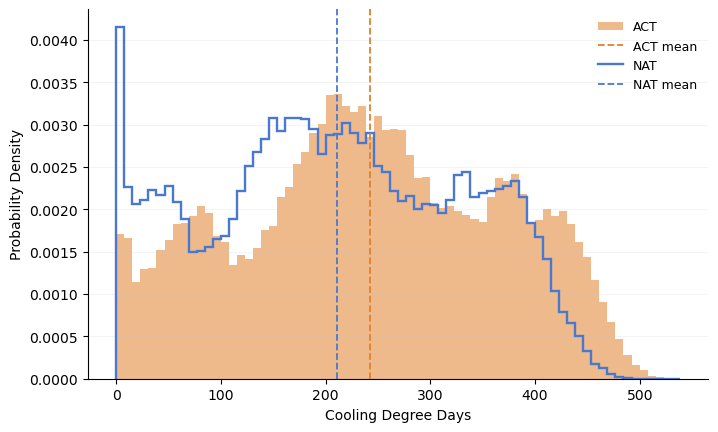

  attributable shift: +31.78 CDD (+15.1% of NAT mean)
  distribution overlap: 86.5%
  state-months at exactly zero: NAT 0.1% -> ALL 0.0% (-0.1 pp)
    (a count of months that change category, immune to the aggregation choice)
  overlap under other bin rules:
    fd        70 bins  overlap  86.5%
    sturges   18 bins  overlap  87.0%
    auto      70 bins  overlap  86.5%
    20        20 bins  overlap  87.1%
    40        40 bins  overlap  86.5%
    80        80 bins  overlap  86.5%
  spread (sd): total NAT 120.0 / ALL 124.1 | between-state NAT 34.4 / ALL 37.4
    most of the pooled width is cross-sectional, not ensemble spread

=== B. bias-corrected ensemble vs observed ===
  observed: 144 state-months | 12 states | months [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  states in ensemble only (1): ['telangana']
  comparing 108 state-months (12 states x 9 months)
          

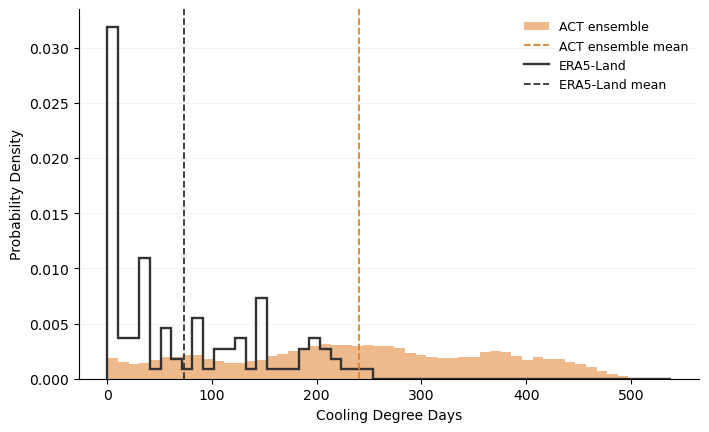

  distribution overlap: 38.1%
  mean offset (ALL - observed): +166.52 CDD (+226.4% of observed)
  spread: observed sd 75.1 vs ALL sd 126.0
  state-months at exactly zero: observed 13.0% vs ALL 0.0%
    -> the ensemble disagrees with the record about how often a state stays below base; a bias-correction diagnostic in itself
  overlap under other bin rules:
    fd        53 bins  overlap  38.1%
    sturges   17 bins  overlap  44.0%
    auto      53 bins  overlap  38.1%
    20        20 bins  overlap  43.7%
    40        40 bins  overlap  41.1%
    80        80 bins  overlap  37.3%

  paired residuals (ensemble mean - observed), 108 state-months:
    mean +166.52   median +186.96   sd 61.07   MAE 166.52
    correlation with observed: 0.915
    largest offsets:
      gujarat                month 10  observed    32.6  ALL   268.8   +236.2
      delhi                  month  5  observed   203.0  ALL   438.6   +235.6
      chhattisgarh           month  5  observed   213.8  ALL   449.1   +235.

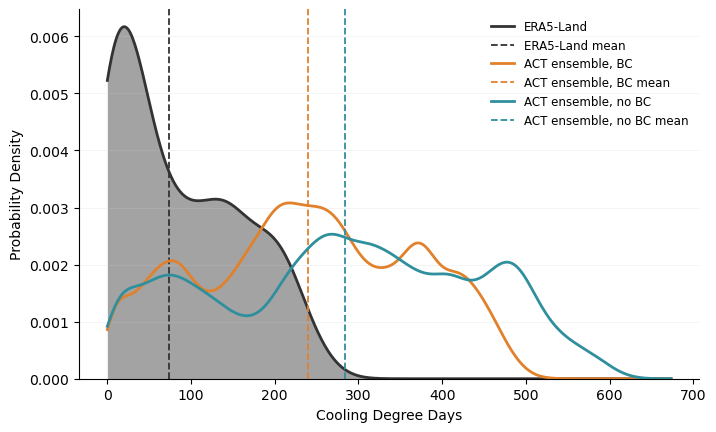

  overlap with observed: ACT ensemble, BC 47.3%, ACT ensemble, no BC 38.8%  (KDE); 38.1% for the corrected ensemble in figure B (histogram)
    the KDE reads higher because smoothing fills the gaps between sparse
    observed values -- quote the histogram figure, use the KDE as the visual

  mean CDD: raw 284.29 -> corrected 240.07 | observed 73.55
  mean offset vs observed: raw +210.73 -> corrected +166.52 CDD
  histogram overlap with observed: raw 34.3% -> corrected 38.1%
  sd: raw 155.8 -> corrected 126.0 | observed 75.1
  at zero: raw 0.0% -> corrected 0.0% | observed 13.0%

NOTE: 2022 falls inside the bias-correction reference period, so figure B is an internal-consistency check rather than out-of-sample validation.


In [15]:
# =============================================================================
# CDD distribution figures, 2022 state ensemble -- histograms, no smoothing
# =============================================================================
# Three figures:
#
#   A. ACT (ALL) vs NAT          -- the attribution signal: how far anthropogenic
#                                   forcing shifted the CDD distribution
#   B. Observed ERA5 vs ACT      -- the bias-correction check: does the factual
#                                   ensemble sit on top of the observed record
#   C. Observed ERA5 vs ACT      -- gaussian KDE, and now with the RAW
#      vs raw ACT                   (non-bias-corrected) ACT ensemble as a third
#                                   series, so the figure shows what the
#                                   correction actually did: raw -> corrected ->
#                                   observed, all on the same state-months.
#
# All use the SAME unit of observation (one pooled state-month) and the same
# styling, so they can be read side by side.
#
# WHY HISTOGRAMS. A kernel density estimate spreads every observation into a
# bump, and monthly CDD is bounded below at zero with a genuine point mass there
# -- whole state-months that never rise above the base temperature. An
# unreflected KDE then places several percent of its mass at impossible negative
# CDD; reflecting about zero fixes that but doubles the density exactly at the
# bound, producing a spike whose height depends on the bandwidth rather than the
# data. A histogram assigns each observation to exactly one bin and never puts
# mass anywhere else, so neither artefact can occur. The only free choice is the
# bin width, and its influence is reported at the end.
#
# THE POINT MASS AT ZERO is reported in the console output (P(CDD = 0) per
# series). It is no longer written into the legend labels -- see label_zeros.
#
# AGGREGATION: pooled -- every state-month (x member, for the ensemble) is its
# own draw. Averaging across states first would destroy the zero pile-up
# entirely, since the average of ~36 states is zero only if every state is below
# base at once. The cost is that pooled spread is dominated by cross-sectional
# variation between hot and cool states, not by ensemble spread; the script
# prints that decomposition so the overlap statistic is not over-read.
# =============================================================================

import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---------------- config ----------------
ROOT = ""
ENS_CSV = f"{ROOT}data/attribution_runs/all_state_cdd.csv"
NOBC_CSV = f"{ROOT}data/attribution_runs/all_state_cdd_nobc.csv"   # raw, no BC
OBS_CSV = f"{ROOT}data/prep_panel/electricity_panel_with_cdd.csv"     # <-- point at your file
FIGDIR = f"{ROOT}figures/outage_models"

YEAR = 2022
MONTHS = None       # e.g. [3, 4, 5]; None = every month present in both legs

# Study area, matching study_area_states in the R panel script. Set to None for
# every state in the files. Matching is on the normalised key below, so either
# "NCT of Delhi" or "Delhi" works, and either spelling of Odisha/Orissa.
STATES = [
    "Punjab", "Haryana", "Rajasthan", "NCT of Delhi", "Uttar Pradesh", "Odisha",
    "Madhya Pradesh", "Gujarat", "Chhattisgarh", "Telangana", "Jharkhand",
    "Uttarakhand", "Bihar",
]

ALL_LABEL, NAT_LABEL = "ALL", "NAT"
OBS_CDD_COL = "cdd"    # observed ERA5 monthly state CDD in the electricity panel

# "pooled"  -> every member value is a draw (ensemble side of figure B)
# "memmean" -> ensemble collapsed to its mean per state-month
ENSEMBLE_AS = "pooled"

BINS = "fd"            # "fd", "sturges", "auto", or an integer
KDE_BW_MULT = 1.0      # figure C only: bandwidth multiplier, <1 = less smooth
MEAN_IN_LEGEND = True  # add the dashed mean lines to the legend, with their values
COL_ALL, COL_NAT, COL_OBS = "#E1812C", "#4878CF", "#333333"
COL_NOBC = "#2F8F9D"   # raw ensemble: its own hue, distinct from ALL/NAT
COL_GRID = "#cccccc"

os.makedirs(FIGDIR, exist_ok=True)

# ---------------- state-name normalisation ----------------
# The ensemble carries GADM names ("Andhra Pradesh", "NCT of Delhi"); the
# electricity panel carries underscore names ("Andhra_Pradesh").
ALIASES = {
    "orissa": "odisha",
    "uttaranchal": "uttarakhand",
    "nct of delhi": "delhi",
    "delhi nct": "delhi",
    "chattisgarh": "chhattisgarh",
    "pondicherry": "puducherry",
    "andaman and nicobar islands": "andaman and nicobar",
    "jammu kashmir": "jammu and kashmir",
    "tamilnadu": "tamil nadu",
}


def norm_state(s):
    k = re.sub(r"\s+", " ", re.sub(r"[_\-.]", " ", str(s)).strip().lower())
    return ALIASES.get(k, k)


def describe(lab, v):
    print(f"  {lab[:30]:>30}: n={v.size:>7,}  mean={v.mean():7.2f}  "
          f"sd={v.std(ddof=1):6.2f}  median={np.median(v):6.1f}  "
          f"min={v.min():5.1f}  max={v.max():6.1f}  at zero={100*(v<=0).mean():4.1f}%")


def shared_edges(values, bins=BINS):
    """Bin edges over the pooled sample, with the first edge pinned to zero when
    the data touches the bound so no bin straddles it."""
    pooled = np.concatenate(values)
    edges = np.histogram_bin_edges(pooled, bins=bins)
    if pooled.min() >= 0 and edges[0] < 0:
        edges = np.linspace(0.0, edges[-1], len(edges))
    return edges


def overlap_of(v1, v2, edges):
    """Overlapping coefficient on shared bins: area under the pointwise minimum.
    1 = indistinguishable, 0 = disjoint."""
    w = float(np.diff(edges).mean())
    h1 = np.histogram(v1, bins=edges, density=True)[0]
    h2 = np.histogram(v2, bins=edges, density=True)[0]
    return float(np.minimum(h1, h2).sum() * w)


def label_zeros(base, v):
    """Zero share is reported in the console only; the legend stays clean."""
    return base


def mean_handle(lab, v, col):
    """Proxy artist so the dashed mean line gets a legend entry of its own.
    axvline() would be picked up automatically if it were given a label, but
    building the handles explicitly lets the legend pair each series with its
    own mean instead of listing all the series then all the means.

    `v` is unused now that the value is not printed in the label; it is kept in
    the signature so the call sites read symmetrically with the series handles.
    The means themselves are still in the console output."""
    return Line2D([0], [0], color=col, linestyle="--", linewidth=1.3,
                  label=f"{lab} mean")


def plot_pair(outline, fill, title, xlabel, fname, edges):
    """One figure: `outline` drawn as a step behind `fill`. Each argument is
    (label, values, colour)."""
    lab_o, v_o, col_o = outline
    lab_f, v_f, col_f = fill

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.hist(v_f, bins=edges, density=True, color=col_f, alpha=0.55,
            label=label_zeros(lab_f, v_f))
    ax.hist(v_o, bins=edges, density=True, histtype="step", color=col_o,
            linewidth=1.7, label=label_zeros(lab_o, v_o))
    ax.axvline(v_o.mean(), color=col_o, linestyle="--", linewidth=1.3)
    ax.axvline(v_f.mean(), color=col_f, linestyle="--", linewidth=1.3)

    # explicit handles: filled series as a patch, step series as a line, each
    # followed by its own dashed mean
    handles = [Patch(facecolor=col_f, alpha=0.55, label=label_zeros(lab_f, v_f)),
               Line2D([0], [0], color=col_o, linewidth=1.7,
                      label=label_zeros(lab_o, v_o))]
    if MEAN_IN_LEGEND:
        handles = [handles[0], mean_handle(lab_f, v_f, col_f),
                   handles[1], mean_handle(lab_o, v_o, col_o)]

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability Density")
    ax.legend(handles=handles, frameon=False, fontsize=9, loc="upper right")
    ax.grid(alpha=0.25, color=COL_GRID, linewidth=0.6, axis="y")
    ax.set_ylim(bottom=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    stem = f"{FIGDIR}/{fname}"
    plt.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"  saved {stem}.png / .pdf")
    plt.show()


def bin_sensitivity(v1, v2, label=""):
    """The bin width is the only arbitrary choice; show the headline numbers do
    not hang on it. Means and the shift are computed from raw values and are
    bin-independent -- only the overlap moves."""
    print(f"  overlap under other bin rules{label}:")
    for rule in ("fd", "sturges", "auto", 20, 40, 80):
        e = shared_edges([v1, v2], bins=rule)
        print(f"    {str(rule):8s} {len(e)-1:3d} bins  overlap "
              f"{100 * overlap_of(v1, v2, e):5.1f}%")


# ---------------- gaussian KDE (figure C only) ----------------
# Figures A and B are histograms because monthly CDD is bounded below at zero
# with a genuine point mass there, and a KDE handles that badly: unreflected it
# puts several percent of its mass at impossible negative CDD, and reflected it
# doubles the density exactly at the bound. Figure C uses a KDE anyway, because
# the observed sample has only one value per state-month and a shared-bin
# histogram makes it look ragged next to a 500-member ensemble -- but it avoids
# both artefacts by fitting the curve to POSITIVE values only, then truncating
# and renormalising so curve + point mass = 1.
def silverman(v):
    """Robust plug-in bandwidth: 0.9 * min(sd, IQR/1.349) * n^(-1/5)."""
    v = np.asarray(v, float)
    if v.size < 2:
        return 1.0
    sd = v.std(ddof=1)
    iqr = float(np.subtract(*np.percentile(v, [75, 25])))
    spread = min(sd, iqr / 1.349) if iqr > 0 else sd
    return 0.9 * (spread if spread > 0 else 1.0) * v.size ** (-1 / 5)


def gauss_kde(v, x, h):
    """f(x) = (1/nh) * sum_i phi((x - x_i)/h). The Gaussian IS the kernel."""
    u = (np.asarray(x, float)[:, None] - np.asarray(v, float)[None, :]) / h
    return np.exp(-0.5 * u ** 2).mean(axis=1) / (h * np.sqrt(2 * np.pi))


def kde_with_zero_mass(v, grid, bw_mult=1.0):
    """Returns (density, p_zero, bandwidth, leaked).

    Fitted to values above zero, then TRUNCATED AND RENORMALISED: the kernels
    sitting near the bound still spill below zero (and past the top of the
    grid), so the raw curve integrates to less than (1 - p_zero) over the
    plotted range. Dividing by the mass that actually lands on the grid puts it
    back, so curve + point mass = 1 exactly.

    This is the boundary correction to prefer over reflection here. Reflection
    folds the spilled mass back onto the bound itself, doubling the density at
    x = 0 and creating a spike whose height depends on the bandwidth.
    Renormalising spreads it proportionally over the whole positive range, which
    changes the level slightly and the shape not at all. `leaked` reports how
    much had to be redistributed -- if it is large, the bandwidth is too wide
    for how close the data sits to zero, and the histogram is the better figure.
    """
    v = np.asarray(v, float)
    p0 = float((v <= 0).mean())
    pos = v[v > 0]
    if pos.size < 2:
        return np.zeros_like(grid), p0, float("nan"), 0.0
    h = silverman(pos) * bw_mult
    d = gauss_kde(pos, grid, h)
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    on_grid = float(trapz(d, grid))
    leaked = max(0.0, 1.0 - on_grid)
    if on_grid > 0:
        d = d / on_grid * (1.0 - p0)
    return d, p0, h, leaked


def plot_kde(series, xlabel, fname, bw_mult=1.0):
    """N series as gaussian KDEs on one axes.

    `series` is a list of (label, values, colour, filled). The first entry with
    filled=True is drawn as a shaded area; the rest are lines on top, so the
    reference distribution can sit behind the comparisons. Returns
    {label: overlap-with-the-first-series}.
    """
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    top = max(float(np.max(v)) for _, v, _, _ in series) * 1.05
    grid = np.linspace(0.0, top, 512)

    fits = {}
    for lab, v, col, filled in series:
        d, p0, h, leak = kde_with_zero_mass(v, grid, bw_mult)
        fits[lab] = d
        print(f"  {lab[:28]:>28}: h={h:.1f}  P0={100*p0:.1f}%  "
              f"spilled past the bound and redistributed={100*leak:.1f}%  "
              f"curve+P0={trapz(d, grid) + p0:.4f}")
        if leak > 0.10:
            print("    WARNING: more than 10% of the kernel mass fell outside "
                  "the valid range; the bandwidth is wide relative to how close "
                  "the data sits to zero -- prefer the histogram (figure B)")

    fig, ax = plt.subplots(figsize=(8, 4.8))
    for lab, v, col, filled in series:
        if filled:
            ax.fill_between(grid, fits[lab], color=col, alpha=0.45, linewidth=0)
        ax.plot(grid, fits[lab], color=col, linewidth=2)
        ax.axvline(float(np.mean(v)), color=col, linestyle="--", linewidth=1.3)

    handles = []
    for lab, v, col, filled in series:
        handles.append(Line2D([0], [0], color=col, linewidth=2,
                              label=label_zeros(lab, v)))
        if MEAN_IN_LEGEND:
            handles.append(mean_handle(lab, v, col))

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability Density")
    ax.legend(handles=handles, frameon=False, fontsize=8.5, loc="upper right")
    ax.grid(alpha=0.25, color=COL_GRID, linewidth=0.6, axis="y")
    ax.set_ylim(bottom=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    stem = f"{FIGDIR}/{fname}"
    plt.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"  saved {stem}.png / .pdf")
    plt.show()

    ref_lab, ref_v = series[0][0], series[0][1]
    p0_ref = float((np.asarray(ref_v) <= 0).mean())
    out = {}
    for lab, v, _, _ in series[1:]:
        p0 = float((np.asarray(v) <= 0).mean())
        out[lab] = float(trapz(np.minimum(fits[ref_lab], fits[lab]), grid)) \
            + min(p0_ref, p0)
    return out


# ---------------- loading the ensembles ----------------
def load_ensemble(path, tag):
    """Year / month / leg / study-area filtering, shared by the corrected and
    raw ensembles so a difference between them can never be a filtering
    difference."""
    e = pd.read_csv(path)
    need = {"year", "month", "state", "cdd", "leg", "member"}
    if need - set(e.columns):
        raise SystemExit(f"{path} is missing {sorted(need - set(e.columns))}")
    e = e[e["year"] == YEAR].dropna(subset=["cdd"])
    if MONTHS is not None:
        e = e[e["month"].isin(MONTHS)]
    e = e[e["leg"].isin([ALL_LABEL, NAT_LABEL])]
    if e.empty:
        raise SystemExit(f"no {tag} ensemble rows for {YEAR} in {path}")
    e["_key"] = e["state"].map(norm_state)

    if STATES is not None:
        want = {norm_state(x) for x in STATES}
        absent = sorted(want - set(e["_key"]))
        e = e[e["_key"].isin(want)]
        if absent:
            print(f"WARNING: study-area states absent from the {tag} ensemble: {absent}")
        if e.empty:
            raise SystemExit(f"no {tag} ensemble rows left after the study-area filter")

    # keep only months present in BOTH legs, so the two describe the same period
    common = set.intersection(*(set(g["month"]) for _, g in e.groupby("leg")))
    dropped = sorted(set(e["month"]) - common)
    if dropped:
        print(f"  [{tag}] dropping months not in both legs: {dropped}")
    e = e[e["month"].isin(common)]

    print(f"{tag} ensemble: {len(e):,} rows | {e['_key'].nunique()} states | "
          f"months {sorted(e['month'].unique())} | {e['member'].nunique()} members")
    return e


ens = load_ensemble(ENS_CSV, "bias-corrected")

# =============================================================================
# FIGURE A -- ACT (ALL) vs NAT
# =============================================================================
print("\n=== A. factual vs natural-only forcing ===")
nat_v = ens.loc[ens["leg"] == NAT_LABEL, "cdd"].to_numpy()
all_v = ens.loc[ens["leg"] == ALL_LABEL, "cdd"].to_numpy()
describe("NAT", nat_v)
describe("ACT", all_v)

edges_a = shared_edges([nat_v, all_v])
print(f"  bins: {len(edges_a)-1} of width {np.diff(edges_a).mean():.1f}, "
      f"range {edges_a[0]:.0f} to {edges_a[-1]:.0f}")
plot_pair(("NAT", nat_v, COL_NAT),
          ("ACT", all_v, COL_ALL),
          title=None,
          xlabel="Cooling Degree Days",
          fname=f"cdd_act_vs_nat_{YEAR}", edges=edges_a)

shift = all_v.mean() - nat_v.mean()
p0_nat, p0_all = float((nat_v <= 0).mean()), float((all_v <= 0).mean())
print(f"  attributable shift: {shift:+.2f} CDD ({100*shift/nat_v.mean():+.1f}% of NAT mean)")
print(f"  distribution overlap: {100 * overlap_of(nat_v, all_v, edges_a):.1f}%")
print(f"  state-months at exactly zero: NAT {100*p0_nat:.1f}% -> ALL {100*p0_all:.1f}% "
      f"({100*(p0_all - p0_nat):+.1f} pp)")
print("    (a count of months that change category, immune to the aggregation choice)")
bin_sensitivity(nat_v, all_v)

# pooled spread is dominated by between-state variation, so the overlap above is
# descriptive only -- the mean shift and the zero share are the result
between = ens.groupby(["leg", "_key"])["cdd"].mean().groupby("leg").std(ddof=1)
print(f"  spread (sd): total NAT {nat_v.std(ddof=1):.1f} / ALL {all_v.std(ddof=1):.1f}"
      f" | between-state NAT {between[NAT_LABEL]:.1f} / ALL {between[ALL_LABEL]:.1f}")
print("    most of the pooled width is cross-sectional, not ensemble spread")

# =============================================================================
# FIGURE B -- observed ERA5 vs ACT (ALL)
# =============================================================================
print("\n=== B. bias-corrected ensemble vs observed ===")
obs = pd.read_excel(OBS_CSV) if OBS_CSV.endswith((".xlsx", ".xls")) else pd.read_csv(OBS_CSV)
obs.columns = [c.strip() for c in obs.columns]
if OBS_CDD_COL not in obs.columns:
    raise SystemExit(f"{OBS_CSV} has no column {OBS_CDD_COL!r}. Columns: {list(obs.columns)}")
name_col = "state_name" if "state_name" in obs.columns else "state"
obs = obs[obs["year"] == YEAR].dropna(subset=[OBS_CDD_COL])
if obs.empty:
    raise SystemExit(f"no {YEAR} rows in {OBS_CSV}")
obs["_key"] = obs[name_col].map(norm_state)
if STATES is not None:
    want = {norm_state(x) for x in STATES}
    missing = sorted(want - set(obs["_key"]))
    if missing:
        print(f"  WARNING: study-area states absent from the observed panel: {missing}")
    obs = obs[obs["_key"].isin(want)]
    if obs.empty:
        raise SystemExit("no observed rows left after the study-area filter")
obs = (obs[["_key", "month", OBS_CDD_COL]].rename(columns={OBS_CDD_COL: "cdd"})
       .groupby(["_key", "month"], as_index=False)["cdd"].mean())
print(f"  observed: {len(obs):,} state-months | {obs['_key'].nunique()} states | "
      f"months {sorted(obs['month'].unique())}")

# align on the SAME state-months, or any offset is a sampling artefact
ens_all = ens[ens["leg"] == ALL_LABEL]
ens_cells = set(map(tuple, ens_all[["_key", "month"]].drop_duplicates().to_numpy()))
obs_cells = set(map(tuple, obs[["_key", "month"]].to_numpy()))
both = ens_cells & obs_cells
if not both:
    raise SystemExit("no overlapping state-months -- check the name normalisation")
only_e = sorted({k for k, _ in ens_cells} - {k for k, _ in obs_cells})
only_o = sorted({k for k, _ in obs_cells} - {k for k, _ in ens_cells})
if only_e:
    print(f"  states in ensemble only ({len(only_e)}): {only_e[:8]}")
if only_o:
    print(f"  states in observed only ({len(only_o)}): {only_o[:8]}")

sel = pd.DataFrame(sorted(both), columns=["_key", "month"])
ens_m = ens_all.merge(sel, on=["_key", "month"])
obs_m = obs.merge(sel, on=["_key", "month"])
print(f"  comparing {len(sel)} state-months "
      f"({sel['_key'].nunique()} states x {sel['month'].nunique()} months)")


def as_series(frame, name):
    """Apply ENSEMBLE_AS to an aligned ensemble frame."""
    if ENSEMBLE_AS == "pooled":
        return frame["cdd"].to_numpy(), name
    if ENSEMBLE_AS == "memmean":
        return frame.groupby(["_key", "month"])["cdd"].mean().to_numpy(), f"{name} mean"
    raise SystemExit('ENSEMBLE_AS must be "pooled" or "memmean"')


obs_v = obs_m["cdd"].to_numpy()
ensb_v, ens_name = as_series(ens_m, "ACT ensemble")
describe("ERA5-Land", obs_v)
describe(ens_name, ensb_v)

edges_b = shared_edges([obs_v, ensb_v])
print(f"  bins: {len(edges_b)-1} of width {np.diff(edges_b).mean():.1f}, "
      f"range {edges_b[0]:.0f} to {edges_b[-1]:.0f}")
plot_pair(("ERA5-Land", obs_v, COL_OBS),
          (ens_name, ensb_v, COL_ALL),
          title=None,
          xlabel="Cooling Degree Days",
          fname=f"cdd_obs_vs_all_{YEAR}", edges=edges_b)

print(f"  distribution overlap: {100 * overlap_of(obs_v, ensb_v, edges_b):.1f}%")
print(f"  mean offset (ALL - observed): {ensb_v.mean() - obs_v.mean():+.2f} CDD "
      f"({100*(ensb_v.mean() - obs_v.mean())/obs_v.mean():+.1f}% of observed)")
print(f"  spread: observed sd {obs_v.std(ddof=1):.1f} vs ALL sd {ensb_v.std(ddof=1):.1f}")
p0_o, p0_e = float((obs_v <= 0).mean()), float((ensb_v <= 0).mean())
print(f"  state-months at exactly zero: observed {100*p0_o:.1f}% vs ALL {100*p0_e:.1f}%")
if abs(p0_e - p0_o) > 0.02:
    print("    -> the ensemble disagrees with the record about how often a state "
          "stays below base; a bias-correction diagnostic in itself")
bin_sensitivity(obs_v, ensb_v)

# paired check on RAW values: aggregate agreement can hide offsetting errors
paired = (ens_m.groupby(["_key", "month"])["cdd"].mean().rename("ens").reset_index()
          .merge(obs_m.rename(columns={"cdd": "obs"}), on=["_key", "month"]))
paired["resid"] = paired["ens"] - paired["obs"]
paired = paired.rename(columns={"_key": "state_key"})   # leading _ breaks itertuples
print(f"\n  paired residuals (ensemble mean - observed), {len(paired)} state-months:")
print(f"    mean {paired['resid'].mean():+.2f}   median {paired['resid'].median():+.2f}   "
      f"sd {paired['resid'].std(ddof=1):.2f}   MAE {paired['resid'].abs().mean():.2f}")
print(f"    correlation with observed: {paired['ens'].corr(paired['obs']):.3f}")
worst = paired.reindex(paired["resid"].abs().sort_values(ascending=False).index).head(6)
print("    largest offsets:")
for r in worst.itertuples(index=False):
    print(f"      {r.state_key:<22} month {r.month:>2}  observed {r.obs:7.1f}  "
          f"ALL {r.ens:7.1f}  {r.resid:+7.1f}")

# =============================================================================
# FIGURE C -- observed vs bias-corrected ACT vs RAW ACT, gaussian KDEs
# =============================================================================
# Same alignment as figure B: the raw ensemble is cut to the identical
# state-months, so the gap between the two ACT curves is the bias correction and
# nothing else. Read the correction left to right: raw ensemble -> corrected
# ensemble -> observed record. If the correction is doing its job, the corrected
# curve sits on the observed one and the raw curve is the outlier.
#
# KDEs rather than histograms because the observed sample has one value per
# state-month and looks ragged beside a 500-member ensemble. Quote the numbers
# from B and from the console below, not the visual.
print("\n=== C. observed vs corrected vs raw ACT, gaussian kernels ===")
# figure C names the correction explicitly, since both ACT curves are present;
# figure B keeps the plain `ens_name`, where there is nothing to distinguish it from
bc_name = f"{ens_name}, BC"
series = [("ERA5-Land", obs_v, COL_OBS, True),
          (bc_name, ensb_v, COL_ALL, False)]

if os.path.exists(NOBC_CSV):
    ens_raw = load_ensemble(NOBC_CSV, "raw (no BC)")
    raw_all = ens_raw[ens_raw["leg"] == ALL_LABEL]
    raw_cells = set(map(tuple, raw_all[["_key", "month"]].drop_duplicates().to_numpy()))
    missing_cells = both - raw_cells
    if missing_cells:
        print(f"  NOTE: {len(missing_cells)} of the {len(both)} compared state-months "
              "are absent from the raw file; the raw curve covers fewer cells")
    raw_m = raw_all.merge(sel, on=["_key", "month"])
    raw_v, raw_name = as_series(raw_m, "ACT ensemble, no BC")
    describe(raw_name, raw_v)
    series.append((raw_name, raw_v, COL_NOBC, False))
else:
    raw_v = None
    print(f"  NOTE: {NOBC_CSV} not found -- drawing observed vs corrected only")

ov_kde = plot_kde(series, xlabel="Cooling Degree Days",
                  fname=f"cdd_obs_vs_all_{YEAR}_kde", bw_mult=KDE_BW_MULT)

ov_hist = overlap_of(obs_v, ensb_v, edges_b)
print(f"  overlap with observed: "
      + ", ".join(f"{k} {100*v:.1f}%" for k, v in ov_kde.items())
      + f"  (KDE); {100*ov_hist:.1f}% for the corrected ensemble in figure B "
        "(histogram)")
print("    the KDE reads higher because smoothing fills the gaps between sparse")
print("    observed values -- quote the histogram figure, use the KDE as the visual")

if raw_v is not None:
    # what the correction bought, in one line each
    edges_c = shared_edges([obs_v, raw_v])
    print(f"\n  mean CDD: raw {raw_v.mean():.2f} -> corrected {ensb_v.mean():.2f} "
          f"| observed {obs_v.mean():.2f}")
    print(f"  mean offset vs observed: raw {raw_v.mean() - obs_v.mean():+.2f} -> "
          f"corrected {ensb_v.mean() - obs_v.mean():+.2f} CDD")
    print(f"  histogram overlap with observed: raw "
          f"{100 * overlap_of(obs_v, raw_v, edges_c):.1f}% -> corrected "
          f"{100 * ov_hist:.1f}%")
    print(f"  sd: raw {raw_v.std(ddof=1):.1f} -> corrected {ensb_v.std(ddof=1):.1f} "
          f"| observed {obs_v.std(ddof=1):.1f}")
    print(f"  at zero: raw {100*(raw_v <= 0).mean():.1f}% -> corrected "
          f"{100*p0_e:.1f}% | observed {100*p0_o:.1f}%")

print(f"\nNOTE: {YEAR} falls inside the bias-correction reference period, so figure B "
      "is an internal-consistency check rather than out-of-sample validation.")

data/prayas_out/esmi_outage_cdd_panel.csv
  278,225 rows | columns: ['Location name', 'date', 'day', 'month', 'year', 'district', 'state', 'state_year', 'state_month', 'state_yearmonth', 'district_year', 'district_month', 'district_yearmonth', 'outage_minutes', 'observed_minutes', 'tmean_c', 'cdd_tmean', 'cdd_cellmean', 'dewpt_c', 'rh', 'cdd_swbgt', 'cdd_dewpt']
  NOTE: 4 CDD columns present ['cdd_tmean', 'cdd_cellmean', 'cdd_swbgt', 'cdd_dewpt']; using 'cdd_tmean'.
  These are different variants -- set the config value to choose.
  CDD: 'cdd_tmean' | outage: 'outage_minutes' | coverage: 'observed_minutes' | location: 'Location name'
  district key from state + district: 76 districts across 21 states
  dropping 8 non-study state(s): ['andhra pradesh', 'assam', 'chandigarh', 'goa', 'karnataka', 'maharashtra', 'tamil nadu', 'west bengal']
  study area: 43 districts across 13 states

--- location coverage filter (>= 365 observed days) ---
locations: 148 kept, 172 dropped, of 320

dropped 

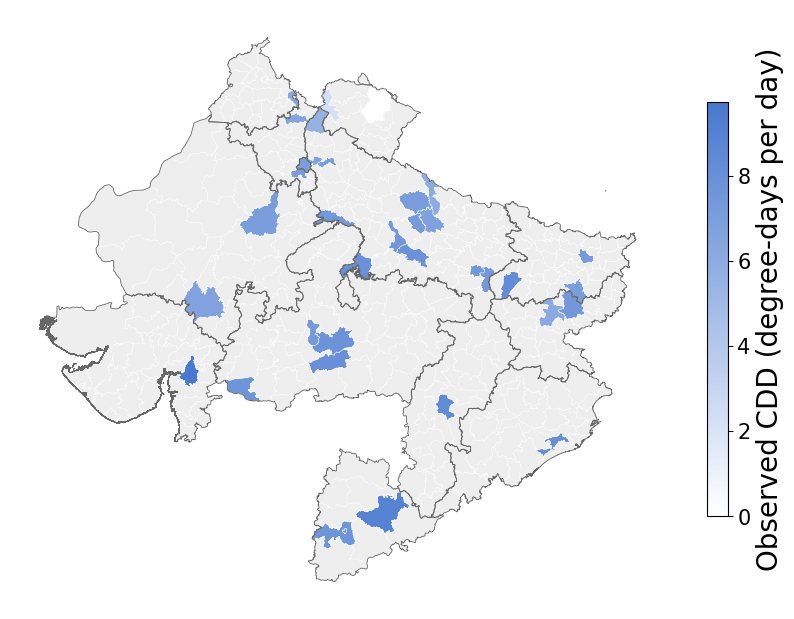

saved figures/outage_models/observed_outage_district.png / .pdf


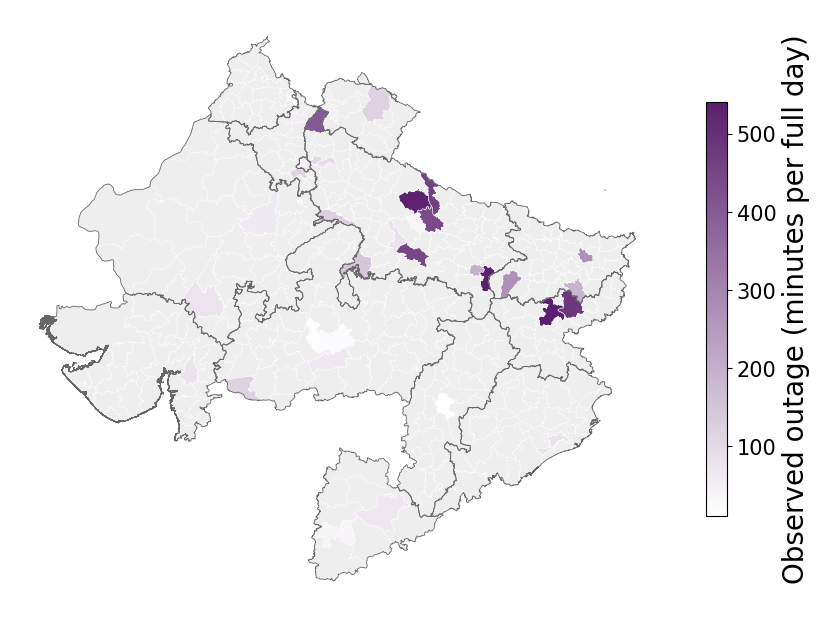

saved figures/outage_models/observed_cdd_outage_district_table.csv (36 mapped districts)

months weighted equally | outage mode: coverage_adjusted
        state   district      cdd     outage  outage_adj  outage_per_day  n_locations  obs_days  obs_year_months
    Jharkhand Hazaribagh 6.212054 541.169627  541.169627      541.169627          1.0     415.0             14.0
Uttar Pradesh  Chandauli 7.395062 539.132848  539.132848      534.697738          3.0     926.0             33.0
Uttar Pradesh    Sitapur 7.110030 533.709047  533.709047      520.938172         16.0    1097.0             41.0
    Jharkhand    Giridih 7.493216 483.625575  483.625575      464.872788          4.0     508.0             18.0
Uttar Pradesh   Bahraich 6.040793 462.639936  462.639936      460.201723          6.0     413.0             14.0
Uttar Pradesh   Fatehpur 7.841267 445.827944  445.827944      443.836070          3.0     729.0             25.0
Uttar Pradesh  Barabanki 6.743360 437.924741  437.924741      

In [16]:
# =============================================================================
# Observed CDD and observed outage by district -- two matched choropleths
# =============================================================================
# The observed counterpart to figure 1c of the district attribution script: same
# geography, same styling, but what was actually recorded over the ESMI outage
# panel rather than an ensemble-derived attributable difference.
#
#   1. mean CDD per district-day          -- blue
#   2. mean outage minutes per district-day -- violet
#
# Identical layout, different hue, so the pair reads as two measurements of the
# same districts rather than as one quantity in two states.
#
# WHAT IS AVERAGED. One value per district. The ESMI panel is UNBALANCED --
# districts enter and leave the record, so two districts can be averaging over
# different seasons. A plain mean over rows would then compare a district
# observed mostly in May against one observed mostly in December and call the
# difference climate.
#
#   BALANCE = True  (default) -- aggregate within each district x year-month
#                    first, then average across year-months. Removes the
#                    weighting effect of uneven day counts within a month.
#   COMMON_CELLS_ONLY = True -- stricter: keep only the year-months that EVERY
#                    mapped district observes, so all districts average over an
#                    identical calendar. Costs districts; the script reports how
#                    many before doing it.
#
# OUTAGE AND COVERAGE. A district-day is not always a full 1440 minutes of
# monitoring, and a day with 3 hours of coverage cannot record 200 minutes of
# outage. Averaging raw outage minutes across days of unequal coverage therefore
# understates the districts that are monitored patchily.
#
#   OUTAGE_MODE = "coverage_adjusted" (default when a coverage column exists)
#       1440 * sum(outage) / sum(observed) -- outage minutes per FULL day,
#       a rate, comparable across districts with different coverage.
#   OUTAGE_MODE = "per_observed_day"
#       plain mean of daily outage minutes. Simpler, and what the phrase "mean
#       outage minutes" usually means, but confounded with coverage.
# Both are computed and their correlation printed, so the choice is visible.
# =============================================================================

# Import matplotlib's PDF backend before geopandas/fiona/pyproj get a chance to
# load. Saving to .pdf for the first time after those geospatial libraries are
# imported trips an assertion inside the `coverage` package.
import matplotlib.backends.backend_pdf  # noqa: F401
import os
import re
import difflib

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import MultiPolygon
from matplotlib.colors import LinearSegmentedColormap

# ---------------- config ----------------
ROOT = ""
PANEL_CSV = f"{ROOT}data/prayas_out/esmi_outage_cdd_panel.csv"
GADM_L2 = f"{ROOT}data/prep_panel/prep_cdd/gadm/gadm41_IND_2.shp"
GADM_L1 = f"{ROOT}data/prep_panel/prep_cdd/gadm/gadm41_IND_1.shp"
FIGDIR = f"{ROOT}figures/outage_models"

# None = auto-detect from the candidates below (the panel carries two CDD
# variants: CDD of the district-mean temperature, and the area-weighted mean of
# per-cell CDD). Name it explicitly once you know which one the figure should
# show -- they are not interchangeable.
CDD_COL = None
CDD_CANDIDATES = ["cdd", "cdd_district", "cdd_mean_temp", "cdd_of_mean",
                  "cdd_cellwise", "cdd_cell_mean", "cdd_area_weighted",
                  "cdd_18", "cdd_18_3", "cdd_183"]

OUTAGE_COL = None
OUTAGE_CANDIDATES = ["outage_minutes", "outage_mins", "minutes_outage",
                      "outage", "zero_minutes", "zero_v_minutes"]
COVERAGE_COL = None
COVERAGE_CANDIDATES = ["observed_minutes", "obs_minutes", "coverage_minutes",
                        "minutes_observed"]
# ESMI monitoring location, if the panel is still at location x day grain. None
# = auto-detect; if nothing matches, the location counts are skipped with a note.
LOCATION_COL = None
LOCATION_CANDIDATES = ["Location name", "location_name", "location", "Location",
                        "loc_name", "site", "site_name"]

FULL_DAY_MINUTES = 1440
OUTAGE_MODE = "coverage_adjusted"    # or "per_observed_day"

# Study states. The ESMI panel reaches beyond the study area, so restrict it
# here rather than mapping whatever happens to be monitored. None = every state
# present in the panel.
STATES = ["Punjab", "Haryana", "Rajasthan", "Delhi", "Uttar Pradesh", "Odisha",
          "Madhya Pradesh", "Gujarat", "Chhattisgarh", "Telangana", "Jharkhand",
          "Uttarakhand", "Bihar"]

# Panel spelling -> canonical, applied to the state name before matching STATES.
STATE_ALIASES = {
    "orissa": "odisha",
    "uttaranchal": "uttarakhand",
    "nct of delhi": "delhi",
    "delhi nct": "delhi",
    "chattisgarh": "chhattisgarh",
    "telengana": "telangana",
    "pondicherry": "puducherry",
    "jammu kashmir": "jammu and kashmir",
    "tamilnadu": "tamil nadu",
}

# Drop LOCATIONS observed on fewer than this many distinct days (0 = keep all).
# Location level, not district level: a district disappears only if EVERY one of
# its locations falls short, and a district with a mix keeps the long-running
# ones. Mirrors the filter in the R fitting script, so the two describe the same
# sample. FULL_DAY_ONLY counts only days with a complete 1440-minute window,
# which is what the R script does after its own full-day filter.
MIN_LOCATION_DAYS = 365
FULL_DAY_ONLY = False

BALANCE = True              # aggregate within district-month before across months
COMMON_CELLS_ONLY = False   # keep only year-months observed by every district
STRICT_JOIN = True          # stop, rather than grey out, on an unmatched district

CMAP_CDD = LinearSegmentedColormap.from_list("cdd_seq", ["#FFFFFF", "#4878CF"])       # climate magnitude: white -> blue
CMAP_OUTAGE = LinearSegmentedColormap.from_list("outage_seq", ["#FFFFFF", "#5A1F6E"])  # outage magnitude: white -> violet, a hue used by neither ACT nor NAT
COL_MISSING = "#eeeeee"
LABEL_STATES = False        # light state names over the map, for orientation

# ---- choropleth font sizes (all adjustable here) ----
FS_LEGEND_LABEL = 20   # colorbar label, e.g. "Observed CDD (degree-days per day)"
FS_LEGEND_TICK = 15    # colorbar tick labels
FS_STATE_LABEL = 11    # state-name annotation drawn when LABEL_STATES = True

MONTH_LETTER = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J",
                7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}

# Panel spelling -> GADM spelling, for districts the crosswalk misses. Keys are
# matched after normalisation, on the "state||district" key.
NAME_FIXES = {}

os.makedirs(FIGDIR, exist_ok=True)


def norm(s):
    return re.sub(r"\s+", " ", re.sub(r"[_\-.]", " ", str(s)).strip().lower())


def norm_state(s):
    k = norm(s)
    return STATE_ALIASES.get(k, k)


def pick_column(explicit, candidates, columns, what, prefix=None, exclude=()):
    """Config value if set, else the first candidate present, else anything
    starting with `prefix`. Returns None when nothing matches."""
    if explicit is not None:
        if explicit not in columns:
            raise SystemExit(f"{explicit!r} not in {PANEL_CSV}; columns: {list(columns)}")
        return explicit
    found = [c for c in candidates if c in columns]
    if not found and prefix:
        found = [c for c in columns
                 if c.lower().startswith(prefix) and not any(x in c.lower() for x in exclude)]
    if not found:
        return None
    if len(found) > 1:
        print(f"  NOTE: {len(found)} {what} columns present {found}; using {found[0]!r}."
              "\n  These are different variants -- set the config value to choose.")
    return found[0]


def label_point(geom):
    """Largest sub-polygon's centroid, so a label never lands between the parts
    of a disjoint district."""
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)
    return geom.centroid


# ---------------- load ----------------
df = pd.read_csv(PANEL_CSV)
df.columns = [c.strip() for c in df.columns]
print(f"{PANEL_CSV}\n  {len(df):,} rows | columns: {list(df.columns)}")

CDD_COL = pick_column(CDD_COL, CDD_CANDIDATES, df.columns, "CDD", prefix="cdd")
if CDD_COL is None:
    raise SystemExit(f"no CDD-looking column; columns: {list(df.columns)}")
# "observed_minutes" must never be mistaken for an outage column
OUTAGE_COL = pick_column(OUTAGE_COL, OUTAGE_CANDIDATES, df.columns, "outage",
                          prefix="outage", exclude=("observed", "coverage"))
if OUTAGE_COL is None:
    raise SystemExit(f"no outage-looking column; columns: {list(df.columns)}")
COVERAGE_COL = pick_column(COVERAGE_COL, COVERAGE_CANDIDATES, df.columns, "coverage")
LOCATION_COL = pick_column(LOCATION_COL, LOCATION_CANDIDATES, df.columns, "location")
print(f"  CDD: {CDD_COL!r} | outage: {OUTAGE_COL!r} | coverage: {COVERAGE_COL!r}"
      f" | location: {LOCATION_COL!r}")
if LOCATION_COL is None:
    print("  NOTE: no location column found -- the panel looks pre-aggregated to "
          "district-days, so per-district location counts are unavailable")

if COVERAGE_COL is None and OUTAGE_MODE == "coverage_adjusted":
    print("  NOTE: no coverage column found -- falling back to per_observed_day")
    OUTAGE_MODE = "per_observed_day"

# --- year / month ---
if not ("year" in df.columns and "month" in df.columns):
    date_col = next((c for c in ("date", "day", "obs_date", "datetime")
                      if c in df.columns), None)
    if date_col is None:
        raise SystemExit("need either year+month columns or a date column; "
                          f"columns: {list(df.columns)}")
    d = pd.to_datetime(df[date_col], errors="coerce")
    if d.isna().all():
        raise SystemExit(f"could not parse {date_col!r} as dates")
    df["year"], df["month"] = d.dt.year, d.dt.month

# --- district key ---
if "gadm_key" in df.columns:
    df["_key"] = df["gadm_key"].astype(str)
    key_source = "gadm_key column"
else:
    state_col = next((c for c in ("state", "NAME_1", "state_name") if c in df.columns), None)
    dist_col = next((c for c in ("district", "NAME_2", "district_name") if c in df.columns), None)
    if not (state_col and dist_col):
        raise SystemExit("no gadm_key, and no state/district columns to build one; "
                          f"columns: {list(df.columns)}")
    df["_key"] = df[state_col].astype(str) + "||" + df[dist_col].astype(str)
    key_source = f"{state_col} + {dist_col}"
df["_norm"] = df["_key"].map(lambda k: NAME_FIXES.get(norm(k), norm(k)))
df["_state"] = df["_norm"].str.split(r"\|\|").str[0].map(norm_state)
print(f"  district key from {key_source}: {df['_norm'].nunique()} districts "
      f"across {df['_state'].nunique()} states")

# --- study-area filter ---
if STATES is not None:
    want = {norm_state(s) for s in STATES}
    have = set(df["_state"])
    absent, dropped = sorted(want - have), sorted(have - want)
    if absent:
        print(f"  NOTE: study states with no ESMI district in the panel: {absent}")
    if dropped:
        print(f"  dropping {len(dropped)} non-study state(s): {dropped}")
    df = df[df["_state"].isin(want)]
    if df.empty:
        raise SystemExit("no rows left after the study-state filter -- check "
                          "STATES against the panel's spellings")
    print(f"  study area: {df['_norm'].nunique()} districts across "
          f"{df['_state'].nunique()} states")

df = df.dropna(subset=[CDD_COL, OUTAGE_COL]).copy()

# --- drop short-lived monitoring locations ---------------------------------
if MIN_LOCATION_DAYS:
    if LOCATION_COL is None or "date" not in df.columns:
        print(f"  NOTE: MIN_LOCATION_DAYS={MIN_LOCATION_DAYS} ignored -- needs both a "
              "location column and a date column")
    else:
        base = df
        if FULL_DAY_ONLY:
            if COVERAGE_COL is None:
                raise SystemExit("FULL_DAY_ONLY needs a coverage column")
            base = df[df[COVERAGE_COL] == FULL_DAY_MINUTES]
        ld = (base.groupby(["_norm", LOCATION_COL])
                  .agg(n_days=("date", "nunique"), n_rows=("date", "size"),
                       first_day=("date", "min"), last_day=("date", "max"))
                  .reset_index())
        keep_loc = ld[ld["n_days"] >= MIN_LOCATION_DAYS]
        drop_loc = ld[ld["n_days"] < MIN_LOCATION_DAYS].sort_values(
            ["_norm", "n_days"], ascending=[True, False])

        before = ld.groupby("_norm").size().rename("n_loc_before")
        after = keep_loc.groupby("_norm").size().rename("n_loc_after")
        change = (pd.concat([before, after], axis=1).fillna(0).astype(int)
                  .reset_index())
        change["state"] = change["_norm"].str.split(r"\|\|").str[0]
        change["district"] = change["_norm"].str.split(r"\|\|").str[1]
        change["n_loc_lost"] = change["n_loc_before"] - change["n_loc_after"]
        gone = change[change["n_loc_after"] == 0]
        thinned = change[(change["n_loc_after"] > 0) & (change["n_loc_lost"] > 0)]

        print(f"\n--- location coverage filter (>= {MIN_LOCATION_DAYS} observed days"
              + (", full days only" if FULL_DAY_ONLY else "") + ") ---")
        print(f"locations: {len(keep_loc)} kept, {len(drop_loc)} dropped, of {len(ld)}")
        if len(drop_loc):
            d = drop_loc.copy()
            d["state"] = d["_norm"].str.split(r"\|\|").str[0]
            d["district"] = d["_norm"].str.split(r"\|\|").str[1]
            print("\ndropped locations:")
            print(d[["state", "district", LOCATION_COL, "n_days", "n_rows",
                      "first_day", "last_day"]].to_string(index=False))
        if len(gone):
            print(f"\ndistricts lost entirely ({len(gone)}):")
            print(gone[["state", "district", "n_loc_before"]].to_string(index=False))
        else:
            print("\nno district lost entirely")
        if len(thinned):
            print(f"\ndistricts that keep some locations but lose others ({len(thinned)}):")
            print(thinned[["state", "district", "n_loc_before", "n_loc_after",
                            "n_loc_lost"]].to_string(index=False))

        if keep_loc.empty:
            raise SystemExit(f"no location reaches {MIN_LOCATION_DAYS} days -- "
                              "lower MIN_LOCATION_DAYS")
        n_before = len(df)
        # semi-join: keep every row belonging to a surviving location, including
        # its partial days -- the threshold selects LOCATIONS, not rows
        df = df.merge(keep_loc[["_norm", LOCATION_COL]],
                       on=["_norm", LOCATION_COL], how="inner")
        print(f"\nrows: {len(df):,} of {n_before:,} kept "
              f"({100 * len(df) / n_before:.1f}%) | "
              f"{df['_norm'].nunique()} districts remain")

df["_ym"] = df["year"].astype(int) * 100 + df["month"].astype(int)
yms = sorted(df["_ym"].unique())
print(f"  {len(df):,} district-days | {len(yms)} year-months "
      f"({yms[0]//100}-{yms[0]%100:02d} to {yms[-1]//100}-{yms[-1]%100:02d})")

# ---------------- coverage, before averaging anything ----------------
# "days" counts ROWS. At location x day grain that is location-days, so the
# distinct-date count is reported separately -- three locations reporting for
# 200 days is 200 days of observation, not 600.
cov_agg = {"rows": (OUTAGE_COL, "size"), "months": ("month", "nunique"),
           "yms": ("_ym", "nunique")}
if "date" in df.columns:
    cov_agg["days"] = ("date", "nunique")
if LOCATION_COL is not None:
    cov_agg["n_locations"] = (LOCATION_COL, "nunique")
cov = df.groupby("_norm").agg(**cov_agg)
if "days" not in cov.columns:
    cov["days"] = cov["rows"]          # already one row per district-day
cov = cov.sort_values("days")

print(f"\ncoverage: {cov['days'].min()}-{cov['days'].max()} district-days, "
      f"{cov['yms'].min()}-{cov['yms'].max()} year-months per district")
if cov["yms"].nunique() > 1:
    print("  the panel is unbalanced -- districts do not share a calendar; "
          "see BALANCE / COMMON_CELLS_ONLY in the header")

if LOCATION_COL is not None:
    loc = cov.reset_index()
    loc["state"] = loc["_norm"].str.split(r"\|\|").str[0]
    loc["district"] = loc["_norm"].str.split(r"\|\|").str[1]
    loc = loc.sort_values(["n_locations", "days"], ascending=[False, False])
    print(f"\nESMI monitoring locations per district "
          f"({int(loc['n_locations'].sum())} location-district pairs, "
          f"{df[LOCATION_COL].nunique()} distinct locations in total):")
    print(loc[["state", "district", "n_locations", "days", "yms", "rows"]]
          .rename(columns={"days": "obs_days", "yms": "year_months",
                            "rows": "location_days"})
          .to_string(index=False))
    one = loc[loc["n_locations"] == 1]
    if len(one):
        print(f"  {len(one)} district(s) rest on a SINGLE location: "
              + ", ".join(one["district"].head(12)))
        print("  a district-level outage figure there is really one meter's record")

if COMMON_CELLS_ONLY:
    per_district = df.groupby("_norm")["_ym"].apply(set)
    common = set.intersection(*per_district.tolist())
    if not common:
        raise SystemExit("no year-month is observed by every district; "
                          "set COMMON_CELLS_ONLY = False")
    print(f"  COMMON_CELLS_ONLY: keeping {len(common)} of {len(yms)} year-months")
    df = df[df["_ym"].isin(common)]

# ---------------- one value per district ----------------
# cell = district x year-month, so BALANCE can weight months equally
agg = {"cdd_sum": (CDD_COL, "sum"), "out_sum": (OUTAGE_COL, "sum"),
       "n_days": (OUTAGE_COL, "size")}
if COVERAGE_COL is not None:
    agg["obs_sum"] = (COVERAGE_COL, "sum")
cell = df.groupby(["_norm", "_ym"], as_index=False).agg(**agg)

cell["cdd"] = cell["cdd_sum"] / cell["n_days"]
cell["outage_per_day"] = cell["out_sum"] / cell["n_days"]
if COVERAGE_COL is not None:
    cell["outage_adj"] = np.where(cell["obs_sum"] > 0,
                                   FULL_DAY_MINUTES * cell["out_sum"] / cell["obs_sum"],
                                   np.nan)

value_cols = ["cdd", "outage_per_day"] + (["outage_adj"] if COVERAGE_COL else [])
if BALANCE:
    vals = cell.groupby("_norm", as_index=False)[value_cols].mean()
    how = "months weighted equally"
else:
    # pooled: rebuild from the sums so it is a true row-level mean
    tot = cell.groupby("_norm", as_index=False)[
        ["cdd_sum", "out_sum", "n_days"] + (["obs_sum"] if COVERAGE_COL else [])].sum()
    tot["cdd"] = tot["cdd_sum"] / tot["n_days"]
    tot["outage_per_day"] = tot["out_sum"] / tot["n_days"]
    if COVERAGE_COL is not None:
        tot["outage_adj"] = FULL_DAY_MINUTES * tot["out_sum"] / tot["obs_sum"]
    vals = tot[["_norm"] + value_cols]
    how = "pooled over all observed days"

vals["outage"] = vals["outage_adj"] if OUTAGE_MODE == "coverage_adjusted" else vals["outage_per_day"]
cov_cols = ["days", "yms"] + (["n_locations"] if LOCATION_COL is not None else [])
vals = vals.merge(cov[cov_cols], left_on="_norm", right_index=True, how="left")

# every calculated value, written before the map so a join problem downstream
# cannot cost you the numbers
vals_out = vals.copy()
vals_out["state"] = vals_out["_norm"].str.split(r"\|\|").str[0]
vals_out["district"] = vals_out["_norm"].str.split(r"\|\|").str[1]
vals_out["cdd_column"] = CDD_COL
vals_out["outage_column"] = OUTAGE_COL
vals_out["outage_mode"] = OUTAGE_MODE
vals_out["balanced"] = BALANCE
vals_out["period"] = f"{yms[0]//100}-{yms[0]%100:02d}..{yms[-1]//100}-{yms[-1]%100:02d}"
cols = (["state", "district", "_norm", "cdd", "outage", "outage_per_day"]
        + (["outage_adj"] if COVERAGE_COL else [])
        + (["n_locations"] if LOCATION_COL is not None else [])
        + ["days", "yms", "cdd_column", "outage_column", "outage_mode",
           "balanced", "period"])
vals_out = (vals_out[cols]
            .rename(columns={"_norm": "key", "days": "obs_days",
                              "yms": "obs_year_months"})
            .sort_values("outage", ascending=False))
vals_out.to_csv(f"{FIGDIR}/observed_district_values.csv", index=False)

# the district x year-month intermediates the district numbers are built from
cell_out = cell.copy()
cell_out["state"] = cell_out["_norm"].str.split(r"\|\|").str[0]
cell_out["district"] = cell_out["_norm"].str.split(r"\|\|").str[1]
cell_out["year"] = cell_out["_ym"] // 100
cell_out["month"] = cell_out["_ym"] % 100
ccols = (["state", "district", "_norm", "year", "month", "n_days", "cdd",
          "outage_per_day"] + (["outage_adj", "obs_sum"] if COVERAGE_COL else []))
(cell_out[ccols].rename(columns={"_norm": "key", "obs_sum": "observed_minutes"})
 .sort_values(["state", "district", "year", "month"])
 .to_csv(f"{FIGDIR}/observed_district_month_values.csv", index=False))

print(f"\nsaved {FIGDIR}/observed_district_values.csv "
      f"({len(vals_out)} districts)")
print(f"saved {FIGDIR}/observed_district_month_values.csv "
      f"({len(cell_out)} district-months)")

print(f"\nper district ({how}): {len(vals)} districts")
print(f"  CDD    {vals['cdd'].min():8.2f} to {vals['cdd'].max():8.2f} degree-days/day")
print(f"  outage {vals['outage'].min():8.2f} to {vals['outage'].max():8.2f} min/day "
      f"[{OUTAGE_MODE}]")
if COVERAGE_COL is not None:
    r = vals["outage_adj"].corr(vals["outage_per_day"])
    gap = (vals["outage_adj"] - vals["outage_per_day"])
    print(f"  coverage adjustment: r={r:.3f}, mean gap {gap.mean():+.2f} min/day, "
          f"max {gap.abs().max():.2f}")
    if gap.abs().max() > 5:
        print("    -> coverage differs enough between districts to move the map; "
              "state which mode the caption describes")

# ---------------- geometry ----------------
g2 = gpd.read_file(GADM_L2)
g2["_gadm_key"] = g2["NAME_1"].astype(str) + "||" + g2["NAME_2"].astype(str)
g2["_norm"] = g2["_gadm_key"].map(norm)
if g2["_norm"].duplicated().any():
    g2 = g2.dissolve(by="_norm", as_index=False)
g1 = gpd.read_file(GADM_L1)

unmatched = sorted(set(vals["_norm"]) - set(g2["_norm"]))
if unmatched:
    hints = {u: difflib.get_close_matches(u, sorted(g2["_norm"]), n=3, cutoff=0.6)
             for u in unmatched}
    msg = (f"{len(unmatched)} district(s) with no GADM polygon:\n"
           + "\n".join(f"  {u!r} -> closest: {h}" for u, h in list(hints.items())[:15])
           + "\n  add them to NAME_FIXES, keyed on the normalised "
           '"state||district" string')
    if STRICT_JOIN:
        raise SystemExit("ERROR: " + msg)
    print("WARNING: " + msg)

gmap = g2.merge(vals, on="_norm", how="left")
study_states = sorted(gmap.loc[gmap["cdd"].notna(), "NAME_1"].unique())
gmap_study = gmap[gmap["NAME_1"].isin(study_states)].copy()
g1_study = g1[g1["NAME_1"].isin(study_states)].copy()
print(f"mapped: {gmap_study['cdd'].notna().sum()} districts across "
      f"{len(study_states)} states")


# ---------------- the figures ----------------
def plot_map(column, cmap, legend_label, fname):
    """One district choropleth. Identical geometry, layout and styling for every
    call -- only the column, the colormap and the label change."""
    if gmap_study[column].dropna().empty:
        print(f"skipping {fname}: no values in {column!r}")
        return
    fig, ax = plt.subplots(figsize=(8.5, 9.5))
    gmap_study.plot(ax=ax, color=COL_MISSING, edgecolor="white", linewidth=0.3)
    gmap_study.plot(column=column, ax=ax, cmap=cmap,
                     edgecolor="white", linewidth=0.3, legend=True,
                     missing_kwds={"color": COL_MISSING},
                     legend_kwds={"label": legend_label, "shrink": 0.45})
    # geopandas appends the new colorbar as the newest axes on the figure --
    # grab it to size its label and tick text (legend_kwds has no fontsize
    # option of its own).
    cax = ax.figure.axes[-1]
    cax.yaxis.label.set_size(FS_LEGEND_LABEL)
    cax.tick_params(labelsize=FS_LEGEND_TICK)
    # state outlines on top, so districts stay readable
    g1_study.boundary.plot(ax=ax, color="#666666", linewidth=0.6)

    if LABEL_STATES:
        for _, row in g1_study.iterrows():
            c = label_point(row.geometry)
            ax.annotate(row["NAME_1"], xy=(c.x, c.y), ha="center", va="center",
                        fontsize=FS_STATE_LABEL, color="#333333",
                        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

    ax.axis("off")
    plt.tight_layout()
    stem = f"{FIGDIR}/{fname}"
    plt.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"saved {stem}.png / .pdf")
    plt.show()


plot_map("cdd", CMAP_CDD,
          "Observed CDD (degree-days per day)",
          "observed_cdd_district")

plot_map("outage", CMAP_OUTAGE,
          "Observed outage (minutes per full day)" if OUTAGE_MODE == "coverage_adjusted"
          else "Observed outage (minutes per observed day)",
          "observed_outage_district")

# ---------------- table alongside the figures ----------------
keep = (["NAME_1", "NAME_2", "cdd", "outage", "outage_per_day"]
        + (["n_locations"] if LOCATION_COL is not None else []) + ["days", "yms"])
if COVERAGE_COL is not None:
    keep.insert(4, "outage_adj")
out = (gmap_study.loc[gmap_study["cdd"].notna(), keep]
       .rename(columns={"NAME_1": "state", "NAME_2": "district",
                         "days": "obs_days", "yms": "obs_year_months"})
       .sort_values("outage", ascending=False))
# same numbers again, but keyed on GADM's NAME_1/NAME_2 and covering only the
# districts that made it onto the map -- the one to join against other GADM work
out.to_csv(f"{FIGDIR}/observed_cdd_outage_district_table.csv", index=False)
print(f"saved {FIGDIR}/observed_cdd_outage_district_table.csv "
      f"({len(out)} mapped districts)")
print(f"\n{how} | outage mode: {OUTAGE_MODE}")
print(out.head(8).to_string(index=False))
print("...")
print(out.tail(4).to_string(index=False))

=== observed ESMI panel ===
data/prayas_out/esmi_outage_cdd_panel.csv
  278,225 rows | columns: ['Location name', 'date', 'day', 'month', 'year', 'district', 'state', 'state_year', 'state_month', 'state_yearmonth', 'district_year', 'district_month', 'district_yearmonth', 'outage_minutes', 'observed_minutes', 'tmean_c', 'cdd_tmean', 'cdd_cellmean', 'dewpt_c', 'rh', 'cdd_swbgt', 'cdd_dewpt']
  CDD: 'cdd_tmean' | location: 'Location name' | coverage: 'observed_minutes'
  district key from state + district: 76 districts across 21 states
  dropping 8 non-study state(s): ['andhra pradesh', 'assam', 'chandigarh', 'goa', 'karnataka', 'maharashtra', 'tamil nadu', 'west bengal']

--- location coverage filter (>= 365 observed days) ---
locations: 148 kept, 172 dropped, of 320
districts lost entirely (7): ['jharkhand||chatra', 'jharkhand||palamu', 'odisha||kendujhar', 'uttar pradesh||balrampur', 'uttar pradesh||faizabad', 'uttar pradesh||gautam buddha nagar', 'uttar pradesh||sultanpur']
districts 

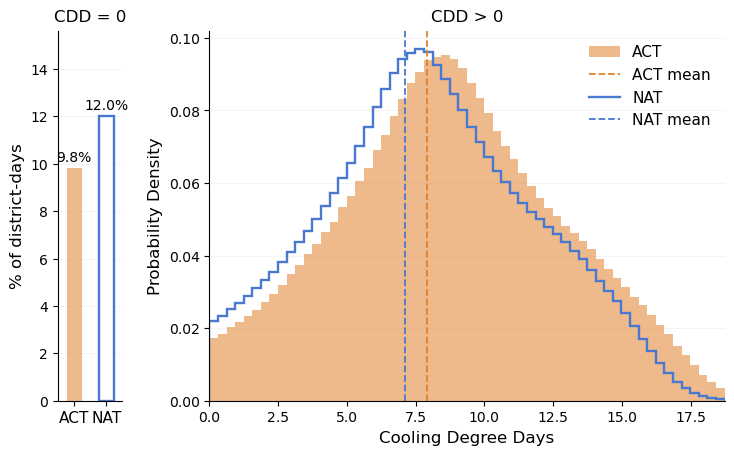

  attributable shift: +0.83 CDD (+11.6% of NAT mean)
  distribution overlap: 91.7%
  district-days at exactly zero: NAT 12.0% -> ALL 9.8% (-2.2 pp)
    (a count of cells that change category, immune to the aggregation choice)
  overlap under other bin rules:
    fd       403 bins  overlap  91.7%
    sturges   25 bins  overlap  91.7%
    auto     403 bins  overlap  91.7%
    20        20 bins  overlap  91.8%
    40        40 bins  overlap  91.7%
    80        80 bins  overlap  91.7%
  spread (sd): total NAT 4.4 / ALL 4.6 | between-district NAT 2.0 / ALL 2.1
    most of the pooled width is cross-sectional, not ensemble spread

=== B. bias-corrected ensemble vs observed ===
  comparing 11,980 district-days (36 districts x 420 periods)
                       ERA5-Land: n=   11,980  mean=   7.96  sd=  4.32  median=   8.5  min=  0.0  max=  19.8  at zero= 9.7%
                             ACT: n=6,277,520  mean=   7.92  sd=  4.60  median=   8.2  min=  0.0  max=  22.1  at zero= 9.8%
  bins: 32

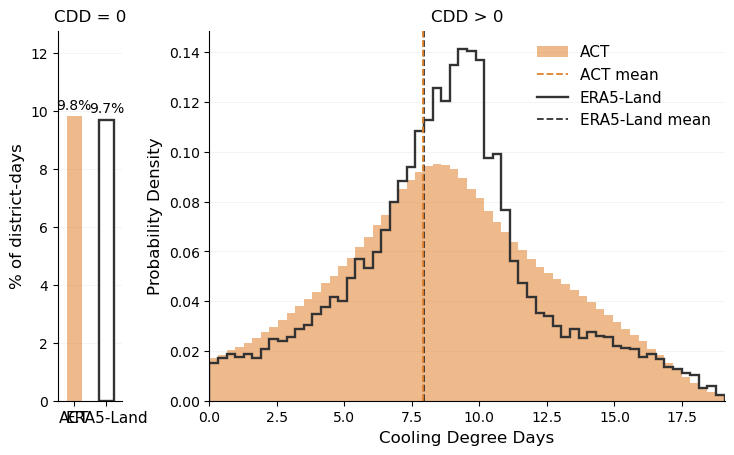

  distribution overlap: 87.2%
  mean offset (ALL - observed): -0.03 CDD (-0.4% of observed)
  spread: observed sd 4.3 vs ALL sd 4.6
  district-days at exactly zero: observed 9.7% vs ALL 9.8%
  overlap under other bin rules:
    fd       323 bins  overlap  87.2%
    sturges   24 bins  overlap  88.3%
    auto     323 bins  overlap  87.2%
    20        20 bins  overlap  88.3%
    40        40 bins  overlap  88.2%
    80        80 bins  overlap  88.0%

  paired residuals (ensemble mean - observed), 11,980 district-days:
    mean -0.03   median +0.00   sd 1.33   MAE 0.99
    correlation with observed: 0.951
    largest offsets:
      punjab||sahibzada ajit singh nagar 2017-06-05 00:00:00  observed     19.1  ALL     11.5      -7.6
      punjab||sahibzada ajit singh nagar 2017-06-04 00:00:00  observed     18.7  ALL     11.5      -7.2
      punjab||sahibzada ajit singh nagar 2018-06-14 00:00:00  observed     17.0  ALL     10.3      -6.7
      punjab||sahibzada ajit singh nagar 2018-06-25 00:00

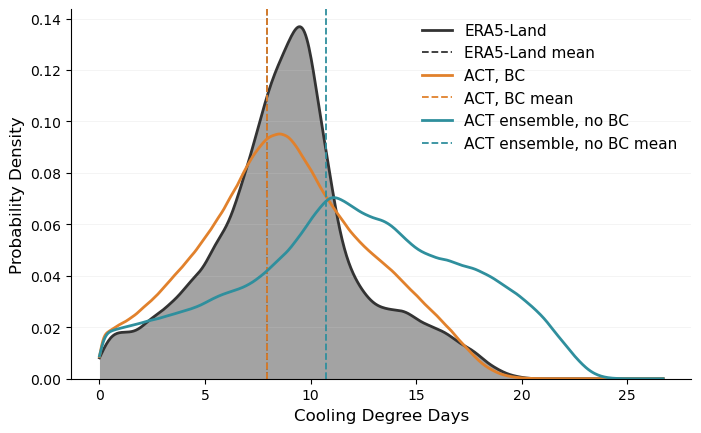

  overlap with observed: ACT, BC 88.7%, ACT ensemble, no BC 67.7%  (KDE); 87.2% for the corrected ensemble in figure B (histogram)
    the KDE reads higher because smoothing fills the gaps between sparse
    observed values -- quote the histogram figure, use the KDE as the visual

  mean CDD: raw 10.72 -> corrected 7.92 | observed 7.96
  mean offset vs observed: raw +2.76 -> corrected -0.03 CDD
  histogram overlap with observed: raw 67.0% -> corrected 87.2%
  sd: raw 6.2 -> corrected 4.6 | observed 4.3
  at zero: raw 9.4% -> corrected 9.8% | observed 9.7%

UNIT = 'district_day' (district-days); ZERO_MODE = 'panel'; ALIGN_DAYS = True; MIN_LOCATION_DAYS = 365
NOTE: the outage period falls inside the bias-correction reference period, so figure B is an internal-consistency check, not out-of-sample validation.


In [17]:
# =============================================================================
# CDD distribution figures, DISTRICT ensemble (outage panel) -- histograms
# =============================================================================
# The district counterpart of cdd_distributions.py. Same three figures, same
# statistics, same styling; what changes is the unit of observation and how the
# observed sample is defined.
#
#   A. ACT (ALL) vs NAT      -- the attribution signal at district level
#   B. Observed ERA5 vs ACT  -- the bias-correction check
#   C. Observed vs ACT (BC)  -- gaussian KDEs, including the RAW (non-bias-
#      vs ACT (no BC)           corrected) district ensemble now that it exists
#
# WHAT IS DIFFERENT FROM THE STATE SCRIPT, and why each difference matters:
#
#  1. KEY. Districts are joined on `gadm_key` ("NAME_1||NAME_2"), normalised but
#     not aliased -- both the ensemble and the ESMI panel were built against the
#     same GADM ADM2 layer, so a name that fails to match is a real problem and
#     is printed rather than quietly dropped. Only the STATE half is aliased,
#     because STATES below is written in ordinary spelling.
#
#  2. PERIOD. There is no single study year. The outage panel spans 14
#     year-months across 2016-2018, so YEARS/MONTHS are lists (or None) and
#     every cell is a district x YEAR-month, never a district x month.
#
#  3. UNBALANCED OBSERVATION. The ESMI panel observes different districts on
#     different days. A monthly CDD SUM from the ensemble covers the whole
#     month; the observed side only covers monitored days. Summing both blindly
#     would compare 30 days of model against 11 days of record and call the gap
#     bias. Two defences, both on by default:
#       ALIGN_DAYS = True  -- the ensemble is cut to the exact (district, date)
#                             pairs the observed panel contains before anything
#                             is summed, so the two monthly totals cover the
#                             same days.
#       UNIT = "district_month" | "district_day" -- at "district_day" the
#                             problem cannot arise at all, since each day is its
#                             own draw. Use it as a robustness check.
#
#  4. LOCATION FILTER. MIN_LOCATION_DAYS mirrors the >= 365-day location filter
#     in the R fitting script and in observed_cdd_district_choropleth.py, so all
#     three describe the same sample. It selects LOCATIONS, not districts: a
#     district disappears only if every one of its locations falls short.
#
#  5. SIZE. The daily district ensemble is tens of millions of rows. It is read
#     in chunks with only the needed columns and filtered as it goes, so peak
#     memory is one chunk plus the surviving rows.
#
# WHY HISTOGRAMS (A and B). A kernel density estimate spreads every observation
# into a bump, and CDD is bounded below at zero with a genuine point mass there.
# An unreflected KDE puts several percent of its mass at impossible negative
# CDD; reflecting doubles the density exactly at the bound. A histogram assigns
# each observation to exactly one bin and never puts mass anywhere else. The
# only free choice is the bin width, and its influence is reported at the end.
#
# AGGREGATION: pooled -- every district-cell (x member, for the ensemble) is its
# own draw. Averaging across districts first would destroy the zero pile-up,
# since the average of ~70 districts is zero only if every one is below base at
# once. The cost is that pooled spread is dominated by cross-sectional variation
# between hot and cool districts, not by ensemble spread; the script prints that
# decomposition so the overlap statistic is not over-read.
# =============================================================================

import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

# ---------------- config ----------------
ROOT = ""
ENS_CSV = f"{ROOT}data/attribution_runs/all_district_cdd.csv.gz"        # bias-corrected
NOBC_CSV = f"{ROOT}data/attribution_runs/all_district_cdd_nobc.csv.gz"  # raw, no BC
OBS_CSV = f"{ROOT}data/prayas_out/esmi_outage_cdd_panel.csv"
FIGDIR = f"{ROOT}figures/outage_models"

# None = every year / month present in both legs. Lists restrict, e.g.
# YEARS = [2017], MONTHS = [6, 7, 8].
YEARS = None
MONTHS = None

# Unit of observation. "district_month" matches the regression's cell and the
# state script's state-month; "district_day" is the finer robustness check.
UNIT = "district_day"

# Cut the ensemble to the exact district-days the observed panel contains before
# summing to months. Only possible when both sides are daily -- with a
# pre-aggregated monthly ensemble it is skipped with a note.
ALIGN_DAYS = True

# Study area, matching study_area_states in the R panel script. Set to None for
# every state present. Applied to the STATE half of the district key.
STATES = [
    "Punjab", "Haryana", "Rajasthan", "Delhi", "Uttar Pradesh", "Odisha",
    "Madhya Pradesh", "Gujarat", "Chhattisgarh", "Telangana", "Jharkhand",
    "Uttarakhand", "Bihar",
]

ALL_LABEL, NAT_LABEL = "ALL", "NAT"     # the labels IN THE CSVs -- do not change

# Which CDD variant. Both files carry two: CDD of the district-mean temperature
# (`cdd_tmean`) and the area-weighted mean of per-cell CDD (`cdd_cellmean`).
# They are NOT interchangeable -- name the one the model was fitted on. None =
# auto-detect, first candidate present, with a warning when both are.
ENS_CDD_COL = "cdd_tmean"
OBS_CDD_COL = "cdd_tmean"
CDD_CANDIDATES = ["cdd_tmean", "cdd_cellmean", "cdd"]

# Drop LOCATIONS observed on fewer than this many distinct days (0 = keep all).
# Mirrors the R fitting script. FULL_DAY_ONLY counts only complete 1440-minute
# days, which is what R does after its own full-day filter.
MIN_LOCATION_DAYS = 365
FULL_DAY_ONLY = False
FULL_DAY_MINUTES = 1440
LOCATION_COL = None
LOCATION_CANDIDATES = ["Location name", "location_name", "location", "Location",
                        "loc_name", "site", "site_name"]
COVERAGE_CANDIDATES = ["observed_minutes", "obs_minutes", "coverage_minutes",
                        "minutes_observed"]

# "pooled"  -> every member value is a draw (ensemble side of figure B)
# "memmean" -> ensemble collapsed to its mean per cell
ENSEMBLE_AS = "pooled"

CHUNK_ROWS = 2_000_000  # rows per read chunk for the big ensemble files

BINS = "fd"            # "fd", "sturges", "auto", or an integer

# HOW THE ZERO POINT MASS IS DRAWN. At district-day grain a fifth of the sample
# sits at exactly zero, and a density axis tall enough to show that spike leaves
# the rest of the distribution a flat smear. The spike is not really a density
# anyway -- it is a probability atom, and plotting an atom and a continuous
# density against one axis is a category error as much as a legibility problem.
#   "panel"  (default) the atom gets its own narrow axis on the left, on a
#            PERCENT scale, and the main axis shows the distribution of the
#            positive values only. Nothing is hidden and nothing is squashed.
#   "broken" one axis, split vertically: spike in a short top segment, body
#            below. Keeps a single x-axis reading at the cost of a broken y.
#   "log"    single axis, log density. Everything visible, but bar AREA no
#            longer reads as probability -- weakest of the four.
#   "none"   the original single linear axis, spike and all.
ZERO_MODE = "panel"
ZERO_PANEL_W = 8.0     # main:zero panel width ratio -- larger = narrower atom panel
MAX_BINS = 60          # cap on bins: the fd rule on millions of rows gives slivers
X_TRIM_Q = 99.9        # drop the top 0.1% from the PLOTTED range (stats use it all)

KDE_BW_MULT = 1.0      # figure C only: bandwidth multiplier, <1 = less smooth
MEAN_IN_LEGEND = True  # add the dashed mean lines to the legend
COL_ALL, COL_NAT, COL_OBS = "#E1812C", "#4878CF", "#333333"
COL_NOBC = "#2F8F9D"   # raw ensemble: its own hue, distinct from ALL/NAT
COL_GRID = "#cccccc"

# ---- font sizes (all adjustable here) --------------------------------------
FS_TITLE = 12          # panel titles ("CDD = 0", "CDD > 0")
FS_AXIS_LABEL = 12     # x/y axis labels ("Cooling Degree Days", "Probability Density")
FS_TICK = 10           # tick label numbers on the main (and broken-mode) axes
FS_LEGEND = 11         # legend text, every figure
FS_ZERO_TICK = 11      # the zero panel's own category tick labels (series names)
FS_ZERO_ANNOT = 10     # the "x.x%" annotation above each zero-mass bar

os.makedirs(FIGDIR, exist_ok=True)

UNIT_WORD = {"district_month": "district-month", "district_day": "district-day"}
if UNIT not in UNIT_WORD:
    raise SystemExit('UNIT must be "district_month" or "district_day"')
CELL = UNIT_WORD[UNIT]

if ZERO_MODE not in ("panel", "broken", "log", "none"):
    raise SystemExit('ZERO_MODE must be "panel", "broken", "log" or "none"')

# ---------------- name normalisation ----------------
# Districts are NOT aliased: both sides came from the same GADM layer, so a
# mismatch is a genuine problem and gets printed. Only state names are, because
# STATES above is written the way a person writes it.
STATE_ALIASES = {
    "orissa": "odisha",
    "uttaranchal": "uttarakhand",
    "nct of delhi": "delhi",
    "delhi nct": "delhi",
    "chattisgarh": "chhattisgarh",
    "telengana": "telangana",
    "pondicherry": "puducherry",
    "jammu kashmir": "jammu and kashmir",
    "tamilnadu": "tamil nadu",
}


def norm(s):
    return re.sub(r"\s+", " ", re.sub(r"[_\-.]", " ", str(s)).strip().lower())


def norm_state(s):
    k = norm(s)
    return STATE_ALIASES.get(k, k)


def norm_key(k):
    """district key -> 'normalised state||normalised district'."""
    parts = str(k).split("||")
    if len(parts) == 1:
        return norm_state(parts[0])
    return norm_state(parts[0]) + "||" + norm(parts[1])


def pick(explicit, candidates, columns, what):
    if explicit is not None:
        if explicit not in columns:
            raise SystemExit(f"{explicit!r} not among columns: {list(columns)}")
        return explicit
    found = [c for c in candidates if c in columns]
    if not found:
        return None
    if len(found) > 1:
        print(f"  NOTE: {len(found)} {what} columns present {found}; using "
              f"{found[0]!r}. These are different variants -- set the config "
              "value to choose.")
    return found[0]


def describe(lab, v):
    print(f"  {lab[:30]:>30}: n={v.size:>9,}  mean={v.mean():7.2f}  "
          f"sd={v.std(ddof=1):6.2f}  median={np.median(v):6.1f}  "
          f"min={v.min():5.1f}  max={v.max():6.1f}  at zero={100*(v<=0).mean():4.1f}%")


def shared_edges(values, bins=BINS):
    """Bin edges over the pooled sample, with the first edge pinned to zero when
    the data touches the bound so no bin straddles it."""
    pooled = np.concatenate(values)
    edges = np.histogram_bin_edges(pooled, bins=bins)
    if pooled.min() >= 0 and edges[0] < 0:
        edges = np.linspace(0.0, edges[-1], len(edges))
    return edges


def overlap_of(v1, v2, edges):
    """Overlapping coefficient on shared bins: area under the pointwise minimum.
    1 = indistinguishable, 0 = disjoint."""
    w = float(np.diff(edges).mean())
    h1 = np.histogram(v1, bins=edges, density=True)[0]
    h2 = np.histogram(v2, bins=edges, density=True)[0]
    return float(np.minimum(h1, h2).sum() * w)


def label_zeros(base, v):
    """Zero share is reported in the console only; the legend stays clean."""
    return base


def mean_handle(lab, v, col):
    """Proxy artist so the dashed mean line gets a legend entry of its own."""
    return Line2D([0], [0], color=col, linestyle="--", linewidth=1.3,
                  label=f"{lab} mean")


def positive_edges(values):
    """Bin edges over the POSITIVE values only, trimmed at X_TRIM_Q and capped
    at MAX_BINS. Separate from shared_edges(), which keeps the zeros and is what
    every printed statistic is computed on -- this one is presentation only."""
    pooled = np.concatenate([np.asarray(v, float) for v in values])
    pos = pooled[pooled > 0]
    if pos.size < 2:
        return np.linspace(0.0, 1.0, 11)
    hi = float(np.percentile(pos, X_TRIM_Q))
    e = np.histogram_bin_edges(pos[pos <= hi], bins=BINS)
    if len(e) - 1 > MAX_BINS:
        e = np.linspace(float(e[0]), float(e[-1]), MAX_BINS + 1)
    return e


def subdensity(v, edges):
    """(histogram of the positive values as a SUB-density, P(v = 0)).

    Scaled by (1 - P0) so it integrates to the probability of being positive,
    not to 1. That scaling is the whole point: NAT has more zero days than ACT,
    so its positive part must sit correspondingly lower. Plotting two
    CONDITIONAL densities instead would renormalise that difference away and
    the figure would show the shift in the body while hiding the shift in how
    often the base is exceeded at all."""
    v = np.asarray(v, float)
    p0 = float((v <= 0).mean())
    h = np.histogram(v[v > 0], bins=edges, density=True)[0] * (1.0 - p0)
    return h, p0


def _series_handles(lab_f, v_f, col_f, lab_o, v_o, col_o):
    handles = [Patch(facecolor=col_f, alpha=0.55, label=label_zeros(lab_f, v_f)),
               Line2D([0], [0], color=col_o, linewidth=1.7,
                      label=label_zeros(lab_o, v_o))]
    if MEAN_IN_LEGEND:
        handles = [handles[0], mean_handle(lab_f, v_f, col_f),
                   handles[1], mean_handle(lab_o, v_o, col_o)]
    return handles


def _finish(fig, stem):
    os.makedirs(os.path.dirname(stem) or ".", exist_ok=True)
    fig.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"  saved {stem}.png / .pdf")
    plt.show()


def plot_pair(outline, fill, title, xlabel, fname, edges):
    """One figure: `outline` drawn as a step behind `fill`. Each argument is
    (label, values, colour). `edges` is the shared-bin set the statistics use;
    how the zero atom is handled is ZERO_MODE's business."""
    lab_o, v_o, col_o = outline
    lab_f, v_f, col_f = fill
    stem = f"{FIGDIR}/{fname}"
    grid_kw = dict(alpha=0.25, color=COL_GRID, linewidth=0.6, axis="y")

    # ---- the atom on its own axis, body on the main one ---------------------
    if ZERO_MODE == "panel":
        ee = positive_edges([v_o, v_f])
        h_o, p0_o = subdensity(v_o, ee)
        h_f, p0_f = subdensity(v_f, ee)

        fig = plt.figure(figsize=(8.6, 4.8))
        gs = GridSpec(1, 2, width_ratios=[1, ZERO_PANEL_W], wspace=0.30, figure=fig)
        axz, ax = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

        # bars mirror the main panel's encoding: filled series filled, step
        # series hollow with the same edge weight. Spaced further apart than a
        # unit gap (BAR_X, not the default 0/1) -- FS_ZERO_TICK's larger text
        # needs more room between the two category labels than that gives, or
        # they run into each other under the two bars.
        BAR_X = 1.5
        axz.bar([0], [100 * p0_f], color=col_f, alpha=0.55, width=0.7,
                edgecolor="none")
        axz.bar([BAR_X], [100 * p0_o], facecolor="white", edgecolor=col_o,
                linewidth=1.7, width=0.7)
        for x, p in ((0, p0_f), (BAR_X, p0_o)):
            axz.annotate(f"{100*p:.1f}%", (x, 100 * p), ha="center", va="bottom",
                         fontsize=FS_ZERO_ANNOT, xytext=(0, 3), textcoords="offset points")
        axz.set_xticks([0, BAR_X])
        axz.set_xticklabels([lab_f, lab_o], fontsize=FS_ZERO_TICK)
        axz.set_xlim(-0.75, BAR_X + 0.75)
        axz.set_ylim(0, max(100 * p0_o, 100 * p0_f, 1e-9) * 1.3)
        axz.set_ylabel(f"% of {CELL}s", fontsize=FS_AXIS_LABEL)
        axz.set_title("CDD = 0", fontsize=FS_TITLE, pad=7)
        axz.tick_params(axis="y", labelsize=FS_TICK)
        axz.grid(**grid_kw)
        axz.set_axisbelow(True)
        for side in ("top", "right"):
            axz.spines[side].set_visible(False)

        ax.stairs(h_f, ee, fill=True, color=col_f, alpha=0.55)
        ax.stairs(h_o, ee, color=col_o, linewidth=1.7)
        ax.axvline(v_o.mean(), color=col_o, linestyle="--", linewidth=1.3)
        ax.axvline(v_f.mean(), color=col_f, linestyle="--", linewidth=1.3)
        ax.set_xlim(0, ee[-1])
        ax.set_title("CDD > 0", fontsize=FS_TITLE, pad=7)
        ax.set_xlabel(xlabel, fontsize=FS_AXIS_LABEL)
        ax.set_ylabel("Probability Density", fontsize=FS_AXIS_LABEL)
        ax.tick_params(labelsize=FS_TICK)
        ax.legend(handles=_series_handles(lab_f, v_f, col_f, lab_o, v_o, col_o),
                  frameon=False, fontsize=FS_LEGEND, loc="upper right")
        ax.grid(**grid_kw)
        ax.set_axisbelow(True)
        ax.set_ylim(bottom=0)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        _finish(fig, stem)
        return

    # ---- one x-axis, y broken between the spike and the body ----------------
    if ZERO_MODE == "broken":
        hi = float(np.percentile(np.concatenate([v_o, v_f]), X_TRIM_Q))
        ee = np.histogram_bin_edges(np.concatenate([v_o, v_f]), bins=BINS)
        ee = ee[ee <= hi] if (ee <= hi).sum() > 3 else ee
        if len(ee) - 1 > MAX_BINS:
            ee = np.linspace(0.0, float(ee[-1]), MAX_BINS + 1)
        d_o = np.histogram(v_o, bins=ee, density=True)[0]
        d_f = np.histogram(v_f, bins=ee, density=True)[0]
        # BOTH spikes have to land in the top segment, so it starts just below
        # the SHORTER of the two -- keyed to the taller one, the shorter spike
        # falls in the break and vanishes from the figure entirely.
        spike_lo, spike_hi = min(d_o[0], d_f[0]), max(d_o[0], d_f[0])
        body = max(d_o[1:].max(), d_f[1:].max())
        top_lo = max(body * 1.25, spike_lo * 0.90)

        fig, (axt, axb) = plt.subplots(
            2, 1, figsize=(8, 5.2), sharex=True,
            gridspec_kw=dict(height_ratios=[1, 3.2], hspace=0.08))
        for a in (axt, axb):
            a.stairs(d_f, ee, fill=True, color=col_f, alpha=0.55)
            a.stairs(d_o, ee, color=col_o, linewidth=1.7)
            a.grid(**grid_kw)
            a.set_axisbelow(True)
            a.tick_params(labelsize=FS_TICK)
        axb.axvline(v_o.mean(), color=col_o, linestyle="--", linewidth=1.3)
        axb.axvline(v_f.mean(), color=col_f, linestyle="--", linewidth=1.3)
        axt.set_ylim(top_lo, spike_hi * 1.08)
        axb.set_ylim(0, body * 1.18)
        axt.spines["bottom"].set_visible(False)
        axb.spines["top"].set_visible(False)
        axt.tick_params(bottom=False)
        for a in (axt, axb):
            for side in ("top", "right"):
                a.spines[side].set_visible(False)
        # the break marks, in axes coordinates so they survive resizing
        kw = dict(marker=[(-1, -0.6), (1, 0.6)], markersize=7, linestyle="none",
                  color="k", mec="k", mew=1, clip_on=False)
        axt.plot([0], [0], transform=axt.transAxes, **kw)
        axb.plot([0], [1], transform=axb.transAxes, **kw)
        axb.set_xlabel(xlabel, fontsize=FS_AXIS_LABEL)
        fig.supylabel("Probability Density", fontsize=FS_AXIS_LABEL, x=0.045)
        axt.legend(handles=_series_handles(lab_f, v_f, col_f, lab_o, v_o, col_o),
                   frameon=False, fontsize=FS_LEGEND, loc="upper right",
                   bbox_to_anchor=(1.0, 1.05))
        _finish(fig, stem)
        return

    # ---- single axis: log density, or the original linear one ---------------
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.hist(v_f, bins=edges, density=True, color=col_f, alpha=0.55)
    ax.hist(v_o, bins=edges, density=True, histtype="step", color=col_o,
            linewidth=1.7)
    ax.axvline(v_o.mean(), color=col_o, linestyle="--", linewidth=1.3)
    ax.axvline(v_f.mean(), color=col_f, linestyle="--", linewidth=1.3)

    ax.set_xlabel(xlabel, fontsize=FS_AXIS_LABEL)
    if ZERO_MODE == "log":
        ax.set_yscale("log")
        ax.set_ylabel("Probability Density (log scale)", fontsize=FS_AXIS_LABEL)
    else:
        ax.set_ylabel("Probability Density", fontsize=FS_AXIS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_ylim(bottom=0)
    ax.legend(handles=_series_handles(lab_f, v_f, col_f, lab_o, v_o, col_o),
              frameon=False, fontsize=FS_LEGEND, loc="upper right")
    ax.grid(**grid_kw)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    _finish(fig, stem)


def bin_sensitivity(v1, v2, label=""):
    """The bin width is the only arbitrary choice; show the headline numbers do
    not hang on it. Means and the shift are bin-independent -- only the overlap
    moves."""
    print(f"  overlap under other bin rules{label}:")
    for rule in ("fd", "sturges", "auto", 20, 40, 80):
        e = shared_edges([v1, v2], bins=rule)
        print(f"    {str(rule):8s} {len(e)-1:3d} bins  overlap "
              f"{100 * overlap_of(v1, v2, e):5.1f}%")


# ---------------- gaussian KDE (figure C only) ----------------
def silverman(v):
    """Robust plug-in bandwidth: 0.9 * min(sd, IQR/1.349) * n^(-1/5)."""
    v = np.asarray(v, float)
    if v.size < 2:
        return 1.0
    sd = v.std(ddof=1)
    iqr = float(np.subtract(*np.percentile(v, [75, 25])))
    spread = min(sd, iqr / 1.349) if iqr > 0 else sd
    return 0.9 * (spread if spread > 0 else 1.0) * v.size ** (-1 / 5)


def gauss_kde(v, x, h):
    """f(x) = (1/nh) * sum_i phi((x - x_i)/h). The Gaussian IS the kernel.

    Evaluated in blocks: the district ensemble can be millions of values, and
    the naive outer product would allocate len(x) * len(v) floats at once."""
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    out = np.zeros_like(x)
    block = max(1, int(2e7 // max(1, x.size)))
    for s in range(0, v.size, block):
        u = (x[:, None] - v[None, s:s + block]) / h
        out += np.exp(-0.5 * u ** 2).sum(axis=1)
    return out / (v.size * h * np.sqrt(2 * np.pi))


def kde_with_zero_mass(v, grid, bw_mult=1.0):
    """Returns (density, p_zero, bandwidth, leaked).

    Fitted to values above zero, then TRUNCATED AND RENORMALISED: the kernels
    sitting near the bound still spill below zero (and past the top of the
    grid), so the raw curve integrates to less than (1 - p_zero) over the
    plotted range. Dividing by the mass that actually lands on the grid puts it
    back, so curve + point mass = 1 exactly.

    This is the boundary correction to prefer over reflection here. Reflection
    folds the spilled mass back onto the bound itself, doubling the density at
    x = 0 and creating a spike whose height depends on the bandwidth.
    Renormalising spreads it proportionally over the whole positive range, which
    changes the level slightly and the shape not at all. `leaked` reports how
    much had to be redistributed -- if it is large, the bandwidth is too wide
    for how close the data sits to zero, and the histogram is the better figure.
    """
    v = np.asarray(v, float)
    p0 = float((v <= 0).mean())
    pos = v[v > 0]
    if pos.size < 2:
        return np.zeros_like(grid), p0, float("nan"), 0.0
    h = silverman(pos) * bw_mult
    d = gauss_kde(pos, grid, h)
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    on_grid = float(trapz(d, grid))
    leaked = max(0.0, 1.0 - on_grid)
    if on_grid > 0:
        d = d / on_grid * (1.0 - p0)
    return d, p0, h, leaked


def plot_kde(series, xlabel, fname, bw_mult=1.0):
    """N series as gaussian KDEs on one axes.

    `series` is a list of (label, values, colour, filled). The first entry with
    filled=True is drawn as a shaded area; the rest are lines on top, so the
    reference distribution can sit behind the comparisons. Returns
    {label: overlap-with-the-first-series}.
    """
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    top = max(float(np.max(v)) for _, v, _, _ in series) * 1.05
    grid = np.linspace(0.0, top, 512)

    fits = {}
    for lab, v, col, filled in series:
        d, p0, h, leak = kde_with_zero_mass(v, grid, bw_mult)
        fits[lab] = d
        print(f"  {lab[:28]:>28}: h={h:.1f}  P0={100*p0:.1f}%  "
              f"spilled past the bound and redistributed={100*leak:.1f}%  "
              f"curve+P0={trapz(d, grid) + p0:.4f}")
        if leak > 0.10:
            print("    WARNING: more than 10% of the kernel mass fell outside "
                  "the valid range; the bandwidth is wide relative to how close "
                  "the data sits to zero -- prefer the histogram (figure B)")

    fig, ax = plt.subplots(figsize=(8, 4.8))
    for lab, v, col, filled in series:
        if filled:
            ax.fill_between(grid, fits[lab], color=col, alpha=0.45, linewidth=0)
        ax.plot(grid, fits[lab], color=col, linewidth=2)
        ax.axvline(float(np.mean(v)), color=col, linestyle="--", linewidth=1.3)

    handles = []
    for lab, v, col, filled in series:
        handles.append(Line2D([0], [0], color=col, linewidth=2,
                               label=label_zeros(lab, v)))
        if MEAN_IN_LEGEND:
            handles.append(mean_handle(lab, v, col))

    ax.set_xlabel(xlabel, fontsize=FS_AXIS_LABEL)
    ax.set_ylabel("Probability Density", fontsize=FS_AXIS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.legend(handles=handles, frameon=False, fontsize=FS_LEGEND, loc="upper right")
    ax.grid(alpha=0.25, color=COL_GRID, linewidth=0.6, axis="y")
    ax.set_ylim(bottom=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    stem = f"{FIGDIR}/{fname}"
    plt.savefig(f"{stem}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"  saved {stem}.png / .pdf")
    plt.show()

    ref_lab, ref_v = series[0][0], series[0][1]
    p0_ref = float((np.asarray(ref_v) <= 0).mean())
    out = {}
    for lab, v, _, _ in series[1:]:
        p0 = float((np.asarray(v) <= 0).mean())
        out[lab] = float(trapz(np.minimum(fits[ref_lab], fits[lab]), grid)) \
            + min(p0_ref, p0)
    return out


# =============================================================================
# OBSERVED PANEL -- loaded first, because it defines the district-days the
# ensemble is cut to (ALIGN_DAYS) and therefore the sample every figure shows.
# =============================================================================
print("=== observed ESMI panel ===")
obs_raw = pd.read_csv(OBS_CSV)
obs_raw.columns = [c.strip() for c in obs_raw.columns]
print(f"{OBS_CSV}\n  {len(obs_raw):,} rows | columns: {list(obs_raw.columns)}")

OBS_CDD_COL = pick(OBS_CDD_COL, CDD_CANDIDATES, obs_raw.columns, "observed CDD")
if OBS_CDD_COL is None:
    raise SystemExit(f"no CDD column in {OBS_CSV}; columns: {list(obs_raw.columns)}")
LOCATION_COL = pick(LOCATION_COL, LOCATION_CANDIDATES, obs_raw.columns, "location")
COVERAGE_COL = pick(None, COVERAGE_CANDIDATES, obs_raw.columns, "coverage")
print(f"  CDD: {OBS_CDD_COL!r} | location: {LOCATION_COL!r} | coverage: {COVERAGE_COL!r}")

# --- date / year / month ---
date_col = next((c for c in ("date", "obs_date", "datetime", "day")
                  if c in obs_raw.columns), None)
if date_col is not None:
    d = pd.to_datetime(obs_raw[date_col], errors="coerce")
    if d.isna().all():
        raise SystemExit(f"could not parse {date_col!r} in {OBS_CSV} as dates")
    obs_raw["_date"] = d.dt.normalize()
    obs_raw["year"], obs_raw["month"] = d.dt.year, d.dt.month
elif {"year", "month"} <= set(obs_raw.columns):
    obs_raw["_date"] = pd.NaT
else:
    raise SystemExit("need a date column, or year+month, in the observed panel")
OBS_DAILY = obs_raw["_date"].notna().any()

# --- district key ---
if "gadm_key" in obs_raw.columns:
    obs_raw["_key"] = obs_raw["gadm_key"].astype(str)
    src = "gadm_key"
else:
    sc = next((c for c in ("state", "NAME_1", "state_name") if c in obs_raw.columns), None)
    dc = next((c for c in ("district", "NAME_2", "district_name") if c in obs_raw.columns), None)
    if not (sc and dc):
        raise SystemExit("no gadm_key, and no state/district columns to build one")
    obs_raw["_key"] = obs_raw[sc].astype(str) + "||" + obs_raw[dc].astype(str)
    src = f"{sc} + {dc}"
obs_raw["_norm"] = obs_raw["_key"].map(norm_key)
obs_raw["_state"] = obs_raw["_norm"].str.split(r"\|\|").str[0]
print(f"  district key from {src}: {obs_raw['_norm'].nunique()} districts across "
      f"{obs_raw['_state'].nunique()} states")

obs_raw = obs_raw.dropna(subset=[OBS_CDD_COL]).copy()

# --- study-area filter ---
if STATES is not None:
    want = {norm_state(s) for s in STATES}
    have = set(obs_raw["_state"])
    absent, extra = sorted(want - have), sorted(have - want)
    if absent:
        print(f"  NOTE: study states with no ESMI district in the panel: {absent}")
    if extra:
        print(f"  dropping {len(extra)} non-study state(s): {extra}")
    obs_raw = obs_raw[obs_raw["_state"].isin(want)]
    if obs_raw.empty:
        raise SystemExit("no observed rows left after the study-state filter")

# --- year / month filter ---
if YEARS is not None:
    obs_raw = obs_raw[obs_raw["year"].isin(YEARS)]
if MONTHS is not None:
    obs_raw = obs_raw[obs_raw["month"].isin(MONTHS)]
if obs_raw.empty:
    raise SystemExit("no observed rows left after the YEARS / MONTHS filter")

# --- drop short-lived monitoring locations --------------------------------
if MIN_LOCATION_DAYS:
    if LOCATION_COL is None or not OBS_DAILY:
        print(f"  NOTE: MIN_LOCATION_DAYS={MIN_LOCATION_DAYS} ignored -- needs "
              "both a location column and a date column")
    else:
        base = obs_raw
        if FULL_DAY_ONLY:
            if COVERAGE_COL is None:
                raise SystemExit("FULL_DAY_ONLY needs a coverage column")
            base = obs_raw[obs_raw[COVERAGE_COL] == FULL_DAY_MINUTES]
        ld = (base.groupby(["_norm", LOCATION_COL])
                  .agg(n_days=("_date", "nunique"), n_rows=("_date", "size"),
                       first_day=("_date", "min"), last_day=("_date", "max"))
                  .reset_index())
        keep_loc = ld[ld["n_days"] >= MIN_LOCATION_DAYS]
        drop_loc = ld[ld["n_days"] < MIN_LOCATION_DAYS]

        before = ld.groupby("_norm").size().rename("n_loc_before")
        after = keep_loc.groupby("_norm").size().rename("n_loc_after")
        change = pd.concat([before, after], axis=1).fillna(0).astype(int).reset_index()
        change["n_loc_lost"] = change["n_loc_before"] - change["n_loc_after"]
        gone = change[change["n_loc_after"] == 0]
        thinned = change[(change["n_loc_after"] > 0) & (change["n_loc_lost"] > 0)]

        print(f"\n--- location coverage filter (>= {MIN_LOCATION_DAYS} observed days"
              + (", full days only" if FULL_DAY_ONLY else "") + ") ---")
        print(f"locations: {len(keep_loc)} kept, {len(drop_loc)} dropped, of {len(ld)}")
        if len(gone):
            print(f"districts lost entirely ({len(gone)}): "
                  f"{sorted(gone['_norm'])[:12]}")
        if len(thinned):
            print(f"districts thinned but kept ({len(thinned)})")
        if keep_loc.empty:
            raise SystemExit(f"no location reaches {MIN_LOCATION_DAYS} days -- "
                              "lower MIN_LOCATION_DAYS")
        n0 = len(obs_raw)
        obs_raw = obs_raw.merge(keep_loc[["_norm", LOCATION_COL]],
                                 on=["_norm", LOCATION_COL], how="inner")
        print(f"rows: {len(obs_raw):,} of {n0:,} kept "
              f"({100 * len(obs_raw) / n0:.1f}%) | "
              f"{obs_raw['_norm'].nunique()} districts remain\n")

# --- collapse to the unit of observation ----------------------------------
# CDD is a property of the district-day, so several locations in the same
# district on the same day carry the SAME value; take the first, never the sum.
if OBS_DAILY:
    obs_day = (obs_raw.groupby(["_norm", "_date", "year", "month"], as_index=False)
                      [OBS_CDD_COL].first()
                      .rename(columns={OBS_CDD_COL: "cdd"}))
    print(f"  {len(obs_day):,} observed district-days | "
          f"{obs_day['_norm'].nunique()} districts")
    if UNIT == "district_day":
        obs = obs_day.rename(columns={"_date": "_unit"})
    else:
        obs = (obs_day.groupby(["_norm", "year", "month"], as_index=False)
                      .agg(cdd=("cdd", "sum"), n_days=("cdd", "size")))
        print(f"  summed to {len(obs):,} district-months "
              f"(median {obs['n_days'].median():.0f} observed days per cell)")
else:
    if UNIT == "district_day":
        raise SystemExit('the observed panel has no date column -- set UNIT = "district_month"')
    obs_day = None
    obs = (obs_raw.groupby(["_norm", "year", "month"], as_index=False)[OBS_CDD_COL]
                  .mean().rename(columns={OBS_CDD_COL: "cdd"}))
    print(f"  {len(obs):,} observed district-months (panel already aggregated)")

# the district-days the ensemble will be cut to
if ALIGN_DAYS and OBS_DAILY:
    obs_days = obs_day[["_norm", "_date"]].drop_duplicates()
else:
    obs_days = None
    if ALIGN_DAYS:
        print("  NOTE: ALIGN_DAYS skipped -- the observed panel is not daily")

# =============================================================================
# ENSEMBLE LOADING
# =============================================================================
def ens_schema(path):
    """Column names in a district ensemble file, whichever variant it is."""
    head = pd.read_csv(path, nrows=0)
    cols = list(head.columns)
    leg_col = next((c for c in ("leg", "scenario") if c in cols), None)
    if leg_col is None:
        raise SystemExit(f"{path}: no leg/scenario column. Columns: {cols}")
    cdd_col = pick(ENS_CDD_COL if ENS_CDD_COL in cols else None,
                   CDD_CANDIDATES, cols, "ensemble CDD")
    if cdd_col is None:
        raise SystemExit(f"{path}: no CDD column. Columns: {cols}")
    if "gadm_key" in cols:
        key_cols = ["gadm_key"]
    else:
        sc = next((c for c in ("state", "NAME_1", "state_name") if c in cols), None)
        dc = next((c for c in ("district", "NAME_2", "district_name") if c in cols), None)
        if not (sc and dc):
            raise SystemExit(f"{path}: no gadm_key and no state/district. Columns: {cols}")
        key_cols = [sc, dc]
    day_col = "day" if "day" in cols else ("date" if "date" in cols else None)
    if not {"year", "month"} <= set(cols):
        raise SystemExit(f"{path}: needs year and month columns. Columns: {cols}")
    member = "member" if "member" in cols else None
    return dict(leg=leg_col, cdd=cdd_col, key=key_cols, day=day_col,
                member=member, cols=cols)


def load_ensemble(path, tag):
    """Read, filter and collapse one district ensemble to the unit of
    observation. Identical filtering for the corrected and raw files, so a
    difference between them can never be a filtering difference."""
    sch = ens_schema(path)
    usecols = list(dict.fromkeys(
        sch["key"] + ["year", "month", sch["leg"], sch["cdd"]]
        + ([sch["day"]] if sch["day"] else [])
        + ([sch["member"]] if sch["member"] else [])))
    dtypes = {sch["cdd"]: "float32", "year": "int16", "month": "int8"}
    if sch["day"] == "day":
        dtypes["day"] = "int8"

    want_states = {norm_state(s) for s in STATES} if STATES is not None else None
    keep, n_read = [], 0
    for chunk in pd.read_csv(path, usecols=usecols, dtype=dtypes,
                              chunksize=CHUNK_ROWS):
        n_read += len(chunk)
        c = chunk[chunk[sch["leg"]].isin([ALL_LABEL, NAT_LABEL])]
        if YEARS is not None:
            c = c[c["year"].isin(YEARS)]
        if MONTHS is not None:
            c = c[c["month"].isin(MONTHS)]
        c = c.dropna(subset=[sch["cdd"]])
        if c.empty:
            continue
        if len(sch["key"]) == 1:
            k = c[sch["key"][0]].astype(str)
        else:
            k = c[sch["key"][0]].astype(str) + "||" + c[sch["key"][1]].astype(str)
        c = c.assign(_norm=k.map(norm_key))
        if want_states is not None:
            c = c[c["_norm"].str.split(r"\|\|").str[0].isin(want_states)]
        if not c.empty:
            keep.append(c)
    if not keep:
        raise SystemExit(f"no {tag} ensemble rows survive the filters in {path}")
    e = pd.concat(keep, ignore_index=True)
    print(f"{tag}: {n_read:,} rows read -> {len(e):,} kept | "
          f"{e['_norm'].nunique()} districts | "
          f"{e[sch['member']].nunique() if sch['member'] else 1} members")

    e = e.rename(columns={sch["leg"]: "leg", sch["cdd"]: "cdd"})
    mem = sch["member"] or "_member"
    if sch["member"] is None:
        e[mem] = 0

    daily = sch["day"] is not None
    if daily:
        if sch["day"] == "day":
            e["_date"] = pd.to_datetime(
                dict(year=e["year"], month=e["month"], day=e["day"]), errors="coerce")
        else:
            e["_date"] = pd.to_datetime(e["date"], errors="coerce").dt.normalize()
        bad = int(e["_date"].isna().sum())
        if bad:
            print(f"  WARNING: {bad:,} {tag} rows have an unparseable date -- dropped")
        e = e.dropna(subset=["_date"])
        if obs_days is not None:
            n0 = len(e)
            e = e.merge(obs_days, on=["_norm", "_date"], how="inner")
            print(f"  ALIGN_DAYS: {len(e):,} of {n0:,} rows fall on an observed "
                  f"district-day ({100 * len(e) / n0:.1f}%)")
            if e.empty:
                raise SystemExit("no ensemble row matches an observed district-day "
                                  "-- check the district keys on both sides")
    elif UNIT == "district_day":
        raise SystemExit(f"{path} is not daily -- set UNIT = \"district_month\"")
    else:
        print(f"  {tag} is already at district-month grain")

    # collapse to the unit
    if UNIT == "district_day":
        out = e[["_norm", "_date", "year", "month", "leg", mem, "cdd"]] \
            .rename(columns={"_date": "_unit", mem: "member"})
    elif daily:
        out = (e.groupby(["_norm", "year", "month", "leg", mem], as_index=False)
                .agg(cdd=("cdd", "sum"), n_days=("cdd", "size"))
                .rename(columns={mem: "member"}))
    else:
        out = e.rename(columns={mem: "member"})[
            ["_norm", "year", "month", "leg", "member", "cdd"]]

    # keep only year-months present in BOTH legs, so they describe one period
    out["_ym"] = out["year"].astype(int) * 100 + out["month"].astype(int)
    common = set.intersection(*(set(g["_ym"]) for _, g in out.groupby("leg")))
    dropped = sorted(set(out["_ym"]) - common)
    if dropped:
        print(f"  [{tag}] dropping year-months not in both legs: {dropped}")
    out = out[out["_ym"].isin(common)]
    yms = sorted(out["_ym"].unique())
    print(f"  {tag}: {len(out):,} {CELL} x member rows | {len(yms)} year-months "
          f"({yms[0]//100}-{yms[0]%100:02d} to {yms[-1]//100}-{yms[-1]%100:02d})")
    return out


ens = load_ensemble(ENS_CSV, "bias-corrected")

# the cell identifier every alignment below uses
CELL_KEYS = ["_norm", "_unit"] if UNIT == "district_day" else ["_norm", "_ym"]
if UNIT == "district_month":
    obs["_ym"] = obs["year"].astype(int) * 100 + obs["month"].astype(int)

# =============================================================================
# FIGURE A -- ACT (ALL) vs NAT
# =============================================================================
print("\n=== A. factual vs natural-only forcing ===")
nat_v = ens.loc[ens["leg"] == NAT_LABEL, "cdd"].to_numpy(float)
all_v = ens.loc[ens["leg"] == ALL_LABEL, "cdd"].to_numpy(float)
describe("NAT", nat_v)
describe("ACT", all_v)

edges_a = shared_edges([nat_v, all_v])
print(f"  bins: {len(edges_a)-1} of width {np.diff(edges_a).mean():.1f}, "
      f"range {edges_a[0]:.0f} to {edges_a[-1]:.0f}")
plot_pair(("NAT", nat_v, COL_NAT),
          ("ACT", all_v, COL_ALL),
          title=None,
          xlabel="Cooling Degree Days",
          fname=f"district_cdd_act_vs_nat_{UNIT}", edges=edges_a)

shift = all_v.mean() - nat_v.mean()
p0_nat, p0_all = float((nat_v <= 0).mean()), float((all_v <= 0).mean())
print(f"  attributable shift: {shift:+.2f} CDD ({100*shift/nat_v.mean():+.1f}% of NAT mean)")
print(f"  distribution overlap: {100 * overlap_of(nat_v, all_v, edges_a):.1f}%")
print(f"  {CELL}s at exactly zero: NAT {100*p0_nat:.1f}% -> ALL {100*p0_all:.1f}% "
      f"({100*(p0_all - p0_nat):+.1f} pp)")
print("    (a count of cells that change category, immune to the aggregation choice)")
bin_sensitivity(nat_v, all_v)

# pooled spread is dominated by between-district variation, so the overlap above
# is descriptive only -- the mean shift and the zero share are the result
between = ens.groupby(["leg", "_norm"])["cdd"].mean().groupby("leg").std(ddof=1)
print(f"  spread (sd): total NAT {nat_v.std(ddof=1):.1f} / ALL {all_v.std(ddof=1):.1f}"
      f" | between-district NAT {between[NAT_LABEL]:.1f} / ALL {between[ALL_LABEL]:.1f}")
print("    most of the pooled width is cross-sectional, not ensemble spread")

# =============================================================================
# FIGURE B -- observed ERA5 vs ACT (ALL)
# =============================================================================
print("\n=== B. bias-corrected ensemble vs observed ===")
ens_all = ens[ens["leg"] == ALL_LABEL]
ens_cells = set(map(tuple, ens_all[CELL_KEYS].drop_duplicates().to_numpy()))
obs_cells = set(map(tuple, obs[CELL_KEYS].drop_duplicates().to_numpy()))
both = ens_cells & obs_cells
if not both:
    raise SystemExit("no overlapping cells -- check the district keys on both sides")
only_e = sorted({k for k, _ in ens_cells} - {k for k, _ in obs_cells})
only_o = sorted({k for k, _ in obs_cells} - {k for k, _ in ens_cells})
if only_e:
    print(f"  districts in the ensemble only ({len(only_e)}): {only_e[:8]}")
if only_o:
    print(f"  districts in the observed panel only ({len(only_o)}): {only_o[:8]}")
    print("    these are UNMATCHED KEYS, not a coverage gap -- both files were "
          "built on GADM ADM2, so a mismatch means a spelling or crosswalk fault")

sel = pd.DataFrame(sorted(both), columns=CELL_KEYS)
ens_m = ens_all.merge(sel, on=CELL_KEYS)
obs_m = obs.merge(sel, on=CELL_KEYS)
print(f"  comparing {len(sel):,} {CELL}s "
      f"({sel['_norm'].nunique()} districts x {sel[CELL_KEYS[1]].nunique()} periods)")


def as_series(frame, name):
    """Apply ENSEMBLE_AS to an aligned ensemble frame."""
    if ENSEMBLE_AS == "pooled":
        return frame["cdd"].to_numpy(float), name
    if ENSEMBLE_AS == "memmean":
        return frame.groupby(CELL_KEYS)["cdd"].mean().to_numpy(), f"{name} mean"
    raise SystemExit('ENSEMBLE_AS must be "pooled" or "memmean"')


obs_v = obs_m["cdd"].to_numpy(float)
ensb_v, ens_name = as_series(ens_m, "ACT")
describe("ERA5-Land", obs_v)
describe(ens_name, ensb_v)

edges_b = shared_edges([obs_v, ensb_v])
print(f"  bins: {len(edges_b)-1} of width {np.diff(edges_b).mean():.1f}, "
      f"range {edges_b[0]:.0f} to {edges_b[-1]:.0f}")
plot_pair(("ERA5-Land", obs_v, COL_OBS),
          (ens_name, ensb_v, COL_ALL),
          title=None,
          xlabel="Cooling Degree Days",
          fname=f"district_cdd_obs_vs_all_{UNIT}", edges=edges_b)

print(f"  distribution overlap: {100 * overlap_of(obs_v, ensb_v, edges_b):.1f}%")
print(f"  mean offset (ALL - observed): {ensb_v.mean() - obs_v.mean():+.2f} CDD "
      f"({100*(ensb_v.mean() - obs_v.mean())/obs_v.mean():+.1f}% of observed)")
print(f"  spread: observed sd {obs_v.std(ddof=1):.1f} vs ALL sd {ensb_v.std(ddof=1):.1f}")
p0_o, p0_e = float((obs_v <= 0).mean()), float((ensb_v <= 0).mean())
print(f"  {CELL}s at exactly zero: observed {100*p0_o:.1f}% vs ALL {100*p0_e:.1f}%")
if abs(p0_e - p0_o) > 0.02:
    print("    -> the ensemble disagrees with the record about how often a "
          "district stays below base; a bias-correction diagnostic in itself")
bin_sensitivity(obs_v, ensb_v)

# paired check on RAW values: aggregate agreement can hide offsetting errors
paired = (ens_m.groupby(CELL_KEYS)["cdd"].mean().rename("ens").reset_index()
          .merge(obs_m[CELL_KEYS + ["cdd"]].rename(columns={"cdd": "obs"}),
                 on=CELL_KEYS))
paired["resid"] = paired["ens"] - paired["obs"]
paired = paired.rename(columns={"_norm": "district_key",
                                 "_ym": "period", "_unit": "period"})
print(f"\n  paired residuals (ensemble mean - observed), {len(paired):,} {CELL}s:")
print(f"    mean {paired['resid'].mean():+.2f}   median {paired['resid'].median():+.2f}   "
      f"sd {paired['resid'].std(ddof=1):.2f}   MAE {paired['resid'].abs().mean():.2f}")
print(f"    correlation with observed: {paired['ens'].corr(paired['obs']):.3f}")
worst = paired.reindex(paired["resid"].abs().sort_values(ascending=False).index).head(8)
print("    largest offsets:")
for r in worst.itertuples(index=False):
    print(f"      {str(r.district_key)[:34]:<34} {str(r.period):>10}  "
          f"observed {r.obs:8.1f}  ALL {r.ens:8.1f}  {r.resid:+8.1f}")

# =============================================================================
# FIGURE C -- observed vs bias-corrected ACT vs RAW ACT, gaussian KDEs
# =============================================================================
# Same alignment as figure B: the raw ensemble is cut to the identical cells, so
# the gap between the two ACT curves is the bias correction and nothing else.
# Read it left to right: raw ensemble -> corrected ensemble -> observed record.
# If the correction is doing its job, the corrected curve sits on the observed
# one and the raw curve is the outlier.
#
# KDEs rather than histograms because the observed sample has one value per cell
# and looks ragged beside a 500-member ensemble. Quote the numbers from B and
# from the console below, not the visual.
print("\n=== C. observed vs corrected vs raw ACT, gaussian kernels ===")
bc_name = f"{ens_name}, BC"
series = [("ERA5-Land", obs_v, COL_OBS, True),
          (bc_name, ensb_v, COL_ALL, False)]

if os.path.exists(NOBC_CSV):
    ens_raw = load_ensemble(NOBC_CSV, "raw (no BC)")
    raw_all = ens_raw[ens_raw["leg"] == ALL_LABEL]
    raw_cells = set(map(tuple, raw_all[CELL_KEYS].drop_duplicates().to_numpy()))
    missing_cells = both - raw_cells
    if missing_cells:
        print(f"  NOTE: {len(missing_cells):,} of the {len(both):,} compared {CELL}s "
              "are absent from the raw file; the raw curve covers fewer cells")
    raw_m = raw_all.merge(sel, on=CELL_KEYS)
    raw_v, raw_name = as_series(raw_m, "ACT ensemble, no BC")
    describe(raw_name, raw_v)
    series.append((raw_name, raw_v, COL_NOBC, False))
else:
    raw_v = None
    print(f"  NOTE: {NOBC_CSV} not found -- drawing observed vs corrected only")

ov_kde = plot_kde(series, xlabel="Cooling Degree Days",
                   fname=f"district_cdd_obs_vs_all_{UNIT}_kde", bw_mult=KDE_BW_MULT)

ov_hist = overlap_of(obs_v, ensb_v, edges_b)
print(f"  overlap with observed: "
      + ", ".join(f"{k} {100*v:.1f}%" for k, v in ov_kde.items())
      + f"  (KDE); {100*ov_hist:.1f}% for the corrected ensemble in figure B "
      "(histogram)")
print("    the KDE reads higher because smoothing fills the gaps between sparse")
print("    observed values -- quote the histogram figure, use the KDE as the visual")

if raw_v is not None:
    # what the correction bought, in one line each
    edges_c = shared_edges([obs_v, raw_v])
    print(f"\n  mean CDD: raw {raw_v.mean():.2f} -> corrected {ensb_v.mean():.2f} "
          f"| observed {obs_v.mean():.2f}")
    print(f"  mean offset vs observed: raw {raw_v.mean() - obs_v.mean():+.2f} -> "
          f"corrected {ensb_v.mean() - obs_v.mean():+.2f} CDD")
    print(f"  histogram overlap with observed: raw "
          f"{100 * overlap_of(obs_v, raw_v, edges_c):.1f}% -> corrected "
          f"{100 * ov_hist:.1f}%")
    print(f"  sd: raw {raw_v.std(ddof=1):.1f} -> corrected {ensb_v.std(ddof=1):.1f} "
          f"| observed {obs_v.std(ddof=1):.1f}")
    print(f"  at zero: raw {100*(raw_v <= 0).mean():.1f}% -> corrected "
          f"{100*p0_e:.1f}% | observed {100*p0_o:.1f}%")

print(f"\nUNIT = {UNIT!r} ({CELL}s); ZERO_MODE = {ZERO_MODE!r}; ALIGN_DAYS = {ALIGN_DAYS and obs_days is not None}; "
      f"MIN_LOCATION_DAYS = {MIN_LOCATION_DAYS}")
print("NOTE: the outage period falls inside the bias-correction reference period, "
      "so figure B is an internal-consistency check, not out-of-sample validation.")

# Response Curve Comparison

[demand] electricity_requirement | curve 400 pts, CDD 0.0-267.2 | baseline 4,054.5 MU
    density NAT: 61,425 values, mean CDD 210.5
    density ACT: 61,425 values, mean CDD 242.2
[shortage] electricity_shortage | curve 400 pts, CDD 0.0-267.2 | baseline 13.2 MU
    density NAT: 61,425 values, mean CDD 210.5
    density ACT: 61,425 values, mean CDD 242.2
[outage] curve 400 pts, CDD 0.0-19.8 | baseline 154.66 min/day
    density NAT: 213,792 values, mean CDD 7.1
    density ACT: 213,792 values, mean CDD 7.9

saved figures/model_comparison/response_curve_combined_demand_shortage_outage.png / .pdf


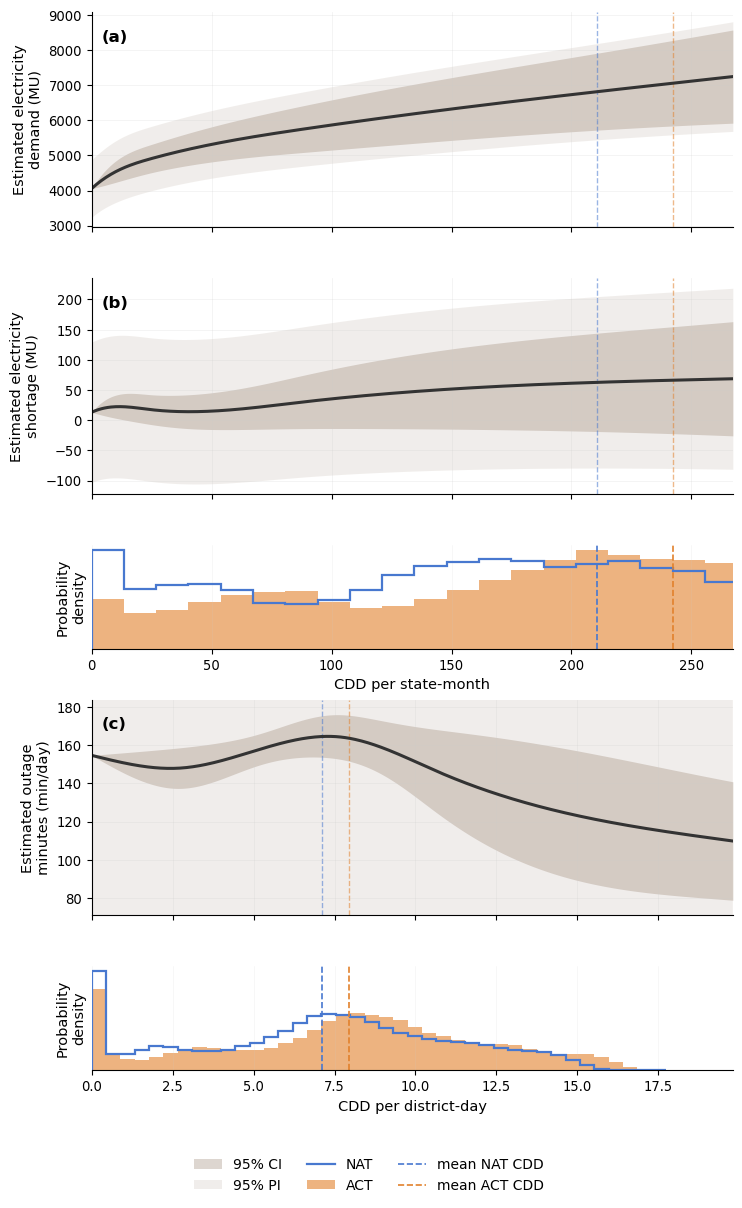


[demand] electricity_requirement
  peak: 7,248.48 MU at CDD 267.2  (curve is monotonic -- peak is just its high end)
  slope positive over 100% of the fitted CDD range
  positive-slope region roughly CDD 0.0 to 267.2
  100.0% of the NAT CDD distribution sits on a positive slope
  100.0% of the ACT CDD distribution sits on a positive slope
  curve over each distribution: NAT 6,507.82 -> ACT 6,688.67 MU  (+180.85, +2.8%)
  that difference is the attribution result, read off this panel

[shortage] electricity_shortage
  peak: 68.70 MU at CDD 267.2  (curve is monotonic -- peak is just its high end)
  slope positive over 89% of the fitted CDD range
  positive-slope region roughly CDD 0.0 to 267.2
   93.8% of the NAT CDD distribution sits on a positive slope
   96.2% of the ACT CDD distribution sits on a positive slope
  curve over each distribution: NAT 53.22 -> ACT 56.82 MU  (+3.60, +6.8%)
  that difference is the attribution result, read off this panel

[outage] outage
  peak: 164.60 min

In [18]:
# =============================================================================
# Model-implied response to CDD: DEMAND / SHORTAGE (left) + OUTAGE (right)
# =============================================================================
# Combines response_curve_stacked.py (demand vs shortage, state-month panel,
# one shared density) and response_curve_outage.py (ESMI district-day panel,
# its own density) into a single figure with two side-by-side columns. Each
# column is internally identical to what the standalone script drew: response
# curve(s) stacked above a CDD density panel, sharing one x-axis within that
# column. The two columns do NOT share an x-axis with each other -- the left
# column's CDD is a state-month aggregate, the right column's is a daily
# district value, and the two are not the same quantity.
#
# Because both source scripts use the same colour/alpha conventions for the
# CI/PI bands, the NAT/ALL/observed distributions and their mean-CDD guides,
# one legend at the bottom of the figure covers both columns without any
# entry needing to be listed twice.
#
# Left column needs section 11 of both fitting scripts (demand, shortage) to
# have been run, which writes response_curve_<MODEL>.csv and
# response_curve_knots_<MODEL>.csv; its density comes from
# RUNS[DENSITY_FROM]'s attribution_predictions.csv. A loud warning fires if the
# two runs' CDD samples disagree, since one shared density panel is only
# honest when they don't.
#
# Right column needs section 11 (plus the PI/bootstrap/k-fold uncertainty
# edits) of fit_prayas_cdd_model_spline.R, which writes the outage model's own
# response_curve_<MODEL>.csv / response_curve_knots_<MODEL>.csv, and its own
# density from attribution_predictions_district.csv.
#
# TWO BANDS ARE DRAWN IN EVERY CURVE PANEL -- DO NOT CONFUSE THEM:
#
# 1) CI (`lo`/`hi`, the darker band): spline-coefficient uncertainty only,
#    se(x) = sqrt(B(x) V B(x)'),  V = vcov[ns, ns]. How precisely the MEAN
#    response is known.
#
# 2) PI (`pred_lo`/`pred_hi`, the lighter band drawn behind it): adds the
#    model's residual variance, pred_se(x) = sqrt(se(x)^2 + resid_sigma^2).
#    How far an individual observation can land from the mean curve.
#    Necessarily wider than the CI, often by a lot when R^2 is low.
#
# Both bands exclude uncertainty in the fixed-effect baseline, which shifts a
# curve vertically without changing its shape (for the outage panel, that
# baseline is itself a constructed, observation-weighted average over the
# district_month/district_year FE levels used in attribution -- not a single
# model parameter, and not resampled here; see fit_prayas_cdd_model_spline.R
# section 11). Say so in the caption.
#
# NOTE ON PANEL (c)'S Y-AXIS: outage's PI is enormous relative to its fit
# curve (see the CV(RMSE)/mean-relative-PI-width diagnostics), so letting the
# axis autoscale to include the full PI band squashes the point-estimate curve
# into a thin sliver. Panel (c) instead zooms its y-axis to the CI band (the
# fit curve's own uncertainty), via `zoom_to_ci` in the OUTAGE config below --
# the PI simply runs off the top/bottom of the visible panel, which is an
# honest way to show "the mean response is clear, individual observations are
# not" without hiding either fact. Say so in the caption too.
# =============================================================================

import matplotlib.backends.backend_pdf  # noqa: F401  (import before geo libs)
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---------------- config: shared look ---------------------------------------
ROOT = ""
FIGDIR = f"{ROOT}figures/model_comparison"

LEG_NAMES = {"NAT": "NAT", "ALL": "ACT", "observed": "Observed (ERA5)"}

MEAN_GUIDES = True        # carry the NAT/ACT mean lines up through the curves
SHOW_BASELINE = False     # dotted line + label at the mean-FE level
SHOW_KNOTS = False
SHOW_PI = True            # draw the estimation-interval band behind the CI
SHOW_DIAGNOSTICS = False  # annotate each curve panel with CV(RMSE) and mean rel. PI width
DENSITY_BINS = 40
WEIGHT_COL = None         # weight column in the density CSVs, or None
MEAN_TOL = 0.5            # CDD gap above which the two left-column runs are NOT a shared input
ZOOM_PAD_FRAC = 0.08      # fractional padding added around the CI band for any zoomed panel

COL_CURVE = "#333333"     # the response function is neutral -- it is one series
COL_BAND = "#A08C7A"      # CI (darker) and PI (same colour, lower alpha) share this
COL_NAT = "#4878CF"
COL_ALL = "#E1812C"
COL_OBS = "#7a7a7a"
COL_GRID = "#cccccc"
CI_ALPHA = 0.35
PI_ALPHA = 0.15

os.makedirs(FIGDIR, exist_ok=True)

# ---------------- config: left column (demand + shortage) -------------------
RERUN_HINT_LEFT = (
    "Run section 11 of that run's fitting script first -- it is generic (it "
    "reads dependent_variable and output_dir), so it needs no edits for the "
    "shortage run."
)
RUNS = [
    dict(key="demand", statdir=f"{ROOT}data/fit_statistics/demand_models",
         model="CDD-Ys-Ms", title="(a)",
         rerun_hint=RERUN_HINT_LEFT),
    dict(key="shortage", statdir=f"{ROOT}data/fit_statistics/shortage_models",
         model="CDD-Ys-Ms", title="(b)",
         rerun_hint=RERUN_HINT_LEFT),
]
DENSITY_SOURCE_LEFT = "both"     # "both" | "NAT" | "ALL" | "observed"
DENSITY_FROM = 0                 # index into RUNS supplying the left column's shared density
X_LABEL_LEFT = "CDD per state-month"
Y_LABELS = {
    "electricity_requirement": "Estimated electricity\ndemand (MU)",
    "electricity_shortage": "Estimated electricity\nshortage (MU)",
    "peak_shortage": "Estimated peak\nshortage (MW)",
}
UNITS = {"electricity_requirement": "MU", "electricity_shortage": "MU",
         "peak_shortage": "MW"}

# ---------------- config: right column (outage) -------------------------------
OUTAGE = dict(
    key="outage",
    statdir=f"{ROOT}data/fit_statistics/outage_models",   # outage script's output_dir
    model="CDD-Yd-Md",                                       # attribution_model_name
    title="(c)",
    rerun_hint=("Run section 11 (and the PI/bootstrap/k-fold uncertainty edits) "
                "of fit_prayas_cdd_model_spline.R first."),
    pred_csv="attribution_predictions_district.csv",
    zoom_to_ci=True,   # this panel's PI is enormous -- zoom the y-axis to the
                       # CI band instead of letting it autoscale to fit the PI
)
DENSITY_SOURCE_RIGHT = "both"
X_LABEL_RIGHT = "CDD per district-day"
Y_LABEL_RIGHT = "Estimated outage\nminutes (min/day)"
UNIT_RIGHT = "min/day"


# ---------------- shared loading helpers --------------------------------------
def _need(path, what, rerun_hint):
    if not os.path.exists(path):
        raise SystemExit(f"missing {what}:\n  {path}\n{rerun_hint}")
    return path


def _weights(sub):
    return None if WEIGHT_COL is None else sub[WEIGHT_COL].to_numpy(float)


def wmean(v, w):
    return float(np.average(v, weights=w)) if w is not None else float(np.mean(v))


def load_density(statdir, source, rerun_hint, pred_csv="attribution_predictions.csv"):
    """{name: (values, weights)} for one column's CDD distribution."""
    if source == "observed":
        obs = pd.read_csv(_need(f"{statdir}/response_curve_observed_cdd.csv",
                                 "observed CDD", rerun_hint))
        return {"observed": (obs["cdd"].to_numpy(float), _weights(obs))}

    path = _need(f"{statdir}/{pred_csv}", "attribution predictions", rerun_hint)
    usecols = ["scenario", "cdd"] + ([WEIGHT_COL] if WEIGHT_COL else [])
    pred = pd.read_csv(path, usecols=usecols)
    names = ["NAT", "ALL"] if source == "both" else [source]
    out = {}
    for name in names:
        sub = pred[pred["scenario"] == name]
        if sub.empty:
            raise SystemExit(f"no rows with scenario == {name!r} in {path}")
        out[name] = (sub["cdd"].to_numpy(float), _weights(sub))
    return out


def load_panel(p, density_source, pred_csv="attribution_predictions.csv"):
    """Load one response-curve panel's curve/knots/density and derived stats, in place."""
    p["curve"] = pd.read_csv(
        _need(f"{p['statdir']}/response_curve_{p['model']}.csv", "response curve",
              p["rerun_hint"])
    ).sort_values("cdd")
    if SHOW_PI and not {"pred_lo", "pred_hi"}.issubset(p["curve"].columns):
        raise SystemExit(
            f"[{p['key']}] response_curve_{p['model']}.csv has no pred_lo/pred_hi "
            "columns -- rerun that fitting script's estimation-interval edit, "
            "or set SHOW_PI = False to plot the CI only."
        )
    if SHOW_DIAGNOSTICS and not {"cv_rmse_pct", "mean_rel_pi_pct"}.issubset(p["curve"].columns):
        raise SystemExit(
            f"[{p['key']}] response_curve_{p['model']}.csv has no cv_rmse_pct/"
            "mean_rel_pi_pct columns -- rerun that fitting script's uncertainty "
            "edits, or set SHOW_DIAGNOSTICS = False."
        )
    kpath = f"{p['statdir']}/response_curve_knots_{p['model']}.csv"
    p["knots"] = pd.read_csv(kpath) if (SHOW_KNOTS and os.path.exists(kpath)) else None
    p["dens"] = load_density(p["statdir"], density_source, p["rerun_hint"], pred_csv)
    p["baseline"] = float(p["curve"]["baseline"].iloc[0])
    if SHOW_DIAGNOSTICS:
        p["cv_rmse_pct"] = float(p["curve"]["cv_rmse_pct"].iloc[0])
        p["mean_rel_pi_pct"] = float(p["curve"]["mean_rel_pi_pct"].iloc[0])
    dv = str(p["curve"].get("dependent_variable", pd.Series([p["key"]])).iloc[0])
    p["dv"] = dv

    c = p["curve"]
    p["slope"] = np.gradient(c["fit"].to_numpy(), c["cdd"].to_numpy())
    p["means"] = {k: wmean(v, w) for k, (v, w) in p["dens"].items()}
    if {"NAT", "ALL"} <= set(p["dens"]):
        def _fit_over(leg):
            v, w = p["dens"][leg]
            ww = w if w is not None else np.ones_like(v, dtype=float)
            return float(np.average(np.interp(v, c["cdd"], c["fit"]), weights=ww))
        p["f_nat"], p["f_all"] = _fit_over("NAT"), _fit_over("ALL")
        p["delta"] = p["f_all"] - p["f_nat"]
    else:
        p["delta"] = None
    return p


# ---------------- load left column (demand + shortage) ------------------------
for r in RUNS:
    load_panel(r, DENSITY_SOURCE_LEFT)
    r["ylab"] = Y_LABELS.get(r["dv"], f"Predicted {r['dv']}")
    r["unit"] = UNITS.get(r["dv"], "")
    print(f"[{r['key']}] {r['dv']} | curve {len(r['curve'])} pts, CDD "
          f"{r['curve']['cdd'].min():.1f}-{r['curve']['cdd'].max():.1f} | baseline "
          f"{r['baseline']:,.1f} {r['unit']}")
    for k, m in r["means"].items():
        print(f"    density {LEG_NAMES.get(k, k)}: {len(r['dens'][k][0]):,} values, "
              f"mean CDD {m:.1f}")

# One shared density panel is only honest if both left-column runs sit on the
# same climate input.
ref = RUNS[DENSITY_FROM]
for r in RUNS:
    shared = set(ref["means"]) & set(r["means"])
    gaps = {k: abs(ref["means"][k] - r["means"][k]) for k in shared}
    if gaps and max(gaps.values()) > MEAN_TOL:
        print(f"\nWARNING: [{r['key']}] CDD distribution differs from the panel "
              f"drawn from [{ref['key']}] (max mean gap {max(gaps.values()):.2f} "
              "CDD). The runs cover different samples, so the shared density "
              "panel does not describe both curves -- set DENSITY_FROM per run "
              "and go back to a per-panel density, or align the samples.")

dens_left, means_left = ref["dens"], ref["means"]

# ---------------- load right column (outage) -----------------------------------
load_panel(OUTAGE, DENSITY_SOURCE_RIGHT, pred_csv=OUTAGE["pred_csv"])
OUTAGE["ylab"] = Y_LABEL_RIGHT
OUTAGE["unit"] = UNIT_RIGHT
print(f"[{OUTAGE['key']}] curve {len(OUTAGE['curve'])} pts, CDD "
      f"{OUTAGE['curve']['cdd'].min():.1f}-{OUTAGE['curve']['cdd'].max():.1f} | "
      f"baseline {OUTAGE['baseline']:,.2f} {OUTAGE['unit']}")
for k, m in OUTAGE["means"].items():
    print(f"    density {LEG_NAMES.get(k, k)}: {len(OUTAGE['dens'][k][0]):,} values, "
          f"mean CDD {m:.1f}")

dens_right, means_right = OUTAGE["dens"], OUTAGE["means"]


# ---------------- figure ---------------------------------------------------------
FS_TITLE = 12      # panel labels ("(a) Electricity requirement", ...)
FS_AXIS = 10.5     # axis labels (x/y)
FS_TICK = 9.5      # tick labels
FS_LEGEND = 10     # shared legend
FS_DIAG = 8.5      # optional diagnostics annotation


def draw_block(fig, gs, row0, panels, dens, means, x_label, knot_kinds):
    """Draw one vertical block starting at gs row `row0`: each panel's response
    curve stacked above a density panel at the bottom, sharing that block's own
    x-axis (NOT shared with any other block -- different blocks can be
    different CDD quantities entirely). Mutates knot_kinds in place with
    whatever knot kinds this block actually drew."""
    n = len(panels)
    xlo = min(p["curve"]["cdd"].min() for p in panels)
    xhi = max(p["curve"]["cdd"].max() for p in panels)
    axes = []
    for i, p in enumerate(panels):
        ax = fig.add_subplot(gs[row0 + i, 0], sharex=axes[0] if axes else None)
        axes.append(ax)
        c = p["curve"]

        # PI drawn first (wider, fainter) so the CI sits visibly inside it
        if SHOW_PI:
            ax.fill_between(c["cdd"], c["pred_lo"], c["pred_hi"], color=COL_BAND,
                             alpha=PI_ALPHA, linewidth=0, zorder=0)
        ax.fill_between(c["cdd"], c["lo"], c["hi"], color=COL_BAND, alpha=CI_ALPHA,
                         linewidth=0, zorder=1)
        ax.plot(c["cdd"], c["fit"], color=COL_CURVE, linewidth=2.2, zorder=2)

        if SHOW_BASELINE:
            ax.axhline(p["baseline"], color="#999999", linestyle=":", linewidth=1)
            f = c["fit"].to_numpy()
            left_end = abs(f[0] - p["baseline"]) > abs(f[-1] - p["baseline"])
            ax.annotate(f"baseline {p['baseline']:,.0f} {p['unit']}",
                        xy=(c["cdd"].min() if left_end else c["cdd"].max(), p["baseline"]),
                        xytext=(4 if left_end else -4, 5), textcoords="offset points",
                        ha="left" if left_end else "right", fontsize=8, color="#666666")

        if p["knots"] is not None:
            for _, k in p["knots"].iterrows():
                ax.axvline(k["value"], color="#bbbbbb",
                           linestyle="--" if k["kind"] == "interior" else "-",
                           linewidth=0.8, zorder=0)
                knot_kinds.add(k["kind"])

        # carry the scenario means up from the density panel: where they cross
        # each curve IS the attribution, so the eye can do the subtraction
        if MEAN_GUIDES:
            for name, m in means.items():
                ax.axvline(m, color={"NAT": COL_NAT, "ALL": COL_ALL}.get(name, COL_OBS),
                           linestyle="--", linewidth=1.0, alpha=0.55, zorder=1)

        if p["title"]:
            ax.text(0.015, 0.92, p["title"], transform=ax.transAxes, fontsize=FS_TITLE,
                    fontweight="bold", va="top")
        if SHOW_DIAGNOSTICS:
            ax.text(0.015, 0.80,
                    f"CV(RMSE) {p['cv_rmse_pct']:.1f}%  |  mean rel. PI width "
                    f"{p['mean_rel_pi_pct']:.1f}%",
                    transform=ax.transAxes, fontsize=FS_DIAG, color="#555555", va="top")

        # This panel's PI dwarfs its own CI (see the CV(RMSE)/mean-relative-PI-
        # width diagnostics) -- autoscaling to the PI would squash the fit
        # curve into a thin sliver, so instead zoom the y-axis to the CI band
        # (the fit curve's own uncertainty) and let the PI simply run off the
        # top/bottom of the visible panel.
        if p.get("zoom_to_ci"):
            ylo, yhi = float(c["lo"].min()), float(c["hi"].max())
            pad = ZOOM_PAD_FRAC * (yhi - ylo)
            ax.set_ylim(ylo - pad, yhi + pad)

        ax.set_ylabel(p["ylab"], fontsize=FS_AXIS)
        ax.tick_params(axis="both", labelsize=FS_TICK)
        ax.grid(alpha=0.25, color=COL_GRID, linewidth=0.6)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        plt.setp(ax.get_xticklabels(), visible=False)

    # --- the density panel ---
    axd = fig.add_subplot(gs[row0 + n, 0], sharex=axes[0])
    allv = np.concatenate([v for v, _ in dens.values()])
    bins = np.linspace(float(allv.min()), float(allv.max()), DENSITY_BINS + 1)
    for name, (v, w) in dens.items():
        col = {"NAT": COL_NAT, "ALL": COL_ALL}.get(name, COL_OBS)
        leg = LEG_NAMES.get(name, name)
        if name == "NAT" and len(dens) > 1:
            # counterfactual as an outline behind the factual fill, so the shift
            # between them is legible where they overlap
            axd.hist(v, bins=bins, weights=w, density=True, histtype="step",
                     color=col, linewidth=1.6, label=leg)
        else:
            axd.hist(v, bins=bins, weights=w, density=True, color=col,
                     alpha=0.6 if len(dens) > 1 else 0.75, label=leg)
        axd.axvline(means[name], color=col, linestyle="--", linewidth=1.2)

    axd.set_xlabel(x_label, fontsize=FS_AXIS)
    axd.set_ylabel("Probability\ndensity", fontsize=FS_AXIS)
    axd.set_yticks([])
    axd.tick_params(axis="x", labelsize=FS_TICK)
    axd.set_xlim(xlo, xhi)
    axd.grid(alpha=0.2, color=COL_GRID, linewidth=0.5, axis="x")
    for side in ("top", "right", "left"):
        axd.spines[side].set_visible(False)


# One column, top to bottom: demand curve, shortage curve, their shared
# density, outage curve, outage's own density -- sized (width + row heights)
# the same way the fit-stats summary figure was, so it fills a full A4 page
# without overflowing it (LaTeX still scales by \linewidth; keeping this
# aspect ratio close to what worked there is what avoids overflow).
FIG_W = 7.5
ROW_H_CURVE = 2.70   # inches per response-curve row
ROW_H_DENS = 1.30    # inches per density row
LEGEND_IN = 1.35     # inches reserved at the bottom for the last x-label + shared legend
                      # (legend stays pinned to the figure's bottom edge below, so growing
                      # this widens the gap between the x-label and the legend, not the
                      # legend's own size)

n_left = len(RUNS)      # demand, shortage
n_right = 1             # outage
height_ratios = [ROW_H_CURVE] * n_left + [ROW_H_DENS] + \
                [ROW_H_CURVE] * n_right + [ROW_H_DENS]
FIG_H = sum(height_ratios) + LEGEND_IN

fig = plt.figure(figsize=(FIG_W, FIG_H))
# hspace is generous because a density panel's x-axis label (below its own
# axis) and the next block's panel-label text (near the top of its axis) sit
# right across a row boundary from each other -- too small a gap here means
# those two text elements collide rather than the plot areas themselves.
gs = fig.add_gridspec(len(height_ratios), 1, height_ratios=height_ratios,
                       hspace=0.30, left=0.13, right=0.985, top=0.99,
                       bottom=LEGEND_IN / FIG_H)

knot_kinds = set()     # which knot kinds actually got drawn, for the legend
draw_block(fig, gs, 0, RUNS, dens_left, means_left, X_LABEL_LEFT, knot_kinds)
draw_block(fig, gs, n_left + 1, [OUTAGE], dens_right, means_right, X_LABEL_RIGHT, knot_kinds)

# --- one legend for every mark in the figure ----------------------------------
# Built by hand rather than from the axes, so the vertical dashed lines
# (scenario means, spline knots) and the CI/PI bands are named alongside the
# histograms. The two columns use identical colours/styles for the same
# concept, so the union of their distribution names covers both without
# duplicating an entry.
band_handles = [Patch(facecolor=COL_BAND, alpha=CI_ALPHA, label="95% CI")]
if SHOW_PI:
    band_handles.append(Patch(facecolor=COL_BAND, alpha=PI_ALPHA, label="95% PI"))

all_dens_names = list(dict.fromkeys(list(dens_left) + list(dens_right)))
dens_handles, mean_handles = [], []
for name in all_dens_names:
    col = {"NAT": COL_NAT, "ALL": COL_ALL}.get(name, COL_OBS)
    label = LEG_NAMES.get(name, name)
    outline = (name == "NAT" and len(dens_left) > 1)
    dens_handles.append(
        Line2D([0], [0], color=col, lw=1.6, label=label) if outline else
        Patch(facecolor=col, alpha=0.6 if len(dens_left) > 1 else 0.75, label=label)
    )
    mean_handles.append(Line2D([0], [0], color=col, lw=1.2, linestyle="--",
                                label=f"mean {label} CDD"))

knot_handles = []
if "interior" in knot_kinds:
    knot_handles.append(Line2D([0], [0], color="#bbbbbb", lw=0.9, linestyle="--",
                                label="spline interior knot"))
if "boundary" in knot_kinds:
    knot_handles.append(Line2D([0], [0], color="#bbbbbb", lw=0.9, linestyle="-",
                                label="spline boundary knot"))

handles = band_handles + dens_handles + mean_handles + knot_handles
fig.legend(handles, [h.get_label() for h in handles], loc="lower center",
           ncol=3, frameon=False, fontsize=FS_LEGEND,
           bbox_to_anchor=(0.5, 0.0), columnspacing=1.8, handlelength=2.0,
           labelspacing=0.5)

stem = f"{FIGDIR}/response_curve_combined_{'_'.join(r['key'] for r in RUNS)}_{OUTAGE['key']}"
fig.savefig(f"{stem}.pdf", bbox_inches="tight")
fig.savefig(f"{stem}.png", dpi=200, bbox_inches="tight")
print(f"\nsaved {stem}.png / .pdf")
plt.show()

# ---------------- read the shapes out loud ----------------
# The slope is the whole story: its sign says which way warming pushes each
# outcome, and panels can disagree.
for p in RUNS + [OUTAGE]:
    c, slope = p["curve"], p["slope"]
    pos = slope > 0
    print(f"\n[{p['key']}] {p.get('dv', p['key'])}")
    imax = int(np.argmax(c["fit"].to_numpy()))
    unit = p.get("unit", "")
    print(f"  peak: {c['fit'].iloc[imax]:,.2f} {unit} at CDD {c['cdd'].iloc[imax]:.1f}"
          f"{'  (curve is monotonic -- peak is just its high end)' if imax in (0, len(c) - 1) else ''}")
    if SHOW_DIAGNOSTICS:
        print(f"  CV(RMSE): {p['cv_rmse_pct']:.1f}%  |  mean relative PI width: "
              f"{p['mean_rel_pi_pct']:.1f}%")
    print(f"  slope positive over {100 * pos.mean():.0f}% of the fitted CDD range")
    if pos.any():
        x = c["cdd"].to_numpy()[pos]
        print(f"  positive-slope region roughly CDD {x.min():.1f} to {x.max():.1f}")
    for name, (v, w) in p["dens"].items():
        ww = w if w is not None else np.ones_like(v, dtype=float)
        on_pos = float(np.average(np.interp(v, c["cdd"], slope) > 0, weights=ww))
        print(f"  {100 * on_pos:5.1f}% of the {LEG_NAMES.get(name, name)} CDD "
              f"distribution sits on a positive slope")
    if p["delta"] is not None:
        unit = p.get("unit", "")
        print(f"  curve over each distribution: NAT {p['f_nat']:,.2f} -> "
              f"{LEG_NAMES.get('ALL', 'ALL')} {p['f_all']:,.2f} {unit}  "
              f"({p['delta']:+,.2f}, {100 * p['delta'] / p['f_nat']:+.1f}%)")
        print("  that difference is the attribution result, read off this panel")